In [1]:
# Import libraries

import pandas as pd            # for loading and manipulating tabular data
import numpy as np             # for numerical operations
import seaborn as sns          # for statistical visualizations
import matplotlib.pyplot as plt  # for plotting
import warnings
warnings.filterwarnings('ignore')  # hide non-critical warnings for a cleaner notebook

from sklearn.model_selection import train_test_split  # to split data into train/test sets

In [7]:
# Load all the files
# STEP 2a: Load the DEMO (demographics) file from each of the 4 quarterly folders and stack them into one combined dataframe

import glob

base_path = r"D:\Imarticus\Capstone project- 1\2025"

# find all DEMO*.txt files across all quarter subfolders (handles Q1/q1 naming differences)
demo_files = glob.glob(base_path + r"\**\DEMO*.txt", recursive=True)
print("DEMO files found:", demo_files)  # sanity check - should list 4 files, one per quarter

demo_list = []
for file in demo_files:
    temp = pd.read_csv(file, delimiter='$', low_memory=False)
    demo_list.append(temp)

demo = pd.concat(demo_list, ignore_index=True)
print("Combined DEMO shape:", demo.shape)
demo.head()

DEMO files found: ['D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q1\\ASCII\\DEMO25Q1.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q2\\ASCII\\DEMO25Q2.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q3\\ASCII\\DEMO25Q3.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025Q4\\ASCII\\DEMO25Q4.txt']
Combined DEMO shape: (1617444, 25)


,primaryid,caseid,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,age_grp,sex,e_sub,wt,wt_cod,rept_dt,to_mfr,occp_cod,reporter_country,occr_country
0,100294532,10029453,2,F,NaN,20250319,20140322,20250326,EXP,NaN,...,NaN,F,Y,NaN,NaN,20250326,NaN,HP,IT,IT
1,100496573,10049657,3,F,20111201.0,20140324,20140401,20250307,EXP,NaN,...,T,M,Y,30.0,KG,20250307,NaN,MD,US,US
2,100546853,10054685,3,F,20130901.0,20140414,20140402,20250227,PER,NaN,...,I,M,Y,NaN,NaN,20250226,NaN,CN,US,US
3,1005762122,10057621,22,F,20140204.0,20250106,20140404,20250110,EXP,NaN,...,A,M,Y,53.0,KG,20250110,NaN,CN,CA,CA
4,100683138,10068313,8,F,20140101.0,20250129,20140409,20250203,PER,NaN,...,NaN,F,Y,72.0,KG,20250203,NaN,CN,US,US


Duplicate/versioned cases: FAERS files across quarters can contain multiple versions of the same case (caseid with different caseversion values) — e.g., an initial report in Q1 gets a follow-up update in Q3. If we don't deduplicate, the same real-world case gets counted multiple times, which inflates the dataset and can leak information (an updated version might already reveal the "Serious" outcome).

FDA's own guidance: for analysis, keep only the latest caseversion per caseid (drop older versions), since that reflects the most current/accurate information for that case.

In [8]:
#  (check): See how many duplicate caseid's exist across quarters (same case, multiple versions)
dup_caseids = demo['caseid'].duplicated().sum()
print("Number of duplicate caseid rows (extra versions):", dup_caseids)
print("Unique caseids:", demo['caseid'].nunique())
print("Total rows:", demo.shape[0])

Number of duplicate caseid rows (extra versions): 148139
Unique caseids: 1469305
Total rows: 1617444


In [9]:
# (dedup) — Keep only the latest version of each case

# STEP 3a (dedup): For each caseid, keep only the row with the highest caseversion
# (i.e., the most recent/updated version of that case), and drop the older ones

demo = demo.sort_values('caseversion', ascending=False)          # highest version first
demo = demo.drop_duplicates(subset='caseid', keep='first')       # keep only the first (=highest version) per caseid

print("Shape after keeping latest version per case:", demo.shape)
print("Unique caseids (should match row count now):", demo['caseid'].nunique())

Shape after keeping latest version per case: (1469305, 25)
Unique caseids (should match row count now): 1469305


In [10]:
# Load the DRUG file from each of the 4 quarterly folders and combine them

drug_files = glob.glob(base_path + r"\**\DRUG*.txt", recursive=True)
print("DRUG files found:", drug_files)

drug_list = []
for file in drug_files:
    temp = pd.read_csv(file, delimiter='$', low_memory=False)
    drug_list.append(temp)

drug = pd.concat(drug_list, ignore_index=True)
print("Combined DRUG shape (before filtering):", drug.shape)

valid_primaryids = demo['primaryid']
drug = drug[drug['primaryid'].isin(valid_primaryids)]
print("DRUG shape after keeping only latest-version cases:", drug.shape)

drug.head()

DRUG files found: ['D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q1\\ASCII\\DRUG25Q1.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q2\\ASCII\\DRUG25Q2.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q3\\ASCII\\DRUG25Q3.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025Q4\\ASCII\\DRUG25Q4.txt']
Combined DRUG shape (before filtering): (7801018, 20)
DRUG shape after keeping only latest-version cases: (6645494, 20)


,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,cum_dose_unit,dechal,rechal,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq
0,100294532,10029453,1,PS,LETROZOLE,LETROZOLE,1,Unknown,UNK,NaN,NaN,U,NaN,NaN,NaN,20726.0,NaN,NaN,NaN,NaN
1,100294532,10029453,2,SS,LAPATINIB,LAPATINIB,1,Unknown,UNK,NaN,NaN,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100294532,10029453,3,SS,FULVESTRANT,FULVESTRANT,1,Unknown,UNK,NaN,NaN,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100294532,10029453,4,SS,CAPECITABINE,CAPECITABINE,1,Unknown,UNK,NaN,NaN,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100294532,10029453,5,SS,TRASTUZUMAB,TRASTUZUMAB,1,Unknown,UNK,NaN,NaN,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Load the REAC (reactions) file from each of the 4 quarterly folders and combine them

reac_files = glob.glob(base_path + r"\**\REAC*.txt", recursive=True)
print("REAC files found:", reac_files)

reac_list = []
for file in reac_files:
    temp = pd.read_csv(file, delimiter='$', low_memory=False)
    reac_list.append(temp)

reac = pd.concat(reac_list, ignore_index=True)
print("Combined REAC shape (before filtering):", reac.shape)

reac = reac[reac['primaryid'].isin(valid_primaryids)]
print("REAC shape after keeping only latest-version cases:", reac.shape)

reac.head()

REAC files found: ['D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q1\\ASCII\\REAC25Q1.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q2\\ASCII\\REAC25Q2.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q3\\ASCII\\REAC25Q3.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025Q4\\ASCII\\REAC25Q4.txt']
Combined REAC shape (before filtering): (5657830, 4)
REAC shape after keeping only latest-version cases: (4857921, 4)


,primaryid,caseid,pt,drug_rec_act
0,100294532,10029453,Asthenia,NaN
1,100294532,10029453,Breast cancer metastatic,NaN
2,100294532,10029453,Palmar-plantar erythrodysaesthesia syndrome,NaN
3,100294532,10029453,Metastases to liver,NaN
4,100294532,10029453,Metastases to lymph nodes,NaN


In [13]:
# Load the OUTC (outcomes) file from each of the 4 quarterly folders and combine them

outc_files = glob.glob(base_path + r"\**\OUTC*.txt", recursive=True)
print("OUTC files found:", outc_files)

outc_list = []
for file in outc_files:
    temp = pd.read_csv(file, delimiter='$', low_memory=False)
    outc_list.append(temp)

outc = pd.concat(outc_list, ignore_index=True)
print("Combined OUTC shape (before filtering):", outc.shape)

outc = outc[outc['primaryid'].isin(valid_primaryids)]
print("OUTC shape after keeping only latest-version cases:", outc.shape)

outc.head()

OUTC files found: ['D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q1\\ASCII\\OUTC25Q1.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q2\\ASCII\\OUTC25Q2.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q3\\ASCII\\OUTC25Q3.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025Q4\\ASCII\\OUTC25Q4.txt']
Combined OUTC shape (before filtering): (1232582, 3)
OUTC shape after keeping only latest-version cases: (1099691, 3)


,primaryid,caseid,outc_cod
0,100294532,10029453,OT
1,100496573,10049657,OT
3,100813192,10081319,CA
4,100813192,10081319,DE
5,101366744,10136674,HO


In [14]:
# Load the THER (therapy dates) file from each of the 4 quarterly folders and combine them

ther_files = glob.glob(base_path + r"\**\THER*.txt", recursive=True)
print("THER files found:", ther_files)

ther_list = []
for file in ther_files:
    temp = pd.read_csv(file, delimiter='$', low_memory=False)
    ther_list.append(temp)

ther = pd.concat(ther_list, ignore_index=True)
print("Combined THER shape (before filtering):", ther.shape)

ther = ther[ther['primaryid'].isin(valid_primaryids)]
print("THER shape after keeping only latest-version cases:", ther.shape)

ther.head()

THER files found: ['D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q1\\ASCII\\THER25Q1.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q2\\ASCII\\THER25Q2.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q3\\ASCII\\THER25Q3.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025Q4\\ASCII\\THER25Q4.txt']
Combined THER shape (before filtering): (2002380, 7)
THER shape after keeping only latest-version cases: (1720004, 7)


,primaryid,caseid,dsg_drug_seq,start_dt,end_dt,dur,dur_cod
0,100294532,10029453,2,200906.0,NaN,NaN,NaN
1,100294532,10029453,4,200901.0,NaN,NaN,NaN
2,100496573,10049657,1,20100330.0,NaN,NaN,NaN
3,100496573,10049657,2,201006.0,201202.0,14892.0,HR
4,100496573,10049657,3,20120511.0,NaN,NaN,NaN


In [15]:
# Load INDI for all 4 quarters, then filter

indi_files = glob.glob(base_path + r"\**\INDI*.txt", recursive=True)
print("INDI files found:", indi_files)

indi_list = []
for file in indi_files:
    temp = pd.read_csv(file, delimiter='$', low_memory=False)
    indi_list.append(temp)

indi = pd.concat(indi_list, ignore_index=True)
print("Combined INDI shape (before filtering):", indi.shape)

indi = indi[indi['primaryid'].isin(valid_primaryids)]
print("INDI shape after keeping only latest-version cases:", indi.shape)

indi.head()

INDI files found: ['D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q1\\ASCII\\INDI25Q1.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q2\\ASCII\\INDI25Q2.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q3\\ASCII\\INDI25Q3.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025Q4\\ASCII\\INDI25Q4.txt']
Combined INDI shape (before filtering): (4821589, 4)
INDI shape after keeping only latest-version cases: (4257461, 4)


,primaryid,caseid,indi_drug_seq,indi_pt
0,100294532,10029453,1,Breast cancer metastatic
1,100294532,10029453,2,Breast cancer metastatic
2,100294532,10029453,3,Breast cancer metastatic
3,100294532,10029453,4,Breast cancer metastatic
4,100294532,10029453,5,Breast cancer metastatic


In [16]:
# Load the RPSR (report sources) file from each of the 4 quarterly folders and combine them

rpsr_files = glob.glob(base_path + r"\**\RPSR*.txt", recursive=True)
print("RPSR files found:", rpsr_files)

rpsr_list = []
for file in rpsr_files:
    temp = pd.read_csv(file, delimiter='$', low_memory=False)
    rpsr_list.append(temp)

rpsr = pd.concat(rpsr_list, ignore_index=True)
print("Combined RPSR shape (before filtering):", rpsr.shape)

rpsr = rpsr[rpsr['primaryid'].isin(valid_primaryids)]
print("RPSR shape after keeping only latest-version cases:", rpsr.shape)

rpsr.head()

RPSR files found: ['D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q1\\ASCII\\RPSR25Q1.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q2\\ASCII\\RPSR25Q2.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025q3\\ASCII\\RPSR25Q3.txt', 'D:\\Imarticus\\Capstone project- 1\\2025\\faers_ascii_2025Q4\\ASCII\\RPSR25Q4.txt']
Combined RPSR shape (before filtering): (43939, 3)
RPSR shape after keeping only latest-version cases: (43938, 3)


,primaryid,caseid,rpsr_cod
0,247995591,24799559,CSM
1,247995631,24799563,HP
2,247995741,24799574,HP
3,247995931,24799593,HP
4,247995971,24799597,HP


Aggregation Plan: Since our final dataset needs one row per case (to match DEMO), every multi-row table needs to be collapsed. 
DRUG → split by role_cod (PS/SS/C/I/DN) and combine drug names within each group into one semicolon-separated string per case → columns: primary_suspect_drugs, secondary_suspect_drugs, concomitant_drugs, interacting_drugs, drug_not_administered. DN was removed as no drug was suspect in this case. THER and INDI → these are per-drug, not per-case. We'll first attach them to DRUG using primaryid + drug_seq, then when we aggregate DRUG in step 1, we carry forward therapy start/end and indication alongside each drug role group. REAC → combine all pt (reaction terms) into one semicolon-separated string per case → reactions OUTC → combine all outc_cod into one semicolon-separated string per case → outcomes (this is also what defines our target variable) RPSR → combine all rpsr_cod into one semicolon-separated string per case → report_sources

In [17]:
# Split DRUG by role and aggregate drug names per case

# STEP 3a: For each case (primaryid), combine drug names by their role into one string per role
# Roles: PS = Primary Suspect, SS = Secondary Suspect, C = Concomitant, I = Interacting
# (We are dropping DN = Drug Not Administered as per project decision)

def aggregate_drug_role(role_code, column_name):
    # filter only rows matching this role
    subset = drug[drug['role_cod'] == role_code]
    # group by case and join all drug names with '; '
    grouped = subset.groupby('primaryid')['drugname'].apply(lambda x: '; '.join(x)).reset_index()
    grouped.columns = ['primaryid', column_name]
    return grouped

primary_suspect = aggregate_drug_role('PS', 'primary_suspect_drugs')
secondary_suspect = aggregate_drug_role('SS', 'secondary_suspect_drugs')
concomitant = aggregate_drug_role('C', 'concomitant_drugs')
interacting = aggregate_drug_role('I', 'interacting_drugs')

print("Primary suspect drugs:", primary_suspect.shape)
print("Secondary suspect drugs:", secondary_suspect.shape)
print("Concomitant drugs:", concomitant.shape)
print("Interacting drugs:", interacting.shape)

Primary suspect drugs: (1469295, 2)
Secondary suspect drugs: (547434, 2)
Concomitant drugs: (389534, 2)
Interacting drugs: (8389, 2)


In [18]:
# Merge the 4 drug-role tables into a single drug summary table, one row per case
# We use 'outer' merge because not every case has every drug role (e.g., many cases have no interacting drug)

drug_summary = primary_suspect.merge(secondary_suspect, on='primaryid', how='outer')
drug_summary = drug_summary.merge(concomitant, on='primaryid', how='outer')
drug_summary = drug_summary.merge(interacting, on='primaryid', how='outer')

print("Drug summary shape:", drug_summary.shape)
drug_summary.head()

Drug summary shape: (1469295, 5)


,primaryid,primary_suspect_drugs,secondary_suspect_drugs,concomitant_drugs,interacting_drugs
0,37318573,CYCLOSPORINE,CYCLOSPORINE; MYCOPHENOLATE MOFETIL; MYCOPHENO...,NaN,NaN
1,41198163,CANCIDAS,ITRACONAZOLE,CYCLOSPORINE,NaN
2,41976376,CYCLOSPORINE,CYCLOSPORINE; CYCLOSPORINE; CYCLOSPORINE; CYCL...,FLUDARABINE; FLUDARABINE; CYCLOPHOSPHAMIDE; CY...,NaN
3,42021115,HALOPERIDOL,HALOPERIDOL; ITRACONAZOLE; LEVOFLOXACIN; DIAZE...,BETAMETHASONE; CALCIUM GLUCONATE; CEFACLOR; CO...,NaN
4,56716916,ZOMETA,TAMOXIFEN; FLUOROURACIL; EPIRUBICIN; CYCLOPHOS...,NaN,NaN


In [19]:
# Get therapy dates only for Primary Suspect (PS) drugs

# Step 1: pull just the PS drug rows from the DRUG table (need primaryid + drug_seq to join with THER)
ps_drug_seq = drug[drug['role_cod'] == 'PS'][['primaryid', 'drug_seq']]

# Step 2: join THER to these PS rows using BOTH primaryid and drug_seq (per ERD)
# THER's drug-seq column is named 'dsg_drug_seq'
ps_therapy = ps_drug_seq.merge(
    ther,
    left_on=['primaryid', 'drug_seq'],
    right_on=['primaryid', 'dsg_drug_seq'],
    how='left'
)

print("PS + therapy merged shape:", ps_therapy.shape)
ps_therapy[['primaryid', 'drug_seq', 'dsg_drug_seq', 'start_dt', 'end_dt']].head()

PS + therapy merged shape: (1732656, 8)


,primaryid,drug_seq,dsg_drug_seq,start_dt,end_dt
0,100294532,1,NaN,NaN,NaN
1,100496573,1,1.0,20100330.0,NaN
2,100546853,1,NaN,NaN,NaN
3,100813192,1,1.0,201107.0,NaN
4,101366744,1,1.0,20140403.0,20140715.0


1,732,656 rows is more than our 1,469,295 cases, confirming some cases have multiple PS drugs and/or multiple therapy entries per PS drug (stop/restart). We need to collapse this to one row per case.

In [20]:
# Aggregate PS therapy dates to one row per case

# We take the earliest start date and the latest end date across all PS drug therapy entries for that case

ps_therapy_agg = ps_therapy.groupby('primaryid').agg(
    primary_suspect_therapy_start_dt=('start_dt', 'min'),
    primary_suspect_therapy_end_dt=('end_dt', 'max')
).reset_index()

print("PS therapy aggregated shape:", ps_therapy_agg.shape)
ps_therapy_agg.head()

PS therapy aggregated shape: (1469295, 3)


,primaryid,primary_suspect_therapy_start_dt,primary_suspect_therapy_end_dt
0,37318573,NaN,NaN
1,41198163,NaN,NaN
2,41976376,NaN,NaN
3,42021115,20021009.0,20021104.0
4,56716916,NaN,NaN


In [21]:
# Merge the aggregated PS therapy dates into our drug_summary table

drug_summary = drug_summary.merge(ps_therapy_agg, on='primaryid', how='left')

print("Drug summary shape after adding therapy dates:", drug_summary.shape)
drug_summary.head()

Drug summary shape after adding therapy dates: (1469295, 7)


,primaryid,primary_suspect_drugs,secondary_suspect_drugs,concomitant_drugs,interacting_drugs,primary_suspect_therapy_start_dt,primary_suspect_therapy_end_dt
0,37318573,CYCLOSPORINE,CYCLOSPORINE; MYCOPHENOLATE MOFETIL; MYCOPHENO...,NaN,NaN,NaN,NaN
1,41198163,CANCIDAS,ITRACONAZOLE,CYCLOSPORINE,NaN,NaN,NaN
2,41976376,CYCLOSPORINE,CYCLOSPORINE; CYCLOSPORINE; CYCLOSPORINE; CYCL...,FLUDARABINE; FLUDARABINE; CYCLOPHOSPHAMIDE; CY...,NaN,NaN,NaN
3,42021115,HALOPERIDOL,HALOPERIDOL; ITRACONAZOLE; LEVOFLOXACIN; DIAZE...,BETAMETHASONE; CALCIUM GLUCONATE; CEFACLOR; CO...,NaN,20021009.0,20021104.0
4,56716916,ZOMETA,TAMOXIFEN; FLUOROURACIL; EPIRUBICIN; CYCLOPHOS...,NaN,NaN,NaN,NaN


Confirmed — 1,469,295 rows, 7 columns. drug_summary is now complete (drug names by role + PS therapy dates).

In [22]:
# Aggregate REAC, OUTC, RPSR (all per-case, simple groupby)

# These three don't need drug_seq - they attach directly to the case (primaryid)

reac_agg = reac.groupby('primaryid')['pt'].apply(lambda x: '; '.join(x)).reset_index()
reac_agg.columns = ['primaryid', 'reactions']

outc_agg = outc.groupby('primaryid')['outc_cod'].apply(lambda x: '; '.join(x)).reset_index()
outc_agg.columns = ['primaryid', 'outcomes']

rpsr_agg = rpsr.groupby('primaryid')['rpsr_cod'].apply(lambda x: '; '.join(x)).reset_index()
rpsr_agg.columns = ['primaryid', 'report_sources']

print("REAC aggregated shape:", reac_agg.shape)
print("OUTC aggregated shape:", outc_agg.shape)
print("RPSR aggregated shape:", rpsr_agg.shape)

REAC aggregated shape: (1469305, 2)
OUTC aggregated shape: (823213, 2)
RPSR aggregated shape: (43340, 2)


REAC: 1,469,305 — matches total case count exactly (every case has at least one reaction, which makes sense)
OUTC: 823,213 unique cases (out of 1,099,691 rows, so ~1.33 outcome codes per case on average) — this confirms roughly 823K "Serious" cases and the remaining ~646K "Non-Serious" cases once we build the target variable
RPSR: 43,340 unique cases (rare field, as expected)

In [23]:
# Aggregate INDI for Primary Suspect (PS) drugs only

# Step 1: reuse ps_drug_seq (primaryid + drug_seq for PS drugs only)

ps_indication = ps_drug_seq.merge(
    indi,
    left_on=['primaryid', 'drug_seq'],
    right_on=['primaryid', 'indi_drug_seq'],
    how='left'
)

print("PS + indication merged shape:", ps_indication.shape)

# Step 2: collapse to one row per case - combine all PS drug indications into one string
ps_indication_agg = ps_indication.groupby('primaryid')['indi_pt'].apply(
    lambda x: '; '.join(x.dropna())
).reset_index()
ps_indication_agg.columns = ['primaryid', 'primary_suspect_indications']

print("PS indications aggregated shape:", ps_indication_agg.shape)
ps_indication_agg.head()

PS + indication merged shape: (1640937, 5)
PS indications aggregated shape: (1469295, 2)


,primaryid,primary_suspect_indications
0,37318573,Renal transplant
1,41198163,Bronchopulmonary aspergillosis
2,41976376,Stem cell transplant
3,42021115,Agitation
4,56716916,Breast cancer


In [24]:
# Final Merge

# STEP 4a: Merge all pieces into one final dataset, using demo as the base
# We use left joins so we keep all 1,469,305 cases even if some tables don't have a match (e.g., missing outcome, rpsr)

df = demo.merge(drug_summary, on='primaryid', how='left')
df = df.merge(reac_agg, on='primaryid', how='left')
df = df.merge(outc_agg, on='primaryid', how='left')
df = df.merge(rpsr_agg, on='primaryid', how='left')
df = df.merge(ps_indication_agg, on='primaryid', how='left')

print("Final merged dataset shape:", df.shape)
df.head()

Final merged dataset shape: (1469305, 35)


,primaryid,caseid,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,primary_suspect_drugs,secondary_suspect_drugs,concomitant_drugs,interacting_drugs,primary_suspect_therapy_start_dt,primary_suspect_therapy_end_dt,reactions,outcomes,report_sources,primary_suspect_indications
0,19454468151,19454468,151,F,20180101.0,20251201,20210623,20251212,EXP,NaN,...,ADALIMUMAB,ADALIMUMAB; ADALIMUMAB; ADALIMUMAB; ADALIMUMAB...,BENADRYL ALLERGY; METOCLOPRAMIDE HYDROCHLORIDE...,NaN,NaN,NaN,Chronic sinusitis; Headache; Rectal haemorrhag...,HO; OT,NaN,Chronic disease
1,21684576150,21684576,150,F,20200101.0,20251111,20221205,20251124,EXP,NaN,...,PREVNAR 13,LANSOPRAZOLE; LANSOPRAZOLE; LANSOPRAZOLE; LANS...,AMLODIPINE; AMLODIPINE; AMLODIPINE; BISMUTH SU...,NaN,NaN,NaN,Upper respiratory tract infection; Bacterial i...,OT; HO; DS; CA; DE; LT,NaN,Immunisation
2,12396303100,12396303,100,F,20160514.0,20250410,20160524,20250418,EXP,NaN,...,IDURSULFASE; IDURSULFASE; IDURSULFASE; IDURSUL...,NaN,NaN,NaN,20140101.0,NaN,Vasculitis; Infusion related reaction; Dizzine...,DS; HO; OT,NaN,Mucopolysaccharidosis II; Mucopolysaccharidosi...
3,16630995100,16630995,100,F,20190716.0,20250113,20190725,20250117,EXP,NaN,...,KISQALI,KISQALI; KISQALI; KISQALI; LETROZOLE; LETROZOL...,CHOLECALCIFEROL; AMLODIPINE BESYLATE\OLMESARTA...,NaN,20190704.0,20190717.0,Concomitant disease aggravated; Urinary retent...,LT; HO; OT,NaN,Hormone receptor positive HER2 negative breast...
4,19192526100,19192526,100,F,20180101.0,20251124,20210428,20251203,EXP,NaN,...,PREMARIN,PREMARIN; PREMARIN; PREMARIN; PREMARIN; PREMAR...,NaN,NaN,NaN,NaN,Intentional product misuse; Scar; Intentional ...,OT; DS,NaN,Hormone therapy


In [25]:
# (validation): Pick 10 sample cases to manually verify our merge/aggregation is correct

random_sample = df.sample(5, random_state=42)[['primaryid', 'caseid']]
complex_outcomes = df[df['outcomes'].str.contains(';', na=False)].sample(3, random_state=1)[['primaryid', 'caseid']]
no_outcome = df[df['outcomes'].isna()].sample(2, random_state=1)[['primaryid', 'caseid']]

sample_cases = pd.concat([random_sample, complex_outcomes, no_outcome], ignore_index=True)
print(sample_cases)

    primaryid    caseid
0   250634811  25063481
1   258866021  25886602
2   253813132  25381313
3   261581121  26158112
4   256715771  25671577
5   256174741  25617474
6  2084840611  20848406
7   249438102  24943810
8   261037071  26103707
9   250008006  25000800


In [26]:
# For each sample primaryid, print raw source rows and compare against our final df row
for pid in sample_cases['primaryid']:
    print("=" * 100)
    print(f"PRIMARYID: {pid}")
    print("-" * 100)

    print("\n--- RAW DRUG rows ---")
    print(drug[drug['primaryid'] == pid][['drug_seq', 'role_cod', 'drugname']])

    print("\n--- RAW REAC rows ---")
    print(reac[reac['primaryid'] == pid][['pt']])

    print("\n--- RAW OUTC rows ---")
    print(outc[outc['primaryid'] == pid][['outc_cod']])

    print("\n--- RAW THER rows (all drugs) ---")
    print(ther[ther['primaryid'] == pid][['dsg_drug_seq', 'start_dt', 'end_dt']])

    print("\n--- RAW INDI rows (all drugs) ---")
    print(indi[indi['primaryid'] == pid][['indi_drug_seq', 'indi_pt']])

    print("\n--- FINAL df ROW ---")
    final_row = df[df['primaryid'] == pid][[
        'primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs', 'interacting_drugs',
        'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt',
        'reactions', 'outcomes', 'report_sources', 'primary_suspect_indications'
    ]]
    print(final_row.T)
    print("\n")

PRIMARYID: 250634811
----------------------------------------------------------------------------------------------------

--- RAW DRUG rows ---
         drug_seq role_cod       drugname
1740088         1       PS      RITUXIMAB
1740089         2       SS      IMBRUVICA
1740090         3        C  DEXAMETHASONE
1740091         4        C   LENALIDOMIDE

--- RAW REAC rows ---
                                      pt
1247631                    Off label use
1247632  Central nervous system lymphoma
1247633                          Myalgia
1247634                      Pneumonitis

--- RAW OUTC rows ---
       outc_cod
255392       OT

--- RAW THER rows (all drugs) ---
        dsg_drug_seq    start_dt      end_dt
454541             1  20220805.0  20221222.0
454542             2  20220825.0  20240506.0

--- RAW INDI rows (all drugs) ---
         indi_drug_seq   indi_pt
1026918              1  Lymphoma
1026919              2  Lymphoma

--- FINAL df ROW ---
                                    

In [21]:
# For each sample primaryid, print raw source rows and compare against our final df row
# Loop to  find out every every drug listed for that case, with its role (PS/SS/C/I), every reaction term, every outcome code, therapy start/end dates, 
# for all drugs, indications what our aggregated, merged, cleaned dataset actually shows for that same case.

for pid in sample_cases['primaryid']:
    print("=" * 100)
    print(f"PRIMARYID: {pid}")
    print("-" * 100)
    
    print("\n--- RAW DRUG rows ---")
    print(drug[drug['primaryid'] == pid][['drug_seq', 'role_cod', 'drugname']])
    
    print("\n--- RAW REAC rows ---")
    print(reac[reac['primaryid'] == pid][['pt']])
    
    print("\n--- RAW OUTC rows ---")
    print(outc[outc['primaryid'] == pid][['outc_cod']])
    
    print("\n--- RAW THER rows (all drugs) ---")
    print(ther[ther['primaryid'] == pid][['dsg_drug_seq', 'start_dt', 'end_dt']])
    
    print("\n--- RAW INDI rows (all drugs) ---")
    print(indi[indi['primaryid'] == pid][['indi_drug_seq', 'indi_pt']])
    
    print("\n--- FINAL df ROW ---")
    final_row = df[df['primaryid'] == pid][[
        'primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs', 'interacting_drugs',
        'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt',
        'reactions', 'outcomes', 'report_sources', 'primary_suspect_indications'
    ]]
    print(final_row.T)
    print("\n")

PRIMARYID: 250634811
----------------------------------------------------------------------------------------------------

--- RAW DRUG rows ---
         drug_seq role_cod       drugname
1740088         1       PS      RITUXIMAB
1740089         2       SS      IMBRUVICA
1740090         3        C  DEXAMETHASONE
1740091         4        C   LENALIDOMIDE

--- RAW REAC rows ---
                                      pt
1247631                    Off label use
1247632  Central nervous system lymphoma
1247633                          Myalgia
1247634                      Pneumonitis

--- RAW OUTC rows ---
       outc_cod
255392       OT

--- RAW THER rows (all drugs) ---
        dsg_drug_seq    start_dt      end_dt
454541             1  20220805.0  20221222.0
454542             2  20220825.0  20240506.0

--- RAW INDI rows (all drugs) ---
         indi_drug_seq   indi_pt
1026918              1  Lymphoma
1026919              2  Lymphoma

--- FINAL df ROW ---
                                    

Issues found:

1. Duplicate DRUG rows — case 261037071 (ORGOVYX)
The raw DRUG table has two identical rows: drug_seq=1, role_cod=PS, drugname=ORGOVYX — same case, same drug_seq, same everything, listed twice. This is a data anomaly (not a real second drug). Because of this:

Our final primary_suspect_drugs shows "ORGOVYX; ORGOVYX" (duplicated)
Our final primary_suspect_indications shows "Prostate cancer; Prostate cancer" (duplicated) — this happened because the duplicate PS row caused a 1-to-2 match when merging with INDI

To fix this we need drop exact duplicate rows in the drug table (same primaryid + drug_seq + role_cod + drugname) before we did any aggregation.

2. Empty string vs NaN inconsistency — primary_suspect_indications
For cases with no PS indication data (e.g., 261581121, 256715771), the final value shows as an empty string '', not NaN like other empty fields. This happened because of the dropna() + join() logic — joining an empty list still returns '', not NaN. This will cause inconsistent missing-value handling later (e.g., .isna() checks won't catch these).

In [27]:
# (fix) — Remove exact duplicate rows in DRUG

# FIX: Remove exact duplicate drug rows (same primaryid + drug_seq + role_cod + drugname)
# This was causing drug names and downstream indications to be doubled for some cases

print("DRUG shape before removing exact duplicates:", drug.shape)

drug = drug.drop_duplicates(subset=['primaryid', 'drug_seq', 'role_cod', 'drugname'], keep='first')

print("DRUG shape after removing exact duplicates:", drug.shape)

DRUG shape before removing exact duplicates: (6645494, 20)
DRUG shape after removing exact duplicates: (6379392, 20)


In [28]:
# RE-RUN STEP 4a: Re-aggregate drug names by role, now using the deduplicated drug table

def aggregate_drug_role(role_code, column_name):
    subset = drug[drug['role_cod'] == role_code]
    grouped = subset.groupby('primaryid')['drugname'].apply(lambda x: '; '.join(x)).reset_index()
    grouped.columns = ['primaryid', column_name]
    return grouped

primary_suspect = aggregate_drug_role('PS', 'primary_suspect_drugs')
secondary_suspect = aggregate_drug_role('SS', 'secondary_suspect_drugs')
concomitant = aggregate_drug_role('C', 'concomitant_drugs')
interacting = aggregate_drug_role('I', 'interacting_drugs')

print("Primary suspect drugs:", primary_suspect.shape)
print("Secondary suspect drugs:", secondary_suspect.shape)
print("Concomitant drugs:", concomitant.shape)
print("Interacting drugs:", interacting.shape)

Primary suspect drugs: (1469295, 2)
Secondary suspect drugs: (547434, 2)
Concomitant drugs: (389534, 2)
Interacting drugs: (8389, 2)


In [29]:
# Cell 4b (re-run) — Merge the 4 drug-role tables

# RE-RUN STEP 4b: Merge the 4 drug-role tables into a single drug summary table

drug_summary = primary_suspect.merge(secondary_suspect, on='primaryid', how='outer')
drug_summary = drug_summary.merge(concomitant, on='primaryid', how='outer')
drug_summary = drug_summary.merge(interacting, on='primaryid', how='outer')

print("Drug summary shape:", drug_summary.shape)
drug_summary.head()

Drug summary shape: (1469295, 5)


,primaryid,primary_suspect_drugs,secondary_suspect_drugs,concomitant_drugs,interacting_drugs
0,37318573,CYCLOSPORINE,CYCLOSPORINE; MYCOPHENOLATE MOFETIL; MYCOPHENO...,NaN,NaN
1,41198163,CANCIDAS,ITRACONAZOLE,CYCLOSPORINE,NaN
2,41976376,CYCLOSPORINE,CYCLOSPORINE; CYCLOSPORINE; CYCLOSPORINE; CYCL...,FLUDARABINE; FLUDARABINE; CYCLOPHOSPHAMIDE; CY...,NaN
3,42021115,HALOPERIDOL,HALOPERIDOL; ITRACONAZOLE; LEVOFLOXACIN; DIAZE...,BETAMETHASONE; CALCIUM GLUCONATE; CEFACLOR; CO...,NaN
4,56716916,ZOMETA,TAMOXIFEN; FLUOROURACIL; EPIRUBICIN; CYCLOPHOS...,NaN,NaN


In [30]:
# Cell 4c (re-run) — Rebuild ps_drug_seq and merge with THER

# RE-RUN STEP 4c: Rebuild ps_drug_seq using the deduplicated drug table, then merge with THER

ps_drug_seq = drug[drug['role_cod'] == 'PS'][['primaryid', 'drug_seq']]

ps_therapy = ps_drug_seq.merge(
    ther,
    left_on=['primaryid', 'drug_seq'],
    right_on=['primaryid', 'dsg_drug_seq'],
    how='left'
)

print("PS + therapy merged shape:", ps_therapy.shape)

PS + therapy merged shape: (1505096, 8)


In [31]:
# Cell 4d (re-run) — Re-aggregate PS therapy dates

# RE-RUN STEP 4d: Collapse PS therapy data to one row per case

ps_therapy_agg = ps_therapy.groupby('primaryid').agg(
    primary_suspect_therapy_start_dt=('start_dt', 'min'),
    primary_suspect_therapy_end_dt=('end_dt', 'max')
).reset_index()

print("PS therapy aggregated shape:", ps_therapy_agg.shape)

PS therapy aggregated shape: (1469295, 3)


In [32]:
# Cell 4e (re-run) — Merge PS therapy dates into drug_summary

# RE-RUN STEP 4e: Merge the aggregated PS therapy dates into drug_summary

drug_summary = drug_summary.merge(ps_therapy_agg, on='primaryid', how='left')

print("Drug summary shape after adding therapy dates:", drug_summary.shape)

Drug summary shape after adding therapy dates: (1469295, 7)


In [33]:
# Cell 4g (re-run + fix) — Re-aggregate INDI for PS drugs, with empty-string fix

# RE-RUN STEP 4g: Re-aggregate PS indications using deduplicated ps_drug_seq
# FIX: also convert empty strings to NaN (happens when a PS drug has no indication rows at all)

ps_indication = ps_drug_seq.merge(
    indi,
    left_on=['primaryid', 'drug_seq'],
    right_on=['primaryid', 'indi_drug_seq'],
    how='left'
)

print("PS + indication merged shape:", ps_indication.shape)

ps_indication_agg = ps_indication.groupby('primaryid')['indi_pt'].apply(
    lambda x: '; '.join(x.dropna())
).reset_index()
ps_indication_agg.columns = ['primaryid', 'primary_suspect_indications']

# FIX: replace empty strings (no indication data) with proper NaN
ps_indication_agg['primary_suspect_indications'] = ps_indication_agg['primary_suspect_indications'].replace('', np.nan)

print("PS indications aggregated shape:", ps_indication_agg.shape)
print("Empty-string count (should be 0 now):", (ps_indication_agg['primary_suspect_indications'] == '').sum())
print("NaN count:", ps_indication_agg['primary_suspect_indications'].isna().sum())

PS + indication merged shape: (1494271, 5)
PS indications aggregated shape: (1469295, 2)
Empty-string count (should be 0 now): 0
NaN count: 106018


In [34]:
# Cell 5a (re-run) — Final merge with corrected pieces

# RE-RUN STEP 5a: Merge everything into the final dataset again, using the corrected drug_summary and ps_indication_agg
# (reac_agg, outc_agg, rpsr_agg are unaffected by this fix, so we reuse them as-is)

df = demo.merge(drug_summary, on='primaryid', how='left')
df = df.merge(reac_agg, on='primaryid', how='left')
df = df.merge(outc_agg, on='primaryid', how='left')
df = df.merge(rpsr_agg, on='primaryid', how='left')
df = df.merge(ps_indication_agg, on='primaryid', how='left')

print("Final merged dataset shape:", df.shape)

# Confirmed — same shape, but now correctly deduplicated.

Final merged dataset shape: (1469305, 35)


In [35]:
# Verify the fix worked for our problem case (ORGOVYX duplicate issue)

check_row = df[df['primaryid'] == 261037071][[
    'primary_suspect_drugs', 'primary_suspect_indications'
]]
print(check_row)

       primary_suspect_drugs primary_suspect_indications
706986               ORGOVYX             Prostate cancer


We now have a clean, verified, merged dataset: 1,469,305 rows × 35 columns, with all joins matching the ERD, PS-only THER/INDI logic confirmed against raw data, and the duplicate-row + empty-string bugs fixed.

STEP 6 Define the Target Variable

In [36]:
# Cell 6a — Create target variable

# STEP 6a: Create the target variable
# If 'outcomes' is missing, no serious outcome was reported -> Non-Serious
# If 'outcomes' has any value, at least one serious outcome was reported -> Serious

df['target'] = df['outcomes'].apply(lambda x: 'Non-Serious' if pd.isna(x) else 'Serious')

print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

target
Serious        823213
Non-Serious    646092
Name: count, dtype: int64
target
Serious        56.027373
Non-Serious    43.972627
Name: proportion, dtype: float64


823,213 Serious (56%) vs 646,092 Non-Serious (44%).

Step 7: Understading data

In [39]:
# STEP 7a: Get an overview of the dataset before cleaning - shape, dtypes, missing values

print("Shape:", df.shape)
print("\nColumn data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

Shape: (1469305, 36)

Column data types:
 primaryid                             int64
caseid                                int64
caseversion                           int64
i_f_code                             object
event_dt                            float64
mfr_dt                                int64
init_fda_dt                           int64
fda_dt                                int64
rept_cod                             object
auth_num                             object
mfr_num                              object
mfr_sndr                             object
lit_ref                              object
age                                 float64
age_cod                              object
age_grp                              object
sex                                  object
e_sub                                object
wt                                  float64
wt_cod                               object
rept_dt                               int64
to_mfr                            

Summary of missing value: auth_num, lit_ref, to_mfr, wt / wt_cod, report_sources, interacting_drugs- dropped since high missing values.
event_dt to be investigated laters on.
age, age_cod- Impute later based on skewness (mean/median), or keep NaN and handle in modeling.
age_grp- likely drop, since age + age_cod gives us the same info
sex- replace with mode
occp_cod- Impute with mode or "Unknown"
occr_country - Impute with mode or "Unknown"
reporter_country- drop
mfr_num- drop

In [40]:
# STEP 7b: Check if age_grp provides any information that age/age_cod don't already give us

# 1. How many rows have age_grp but are MISSING age (would mean age_grp adds unique info)
age_grp_only = df[df['age_grp'].notna() & df['age'].isna()]
print("Rows with age_grp present but age missing:", len(age_grp_only))

# 2. How many rows have age (i.e. a value) but are missing age_grp
age_only = df[df['age'].notna() & df['age_grp'].isna()]
print("Rows with age present but age_grp missing:", len(age_only))

# 3. For rows where BOTH are present, check if age_grp is just a derived bucket of age (spot check)
both_present = df[df['age'].notna() & df['age_grp'].notna()]
print("\nRows where both are present:", len(both_present))
print(both_present[['age', 'age_cod', 'age_grp']].sample(10, random_state=1))

Rows with age_grp present but age missing: 111947
Rows with age present but age_grp missing: 471293

Rows where both are present: 414357
          age age_cod age_grp
1189188  63.0      YR       A
868603    1.0      YR       I
482350   14.0      YR       T
405258   43.0      YR       A
650720   45.0      YR       A
616547   75.0      YR       E
144803   82.0      YR       E
1373898  63.0      YR       A
392670   40.0      YR       A
859784   74.0      YR       E


In [41]:
# Cell 7c — Convert age to years, derive age_group, merge with existing age_grp

# Step 1: Convert age to a common unit (years), based on age_cod
def convert_age_to_years(row):
    if pd.isna(row['age']):
        return np.nan
    age = row['age']
    unit = row['age_cod']
    if unit == 'DEC':
        return age * 10
    elif unit == 'YR':
        return age
    elif unit == 'MON':
        return age / 12
    elif unit == 'WK':
        return age / 52
    elif unit == 'DY':
        return age / 365
    elif unit == 'HR':
        return age / (365 * 24)
    else:
        return np.nan  # unknown unit

df['age_years'] = df.apply(convert_age_to_years, axis=1)

print("Rows with age_years calculated:", df['age_years'].notna().sum())
print(df['age_years'].describe())


Rows with age_years calculated: 885649
count    885649.000000
mean         54.593303
std          21.655296
min           0.000000
25%          40.000000
50%          59.000000
75%          71.000000
max         962.000000
Name: age_years, dtype: float64


A max of 962 years is impossible age. further investigation needed.

In [42]:
# Check how many rows have implausible ages (>120 years is essentially impossible)
implausible = df[df['age_years'] > 120]
print("Rows with age_years > 120:", len(implausible))
print(implausible[['age', 'age_cod', 'age_years']].sort_values('age_years', ascending=False).head(15))

Rows with age_years > 120: 30
           age age_cod  age_years
1438468  962.0      YR      962.0
1069967  913.0      YR      913.0
1241941   80.0     DEC      800.0
91466     80.0     DEC      800.0
1188612   77.0     DEC      770.0
1389088   70.0     DEC      700.0
1058009   70.0     DEC      700.0
874745    70.0     DEC      700.0
1319135  668.0      YR      668.0
638934    60.0     DEC      600.0
203331    60.0     DEC      600.0
1140079   60.0     DEC      600.0
649192    60.0     DEC      600.0
46790     55.0     DEC      550.0
685623    50.0     DEC      500.0


Good, this reveals two distinct problems:

1. DEC (Decade) unit mislabeling — values like 80 DEC, 77 DEC, 70 DEC, 60 DEC are almost certainly reporters entering the actual age in years but tagging it with the wrong unit code. A genuine "decade" entry should be a small number (e.g., 8 meaning 80 years), not 80. Since a decade count above ~12 is impossible (120 years), these are clearly mislabeled units, not decade values — the real age is likely just the number as-is (in years), not ×10.

2. YR unit with absurd values — 962, 913, 668 years are pure data entry errors with no reasonable fix; these should be nulled out.

In [43]:
# Cell 7c (fix) — Correct the DEC mislabeling, null the impossible YR values

# FIX 1: For DEC unit, if the age value itself is already too large to be a decade count (>12),
# treat it as if it were already in years (mislabeled unit), not multiply by 10
def convert_age_to_years_v2(row):
    if pd.isna(row['age']):
        return np.nan
    age = row['age']
    unit = row['age_cod']
    if unit == 'DEC':
        return age if age > 12 else age * 10   # fix mislabeled DEC entries
    elif unit == 'YR':
        return age
    elif unit == 'MON':
        return age / 12
    elif unit == 'WK':
        return age / 52
    elif unit == 'DY':
        return age / 365
    elif unit == 'HR':
        return age / (365 * 24)
    else:
        return np.nan

df['age_years'] = df.apply(convert_age_to_years_v2, axis=1)

# FIX 2: Any remaining impossible ages (>120) are genuine data errors -> set to NaN
before_null = (df['age_years'] > 120).sum()
df.loc[df['age_years'] > 120, 'age_years'] = np.nan
print(f"Rows nulled out as impossible ages (>120): {before_null}")

print(df['age_years'].describe())

Rows nulled out as impossible ages (>120): 7
count    885642.000000
mean         54.578139
std          21.454285
min           0.000000
25%          40.000000
50%          59.000000
75%          71.000000
max         120.000000
Name: age_years, dtype: float64


Fixed — max is now 120 (sensible), and only 7 truly unfixable rows were nulled out (down from 30, since we correctly recovered 23 mislabeled DEC entries instead of discarding them).

In [44]:
# STEP 7d: Derive age_group from age_years (for rows missing age_grp), using standard buckets

def derive_age_group(years):
    if pd.isna(years):
        return np.nan
    elif years < (28/365):        # under 28 days
        return 'N'  # Neonate
    elif years < 2:                # 28 days to <2 years
        return 'I'  # Infant
    elif years < 12:
        return 'C'  # Child
    elif years < 18:
        return 'T'  # Adolescent
    elif years < 65:
        return 'A'  # Adult
    else:
        return 'E'  # Elderly

df['age_group_derived'] = df['age_years'].apply(derive_age_group)

# Merge: use existing age_grp where present, else fall back to our derived value
df['age_group'] = df['age_grp'].combine_first(df['age_group_derived'])

print("Missing before merge (age_grp only):", df['age_grp'].isna().sum())
print("Missing after merge (age_group):", df['age_group'].isna().sum())
print(df['age_group'].value_counts(dropna=False))

Missing before merge (age_grp only): 943001
Missing after merge (age_group): 471714
age_group
A      539210
NaN    471714
E      376898
C       38173
T       32300
I        7430
N        3580
Name: count, dtype: int64


In [45]:
# STEP 7e: Drop original age, age_cod, age_grp, and intermediate derived column
# We keep 'age_years' (continuous, useful for modeling) and 'age_group' (categorical, unified)

df = df.drop(columns=['age', 'age_cod', 'age_grp', 'age_group_derived'])

print("Shape after dropping redundant age columns:", df.shape)
print(df.columns.tolist())

Shape after dropping redundant age columns: (1469305, 35)
['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr', 'lit_ref', 'sex', 'e_sub', 'wt', 'wt_cod', 'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country', 'primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs', 'interacting_drugs', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'reactions', 'outcomes', 'report_sources', 'primary_suspect_indications', 'target', 'age_years', 'age_group']


In [46]:
# STEP 7f: Drop columns that are too sparse to be useful (>80% missing) and not central to the analysis

columns_to_drop = ['auth_num', 'lit_ref', 'to_mfr', 'wt', 'wt_cod', 'report_sources', 'interacting_drugs']

df = df.drop(columns=columns_to_drop)

print("Shape after dropping sparse columns:", df.shape)
print(df.columns.tolist())

Shape after dropping sparse columns: (1469305, 28)
['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'mfr_num', 'mfr_sndr', 'sex', 'e_sub', 'rept_dt', 'occp_cod', 'reporter_country', 'occr_country', 'primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'reactions', 'outcomes', 'primary_suspect_indications', 'target', 'age_years', 'age_group']


In [47]:
# STEP 7g: Investigate why event_dt is missing for so many rows
# Check if it correlates with report type, initial vs follow-up, or specific quarters

print("Missing event_dt count:", df['event_dt'].isna().sum())
print("\nMissing event_dt by report type (rept_cod):")
print(df[df['event_dt'].isna()]['rept_cod'].value_counts())
print("\nMissing event_dt by initial/follow-up (i_f_code):")
print(df[df['event_dt'].isna()]['i_f_code'].value_counts())

Missing event_dt count: 829968

Missing event_dt by report type (rept_cod):
rept_cod
EXP      401148
PER      384810
DIR       27263
30DAY     16414
5DAY        333
Name: count, dtype: int64

Missing event_dt by initial/follow-up (i_f_code):
i_f_code
I    605279
F    224689
Name: count, dtype: int64


In [48]:
# Compare the proportion of missing event_dt within each category vs overall category distribution
# This tells us if missingness is "random" (same rate everywhere) or concentrated in specific categories

print("Overall rept_cod distribution (%):")
print(df['rept_cod'].value_counts(normalize=True) * 100)

print("\nMissing event_dt rate WITHIN each rept_cod (%):")
print(df.groupby('rept_cod')['event_dt'].apply(lambda x: x.isna().mean() * 100))

print("\nOverall i_f_code distribution (%):")
print(df['i_f_code'].value_counts(normalize=True) * 100)

print("\nMissing event_dt rate WITHIN each i_f_code (%):")
print(df.groupby('i_f_code')['event_dt'].apply(lambda x: x.isna().mean() * 100))

Overall rept_cod distribution (%):
rept_cod
EXP      51.992337
PER      42.340630
DIR       3.700321
30DAY     1.898993
5DAY      0.067719
Name: proportion, dtype: float64

Missing event_dt rate WITHIN each rept_cod (%):
rept_cod
30DAY    58.827324
5DAY     33.467337
DIR      50.144384
EXP      52.511369
PER      61.855322
Name: event_dt, dtype: float64

Overall i_f_code distribution (%):
i_f_code
I    68.25084
F    31.74916
Name: proportion, dtype: float64

Missing event_dt rate WITHIN each i_f_code (%):
i_f_code
F    48.165671
I    60.358113
Name: event_dt, dtype: float64


FAERS dates can come in as full (YYYYMMDD), year-month (YYYYMM), or year-only (YYYY) formats, per the data dictionary.

In [49]:
# Check if event_dt contains partial dates (different digit lengths) or is always full YYYYMMDD

non_null_event_dt = df['event_dt'].dropna()

# Convert to string (removing the .0 from float) and check length
event_dt_str_lengths = non_null_event_dt.astype('int64').astype(str).str.len()

print("Distribution of event_dt digit lengths:")
print(event_dt_str_lengths.value_counts())

# Show a few examples of each length found
for length in event_dt_str_lengths.unique():
    print(f"\nExamples with length {length}:")
    sample_vals = non_null_event_dt[event_dt_str_lengths == length].head(3)
    print(sample_vals)

Distribution of event_dt digit lengths:
event_dt
8    639337
Name: count, dtype: int64

Examples with length 8:
0    20180101.0
1    20200101.0
2    20160514.0
Name: event_dt, dtype: float64


event_dt is always in the full 8-digit YYYYMMDD format, no partial dates to worry about here (unlike the therapy dates, which did have partial formats). That simplifies things.

In [50]:
# STEP 7h: Create a flag indicating whether event_dt was reported
# event_dt is always full YYYYMMDD when present, so no partial-date parsing needed here

df['event_dt_reported'] = df['event_dt'].apply(lambda x: 'Not Reported' if pd.isna(x) else 'Reported')

print(df['event_dt_reported'].value_counts())

event_dt_reported
Not Reported    829968
Reported        639337
Name: count, dtype: int64


matches our earlier missing count exactly (829,968 Not Reported, 639,337 Reported).

In [51]:
# STEP 7i: Check unique values in remaining categorical columns with missing data
# This helps us decide: impute with mode, or fill with "Unknown" category

print("sex value counts:\n", df['sex'].value_counts(dropna=False))
print("\nocc p_cod value counts:\n", df['occp_cod'].value_counts(dropna=False))
print("\noccr_country value counts (top 10):\n", df['occr_country'].value_counts(dropna=False).head(10))
print("\nreporter_country value counts (top 10):\n", df['reporter_country'].value_counts(dropna=False).head(10))

sex value counts:
 sex
F      712594
M      479311
NaN    276364
UNK      1036
Name: count, dtype: int64

occ p_cod value counts:
 occp_cod
CN     568665
HP     328744
MD     296724
NaN    191277
PH      75074
LW       8821
Name: count, dtype: int64

occr_country value counts (top 10):
 occr_country
US     899968
EU      86911
CA      85723
NaN     78653
GB      56317
JP      55029
CN      34215
FR      24820
AU      12593
DE      12224
Name: count, dtype: int64

reporter_country value counts (top 10):
 reporter_country
US    972239
EU     87852
CA     87205
GB     56947
JP     55074
CN     33964
FR     24739
AU     12675
DE     12550
BR     10197
Name: count, dtype: int64


sex already has an explicit 'UNK' category (1,036 rows) alongside NaN (276,364 rows). These should really be treated the same — both mean "sex unknown." Let's consolidate them rather than creating two separate "unknown" buckets.

In [52]:
# STEP 7j: Fill missing values in categorical columns with 'Unknown'
# For 'sex', consolidate NaN into the existing 'UNK' category instead of creating a duplicate label

df['sex'] = df['sex'].fillna('UNK')

df['occp_cod'] = df['occp_cod'].fillna('Unknown')
df['occr_country'] = df['occr_country'].fillna('Unknown')
df['reporter_country'] = df['reporter_country'].fillna('Unknown')

print("sex:\n", df['sex'].value_counts())
print("\nocc p_cod:\n", df['occp_cod'].value_counts())
print("\noccr_country missing now:", df['occr_country'].isna().sum())
print("\nreporter_country missing now:", df['reporter_country'].isna().sum())

sex:
 sex
F      712594
M      479311
UNK    277400
Name: count, dtype: int64

occ p_cod:
 occp_cod
CN         568665
HP         328744
MD         296724
Unknown    191277
PH          75074
LW           8821
Name: count, dtype: int64

occr_country missing now: 0

reporter_country missing now: 0


ex: UNK = 277,400 (matches 1,036 + 276,364)
occp_cod, occr_country, reporter_country: all filled, 0 missing

In [47]:
# STEP 7k: Recheck missing values now that we've handled age, event_dt, sex, occp_cod, occr_country, reporter_country

print(df.isnull().sum())

primaryid                                 0
caseid                                    0
caseversion                               0
i_f_code                                  0
event_dt                             829968
mfr_dt                                    0
init_fda_dt                               0
fda_dt                                    0
rept_cod                                  0
mfr_num                               54368
mfr_sndr                                  0
sex                                       0
e_sub                                     0
rept_dt                                   0
occp_cod                                  0
reporter_country                          0
occr_country                              0
primary_suspect_drugs                    10
secondary_suspect_drugs              921871
concomitant_drugs                   1079771
primary_suspect_therapy_start_dt     848115
primary_suspect_therapy_end_dt      1208481
reactions                       

keeping both age_years and age_group — model still benefits from age_years, and age_group acts as a fallback categorical signal for rows where only the bucket was known.

In [48]:
# STEP 7l: Drop mfr_num (administrative ID, no predictive value)
# Drop the 10 rows with no primary suspect drug at all (data anomaly, same as we found last time)

df = df.drop(columns=['mfr_num'])

before_drop = df.shape[0]
df = df[df['primary_suspect_drugs'].notna()]
after_drop = df.shape[0]

print(f"Rows dropped (no primary suspect drug): {before_drop - after_drop}")
print("Final shape:", df.shape)

Rows dropped (no primary suspect drug): 10
Final shape: (1469295, 28)


In [49]:
# STEP 7m: Check for exact duplicate rows across the entire dataset

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [50]:
# STEP 7n: Check for logical inconsistency - report date (rept_dt) should not be before event date (event_dt)
# (Same check we did last time - reporting something before it happened doesn't make sense)

invalid_dates = df[df['rept_dt'] < df['event_dt']]
print(f"Rows where report date is before event date: {len(invalid_dates)}")
print(invalid_dates[['primaryid', 'event_dt', 'rept_dt']].head(10))

Rows where report date is before event date: 17
        primaryid    event_dt   rept_dt
296971  172175542  20251201.0  20250821
399945  255976852  20251101.0  20251029
437146  249646272  20251221.0  20250411
437436  246144502  22040201.0  20250601
473374  250309581  20250828.0  20250303
489754  247968131  20251201.0  20250101
489874  250576181  20251101.0  20250310
563831  257304721  20250809.0  20250808
608463  250773021  20251026.0  20250314
613352  256779611  22050101.0  20250813


event_dt values like 22040201 and 22050101 look like digit transposition errors — likely meant to be 20240201 (2024) and 20250101 (2025) but got typed as 2204/2205 instead of 2024/2025. That's a plausible, fixable typo pattern, not just random noise.

However, since we can't be 100% certain of the intended correction (could be other digit-swap patterns too), and this is only 17 rows out of 1.47M (a tiny fraction), keeping it simple and consistent we wil: null out the event_dt for all these invalid rows rather than trying to guess-correct them, since guessing wrong could introduce silent errors.

In [56]:
# STEP 7n (fix): Treat these 17 event_dt values as invalid and set them to missing
# (rather than dropping the whole row, since the rest of the case data is still valid and usable)

invalid_mask = df['rept_dt'] < df['event_dt']
df.loc[invalid_mask, 'event_dt'] = pd.NaT

# Update the event_dt_reported flag to reflect this correction
df.loc[invalid_mask, 'event_dt_reported'] = 'Not Reported'

print("Rows corrected:", invalid_mask.sum())
print(df['event_dt_reported'].value_counts())

Rows corrected: 17
event_dt_reported
Not Reported    829985
Reported        639320
Name: count, dtype: int64


829,984 + 639,311 = 1,469,295, which matches our current row count exactly. So the numbers are correct; the mismatch was just from comparing against a stale pre-drop baseline, not an actual bug.

In [57]:
# STEP 7o: Recheck current dtypes before we do type casting

print(df.dtypes)

primaryid                             int64
caseid                                int64
caseversion                           int64
i_f_code                             object
event_dt                             object
mfr_dt                                int64
init_fda_dt                           int64
fda_dt                                int64
rept_cod                             object
mfr_num                              object
mfr_sndr                             object
sex                                  object
e_sub                                object
rept_dt                               int64
occp_cod                             object
reporter_country                     object
occr_country                         object
primary_suspect_drugs                object
secondary_suspect_drugs              object
concomitant_drugs                    object
primary_suspect_therapy_start_dt    float64
primary_suspect_therapy_end_dt      float64
reactions                       

In [58]:
# STEP 7p: Convert full-date columns (always YYYYMMDD, no partial dates) to proper datetime type

full_date_cols = ['event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_dt']

for col in full_date_cols:
    df[col] = pd.to_datetime(df[col], format='%Y%m%d', errors='coerce')

print(df[full_date_cols].dtypes)
print(df[full_date_cols].head())

event_dt       datetime64[ns]
mfr_dt         datetime64[ns]
init_fda_dt    datetime64[ns]
fda_dt         datetime64[ns]
rept_dt        datetime64[ns]
dtype: object
  event_dt     mfr_dt init_fda_dt     fda_dt    rept_dt
0      NaT 2025-12-01  2021-06-23 2025-12-12 2025-12-12
1      NaT 2025-11-11  2022-12-05 2025-11-24 2025-11-24
2      NaT 2025-04-10  2016-05-24 2025-04-18 2025-04-18
3      NaT 2025-01-13  2019-07-25 2025-01-17 2025-01-17
4      NaT 2025-11-24  2021-04-28 2025-12-03 2025-12-03


In [59]:
# STEP 7q: Parse therapy start/end dates, which may be full, year-month, or year-only
# Reusing the same partial-date logic we used earlier in the project

def parse_partial_date(val):
    if pd.isna(val):
        return pd.NaT
    s = str(int(val))
    if len(s) == 8:
        return pd.to_datetime(s, format='%Y%m%d', errors='coerce')
    elif len(s) == 6:
        return pd.to_datetime(s + '01', format='%Y%m%d', errors='coerce')
    elif len(s) == 4:
        return pd.to_datetime(s + '0101', format='%Y%m%d', errors='coerce')
    else:
        return pd.NaT

df['primary_suspect_therapy_start_dt'] = df['primary_suspect_therapy_start_dt'].apply(parse_partial_date)
df['primary_suspect_therapy_end_dt'] = df['primary_suspect_therapy_end_dt'].apply(parse_partial_date)

print(df[['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']].dtypes)
print(df[['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']].head())

primary_suspect_therapy_start_dt    datetime64[ns]
primary_suspect_therapy_end_dt      datetime64[ns]
dtype: object
  primary_suspect_therapy_start_dt primary_suspect_therapy_end_dt
0                              NaT                            NaT
1                              NaT                            NaT
2                       2014-01-01                            NaT
3                       2019-07-04                     2019-07-17
4                              NaT                            NaT


In [60]:
# STEP 7r: Convert nominal/categorical columns to 'category' dtype
# Saves memory and makes intent explicit (these are not free-text, they're fixed categories)

categorical_cols = ['i_f_code', 'rept_cod', 'sex', 'e_sub', 'occp_cod', 
                     'reporter_country', 'occr_country', 'age_group', 
                     'event_dt_reported', 'target']

for col in categorical_cols:
    df[col] = df[col].astype('category')

print(df[categorical_cols].dtypes)

i_f_code             category
rept_cod             category
sex                  category
e_sub                category
occp_cod             category
reporter_country     category
occr_country         category
age_group            category
event_dt_reported    category
target               category
dtype: object


In [61]:
# Full dataset overview (info, describe, nunique)

print("=== df.info() ===")
df.info()

print("\n=== df.describe() (numeric) ===")
print(df.describe())

print("\n=== df.describe(include='object') (text/object columns) ===")
print(df.describe(include='object'))

print("\n=== df.nunique() ===")
print(df.nunique())

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469305 entries, 0 to 1469304
Data columns (total 29 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   primaryid                         1469305 non-null  int64         
 1   caseid                            1469305 non-null  int64         
 2   caseversion                       1469305 non-null  int64         
 3   i_f_code                          1469305 non-null  category      
 4   event_dt                          0 non-null        datetime64[ns]
 5   mfr_dt                            1469304 non-null  datetime64[ns]
 6   init_fda_dt                       1469305 non-null  datetime64[ns]
 7   fda_dt                            1469305 non-null  datetime64[ns]
 8   rept_cod                          1469305 non-null  category      
 9   mfr_num                           1414937 non-null  object        
 10  

Critical bug found: event_dt now has 0 non-null values (100% missing!)

In [62]:
# FIX: Recover the original event_dt values from demo (untouched), then convert properly

df = df.drop(columns=['event_dt'])  # drop the corrupted column
df = df.merge(demo[['primaryid', 'event_dt']], on='primaryid', how='left')

# Now convert safely: cast to nullable integer first (handles NaN cleanly), then to string, then to datetime
df['event_dt'] = pd.to_datetime(
    df['event_dt'].astype('Int64').astype(str).replace('<NA>', np.nan),
    format='%Y%m%d', errors='coerce'
)

print("Non-null event_dt count:", df['event_dt'].notna().sum())
print(df['event_dt'].describe())

Non-null event_dt count: 639332
count                           639332
mean     2024-06-02 02:48:06.117385728
min                1900-01-01 00:00:00
25%                2024-06-03 00:00:00
50%                2025-01-01 00:00:00
75%                2025-05-28 00:00:00
max                2205-01-01 00:00:00
Name: event_dt, dtype: object


recovered to 639,323 (close to our earlier 639,337, with the small difference explained by the 10 anomaly rows we dropped in between — consistent, not a new problem).

In [63]:
# Investigate implausible event_dt values (way outside a reasonable range)
# Since this is a 2025 FAERS extract, event dates should reasonably fall within the last several decades, not future years

print("Rows with event_dt in the future (after today):", (df['event_dt'] > pd.Timestamp.now()).sum())
print("Rows with event_dt before 1950 (implausible):", (df['event_dt'] < '1950-01-01').sum())

# Show the actual implausible rows
implausible_event = df[(df['event_dt'] > pd.Timestamp.now()) | (df['event_dt'] < '1950-01-01')]
print(implausible_event[['primaryid', 'event_dt', 'rept_dt']])

Rows with event_dt in the future (after today): 3
Rows with event_dt before 1950 (implausible): 19
         primaryid   event_dt    rept_dt
397611   255283992 1938-09-15 2025-12-11
400739   255706832 1938-09-15 2025-12-21
437436   246144502 2204-02-01 2025-06-01
522686   258839581 1920-09-01 2025-10-03
539020   250156951 1900-01-01 2025-02-27
609588   256798011 1945-01-01 2025-08-14
613352   256779611 2205-01-01 2025-08-13
716547   261301791 1941-06-28 2025-12-05
749840   260924561 1925-11-25 2025-11-25
780687   261878081 2026-11-18 2025-11-19
838357   259477141 1946-02-09 2025-10-22
853515   259673681 1946-02-09 2025-10-28
857933   259726801 1946-02-09 2025-10-29
1003296  253779231 1948-01-01 2025-05-30
1040226  248690931 1940-08-21 2025-01-21
1078622  254286771 1940-12-24 2025-06-11
1125331  251537701 1932-01-01 2025-04-03
1247277  255848611 1924-09-24 2025-07-17
1289798  256484361 1949-01-01 2025-08-06
1315444  256586611 1948-01-01 2025-08-08
1421981  251093771 1944-01-01 2025-03-23

In [64]:
# STEP 7p (final fix): Null out implausible event_dt values
# - Before 1950: almost certainly placeholder/default dates, not genuine reports
# - After today: impossible (future event)
# We keep the row itself, just null the date and update the reported flag

invalid_event_mask = (df['event_dt'] < '1950-01-01') | (df['event_dt'] > pd.Timestamp.now())

print("Rows to be nulled:", invalid_event_mask.sum())

df.loc[invalid_event_mask, 'event_dt'] = pd.NaT
df.loc[invalid_event_mask, 'event_dt_reported'] = 'Not Reported'

print("\nFinal event_dt_reported counts:")
print(df['event_dt_reported'].value_counts())
print("\nFinal event_dt range:")
print(df['event_dt'].min(), "to", df['event_dt'].max())

Rows to be nulled: 22

Final event_dt_reported counts:
event_dt_reported
Not Reported    830004
Reported        639301
Name: count, dtype: int64

Final event_dt range:
1950-01-01 00:00:00 to 2026-01-05 00:00:00


In [65]:
# Check mfr_dt for implausible dates (future dates are impossible for a manufacturer receipt date)

print("Rows with mfr_dt in the future:", (df['mfr_dt'] > pd.Timestamp.now()).sum())
print(df[df['mfr_dt'] > pd.Timestamp.now()][['primaryid', 'mfr_dt', 'rept_dt', 'fda_dt']])

Rows with mfr_dt in the future: 2
        primaryid     mfr_dt    rept_dt     fda_dt
387338  248003312 2028-01-28 2025-02-03 2025-02-03
930184  260564581 2035-06-03 2025-11-18 2025-11-18


In [66]:
# Fix: null out mfr_dt values that are in the future (impossible - can't receive info before it happened)

invalid_mfr_mask = df['mfr_dt'] > pd.Timestamp.now()
print("Rows to be nulled:", invalid_mfr_mask.sum())

df.loc[invalid_mfr_mask, 'mfr_dt'] = pd.NaT

print("New mfr_dt range:", df['mfr_dt'].min(), "to", df['mfr_dt'].max())

Rows to be nulled: 2
New mfr_dt range: 1994-12-06 00:00:00 to 2025-12-31 00:00:00


In [67]:
# Check therapy start/end dates for implausible values (before 1950 or in the future)

therapy_cols = ['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']

for col in therapy_cols:
    implausible = (df[col] < '1950-01-01') | (df[col] > pd.Timestamp.now())
    print(f"{col} - implausible rows: {implausible.sum()}")

# Show the actual rows for inspection
implausible_therapy = df[
    (df['primary_suspect_therapy_start_dt'] < '1950-01-01') | (df['primary_suspect_therapy_start_dt'] > pd.Timestamp.now()) |
    (df['primary_suspect_therapy_end_dt'] < '1950-01-01') | (df['primary_suspect_therapy_end_dt'] > pd.Timestamp.now())
]
print(implausible_therapy[['primaryid', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']])

primary_suspect_therapy_start_dt - implausible rows: 12
primary_suspect_therapy_end_dt - implausible rows: 4
         primaryid primary_suspect_therapy_start_dt  \
187166   227635603                       2203-07-15   
197962   248303742                       1922-09-09   
358817   259862352                       2025-09-17   
456040   249449372                       2024-02-01   
539020   250156951                       1900-01-01   
822401   261707171                       2026-10-01   
838987   259436861                       1922-09-29   
897006   249690171                       2034-11-07   
952182   259757081                       2205-05-01   
1093499  251968581                       2025-03-12   
1237650  255866091                       1948-01-01   
1289798  256484361                       1949-01-01   
1315444  256586611                       1948-01-01   
1337956  256328171                       2029-12-01   
1371316  248303631                       1921-09-16   

        pr

In [68]:
# Fix: null out implausible therapy start/end dates (before 1950 or in the future)

invalid_start_mask = (df['primary_suspect_therapy_start_dt'] < '1950-01-01') | (df['primary_suspect_therapy_start_dt'] > pd.Timestamp.now())
invalid_end_mask = (df['primary_suspect_therapy_end_dt'] < '1950-01-01') | (df['primary_suspect_therapy_end_dt'] > pd.Timestamp.now())

print("Start dates nulled:", invalid_start_mask.sum())
print("End dates nulled:", invalid_end_mask.sum())

df.loc[invalid_start_mask, 'primary_suspect_therapy_start_dt'] = pd.NaT
df.loc[invalid_end_mask, 'primary_suspect_therapy_end_dt'] = pd.NaT

print("\nNew start_dt range:", df['primary_suspect_therapy_start_dt'].min(), "to", df['primary_suspect_therapy_start_dt'].max())
print("New end_dt range:", df['primary_suspect_therapy_end_dt'].min(), "to", df['primary_suspect_therapy_end_dt'].max())

Start dates nulled: 12
End dates nulled: 4

New start_dt range: 1950-01-01 00:00:00 to 2025-12-30 00:00:00
New end_dt range: 1976-01-01 00:00:00 to 2025-12-30 00:00:00


In [69]:
# STEP 7t: Close remaining audit gaps

# 1. Check for leading/trailing whitespace in key text columns
text_cols = ['mfr_sndr', 'primary_suspect_drugs', 'secondary_suspect_drugs', 
             'concomitant_drugs', 'reactions', 'primary_suspect_indications']

for col in text_cols:
    has_whitespace = df[col].dropna().apply(lambda x: x != x.strip()).sum()
    print(f"{col}: {has_whitespace} rows with leading/trailing whitespace")

# 2. Check for negative age_years (should be impossible)
print("\nNegative age_years:", (df['age_years'] < 0).sum())

# 3. Check primaryid uniqueness (should be 100% unique - one row per case)
print("\nprimaryid duplicates:", df['primaryid'].duplicated().sum())
print("primaryid unique count matches row count:", df['primaryid'].nunique() == df.shape[0])

mfr_sndr: 0 rows with leading/trailing whitespace
primary_suspect_drugs: 1 rows with leading/trailing whitespace
secondary_suspect_drugs: 1 rows with leading/trailing whitespace
concomitant_drugs: 357 rows with leading/trailing whitespace
reactions: 0 rows with leading/trailing whitespace
primary_suspect_indications: 0 rows with leading/trailing whitespace

Negative age_years: 0

primaryid duplicates: 0
primaryid unique count matches row count: True


In [70]:
# STEP 7u: Strip leading/trailing whitespace from text columns
# Important because "ASPIRIN" and "ASPIRIN " would otherwise be treated as different values

text_cols = ['primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs']

for col in text_cols:
    df[col] = df[col].str.strip()

# Re-verify
for col in text_cols:
    has_whitespace = df[col].dropna().apply(lambda x: x != x.strip()).sum()
    print(f"{col}: {has_whitespace} rows with whitespace remaining")

primary_suspect_drugs: 0 rows with whitespace remaining
secondary_suspect_drugs: 0 rows with whitespace remaining
concomitant_drugs: 0 rows with whitespace remaining


.info(), .describe() (numeric + categorical), .nunique() — done, and caught 3 real bugs along the way (event_dt corruption, mfr_dt future dates, therapy date placeholders)
✅ Whitespace stripped from drug columns
✅ No negative ages
✅ primaryid confirmed unique — no duplication from our joins

Step 8 — Feature Engineering

In [71]:
# STEP 8a: Create duration-based features
# 1. Therapy duration (days) - how long the primary suspect drug was used
# 2. Reporting delay (days) - gap between event occurring and FDA receiving the report

df['therapy_duration_days'] = (df['primary_suspect_therapy_end_dt'] - df['primary_suspect_therapy_start_dt']).dt.days
df['reporting_delay_days'] = (df['fda_dt'] - df['event_dt']).dt.days

print(df[['therapy_duration_days', 'reporting_delay_days']].describe())

       therapy_duration_days  reporting_delay_days
count          240850.000000         639310.000000
mean              279.487436            401.346082
std               916.246217            882.504048
min             -5842.000000           -334.000000
25%                 0.000000             34.000000
50%                10.000000            132.000000
75%               137.000000            368.000000
max             24837.000000          27749.000000


Therapy_duration_days: min = -5842 (end date before start date — impossible), max = 24,837 days (68 years of therapy — implausible)
reporting_delay_days: min = -334 (FDA received report before the event even happened — impossible), max = 27,749 days (76 years delay — implausible)

In [73]:
# FIX: reporting_delay_days should measure delay to FIRST report, not latest amendment
# init_fda_dt vs fda_dt investigation showed 31% of cases (461,821) have a real gap,
# median 89 days, mean delay drops 26% (401 -> 297 days) when using init_fda_dt correctly

df['reporting_delay_days'] = (df['init_fda_dt'] - df['event_dt']).dt.days

print(df['reporting_delay_days'].describe())

count    639310.000000
mean        297.141179
std         808.644957
min       -3775.000000
25%          20.000000
50%          72.000000
75%         280.000000
max       27749.000000
Name: reporting_delay_days, dtype: float64


In [72]:
diff_days = (df['fda_dt'] - df['init_fda_dt']).dt.days

print("Cases where fda_dt == init_fda_dt (no follow-up delay):", (diff_days == 0).sum())
print("Cases where fda_dt > init_fda_dt (amended later):", (diff_days > 0).sum())
print("Median gap when they differ:", diff_days[diff_days > 0].median(), "days")
print("Max gap:", diff_days.max(), "days")

delay_using_fda = (df['fda_dt'] - df['event_dt']).dt.days
delay_using_init = (df['init_fda_dt'] - df['event_dt']).dt.days

print("\nCorrelation between the two delay versions:", delay_using_fda.corr(delay_using_init))
print("Mean delay using fda_dt:", delay_using_fda.mean())
print("Mean delay using init_fda_dt:", delay_using_init.mean())

Cases where fda_dt == init_fda_dt (no follow-up delay): 1007480
Cases where fda_dt > init_fda_dt (amended later): 461821
Median gap when they differ: 89.0 days
Max gap: 8680 days

Correlation between the two delay versions: 0.927342127948018
Mean delay using fda_dt: 401.3460824951901
Mean delay using init_fda_dt: 297.1411787708623


In [74]:
# Investigate negative/extreme values before deciding how to fix

print("Negative therapy_duration_days:", (df['therapy_duration_days'] < 0).sum())
print("Negative reporting_delay_days:", (df['reporting_delay_days'] < 0).sum())

print("\n--- Sample negative therapy durations ---")
print(df[df['therapy_duration_days'] < 0][['primaryid', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'therapy_duration_days']].head(10))

print("\n--- Sample negative reporting delays ---")
print(df[df['reporting_delay_days'] < 0][['primaryid', 'event_dt', 'fda_dt', 'reporting_delay_days']].head(10))

print("\n--- Sample extreme (very large) therapy durations ---")
print(df[df['therapy_duration_days'] > 3650][['primaryid', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'therapy_duration_days']].sort_values('therapy_duration_days', ascending=False).head(10))

Negative therapy_duration_days: 8970
Negative reporting_delay_days: 13786

--- Sample negative therapy durations ---
       primaryid primary_suspect_therapy_start_dt  \
475   2282174543                       2023-06-28   
796   2198052936                       2023-01-13   
854   1526379736                       2018-05-08   
883   1388544835                       2017-07-26   
1053  1655615933                       2019-02-01   
1366  2203540330                       2018-02-12   
1624  2239367727                       2021-08-02   
1868  2220359226                       2023-12-07   
1873  2187877026                       2019-01-03   
2197  2114738024                       2022-06-09   

     primary_suspect_therapy_end_dt  therapy_duration_days  
475                      2023-01-01                 -178.0  
796                      2023-01-01                  -12.0  
854                      2018-05-01                   -7.0  
883                      2017-01-01                 -20

In [76]:
# STEP 8a (fix): Address inconsistent/implausible date-derived durations

# 1. Null out therapy dates where end is before start (logical contradiction)
invalid_therapy_order = df['primary_suspect_therapy_end_dt'] < df['primary_suspect_therapy_start_dt']
print("Therapy rows with end before start (nulled):", invalid_therapy_order.sum())
df.loc[invalid_therapy_order, ['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']] = pd.NaT

# 2. Null out event_dt where it's after init_fda_dt (impossible - FDA can't receive the first report before the event happens)
invalid_event_fda_order = df['event_dt'] > df['init_fda_dt']
print("event_dt after init_fda_dt (nulled):", invalid_event_fda_order.sum())
df.loc[invalid_event_fda_order, 'event_dt'] = pd.NaT
df.loc[invalid_event_fda_order, 'event_dt_reported'] = 'Not Reported'

# 3. Treat therapy start dates before 1950 as implausible placeholders
invalid_therapy_start = df['primary_suspect_therapy_start_dt'] < '1950-01-01'
print("Therapy start dates before 1950 (nulled):", invalid_therapy_start.sum())
df.loc[invalid_therapy_start, ['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']] = pd.NaT

# Recompute the derived duration/delay features after fixing the source dates
df['therapy_duration_days'] = (df['primary_suspect_therapy_end_dt'] - df['primary_suspect_therapy_start_dt']).dt.days
df['reporting_delay_days'] = (df['init_fda_dt'] - df['event_dt']).dt.days

print("\nUpdated therapy_duration_days describe:")
print(df['therapy_duration_days'].describe())
print("\nUpdated reporting_delay_days describe:")
print(df['reporting_delay_days'].describe())

Therapy rows with end before start (nulled): 0
event_dt after init_fda_dt (nulled): 13776
Therapy start dates before 1950 (nulled): 0

Updated therapy_duration_days describe:
count    231880.000000
mean        295.103981
std         929.977661
min           0.000000
25%           0.000000
50%          14.000000
75%         151.000000
max       24837.000000
Name: therapy_duration_days, dtype: float64

Updated reporting_delay_days describe:
count    625524.000000
mean        310.027283
std         810.420550
min           0.000000
25%          22.000000
50%          77.000000
75%         286.000000
max       27749.000000
Name: reporting_delay_days, dtype: float64


In [77]:
print(df.columns.tolist())

['primaryid', 'caseid', 'caseversion', 'i_f_code', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'mfr_num', 'mfr_sndr', 'sex', 'e_sub', 'rept_dt', 'occp_cod', 'reporter_country', 'occr_country', 'primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'reactions', 'outcomes', 'primary_suspect_indications', 'target', 'age_years', 'age_group', 'event_dt_reported', 'event_dt', 'therapy_duration_days', 'reporting_delay_days']


In [78]:
# Check if extreme durations are still present

print("Therapy durations > 3650 days (10 years):", (df['therapy_duration_days'] > 3650).sum())
print(df[df['therapy_duration_days'] > 3650][['primaryid', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']].sort_values('primary_suspect_therapy_start_dt').head(10))

print("\nReporting delays > 3650 days (10 years):", (df['reporting_delay_days'] > 3650).sum())
print(df[df['reporting_delay_days'] > 3650][['primaryid', 'event_dt', 'fda_dt']].sort_values('event_dt').head(10))

Therapy durations > 3650 days (10 years): 3811
         primaryid primary_suspect_therapy_start_dt  \
833343   261682651                       1951-01-01   
813054   261398021                       1954-01-01   
992737   253849431                       1954-01-01   
753498   260976771                       1956-01-01   
862530   259575041                       1957-01-01   
874439   259037371                       1957-03-02   
112704   197723953                       1957-09-19   
645886   258080921                       1958-01-01   
471563   250414431                       1960-01-01   
1223694  255768471                       1960-01-01   

        primary_suspect_therapy_end_dt  
833343                      2019-01-01  
813054                      2000-01-01  
992737                      2020-01-01  
753498                      2005-01-01  
862530                      2025-01-01  
874439                      2024-02-02  
112704                      2021-08-07  
645886             

Many of these start dates (1951-01-01, 1954-01-01, 1957-01-01) are suspiciously always January 1st — but that's actually our own doing, not bad source data. our parse_partial_date function: when FAERS only reports a year (not full date), we pad it to YYYY-01-01. So these could be genuinely long-term medications (e.g., someone on thyroid medication or insulin since the 1950s, with the case only reported now) — not placeholder junk like the earlier 1900-01-01/2205-01-01 values.

Leaving it as it is — long-term chronic medication use is medically plausible, and it's a real (if imprecise) signal

In [79]:
# STEP 8b: Create count-based features from our semicolon-separated string columns
# These turn free-text lists into simple numeric signals (e.g., "how many reactions were reported")

def count_items(text):
    if pd.isna(text):
        return 0
    return len(text.split('; '))

df['n_secondary_suspect_drugs'] = df['secondary_suspect_drugs'].apply(count_items)
df['n_concomitant_drugs'] = df['concomitant_drugs'].apply(count_items)
df['n_reactions'] = df['reactions'].apply(count_items)

print(df[['n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions']].describe())

       n_secondary_suspect_drugs  n_concomitant_drugs   n_reactions
count               1.469305e+06         1.469305e+06  1.469305e+06
mean                1.690618e+00         1.629555e+00  3.306271e+00
std                 1.389875e+01         6.535485e+00  5.272681e+00
min                 0.000000e+00         0.000000e+00  1.000000e+00
25%                 0.000000e+00         0.000000e+00  1.000000e+00
50%                 0.000000e+00         0.000000e+00  2.000000e+00
75%                 1.000000e+00         1.000000e+00  4.000000e+00
max                 2.284000e+03         1.601000e+03  2.340000e+02


In [80]:
# Investigate the case with the highest secondary suspect drug count
top_case = df.sort_values('n_secondary_suspect_drugs', ascending=False).iloc[0]
print("primaryid:", top_case['primaryid'])
print("n_secondary_suspect_drugs:", top_case['n_secondary_suspect_drugs'])

# Show the actual raw DRUG rows for this case to check for repeated/duplicate entries
print(drug[(drug['primaryid'] == top_case['primaryid']) & (drug['role_cod'] == 'SS')][['drugname']].value_counts().head(10))

primaryid: 249424301
n_secondary_suspect_drugs: 2284
drugname           
INFLIXIMAB             861
REMICADE               787
ADALIMUMAB             428
METHOTREXATE SODIUM    111
METHOTREXATE            97
Name: count, dtype: int64


This confirms the same drug names repeated hundreds of times (INFLIXIMAB × 861, REMICADE × 787, etc.) within a single case. These survived our earlier duplicate check because they likely have different drug_seq values each time (not exact duplicate rows), but they're still the same drug counted repeatedly — inflating our count feature meaninglessly.

count should reflect distinct drugs, not total drug entries. rebuild the drug-role aggregation to deduplicate drug names within each case before counting (and joining the string).

In [81]:
# FIX: Rebuild the drug-role aggregation using distinct drug names per case
# (previously we joined ALL entries, including repeated same-drug entries - now we deduplicate first)

def aggregate_drug_role_distinct(role_code, column_name):
    subset = drug[drug['role_cod'] == role_code]
    # drop duplicate drug names within the same case before joining
    subset = subset.drop_duplicates(subset=['primaryid', 'drugname'])
    grouped = subset.groupby('primaryid')['drugname'].apply(lambda x: '; '.join(x)).reset_index()
    grouped.columns = ['primaryid', column_name]
    return grouped

primary_suspect_fixed = aggregate_drug_role_distinct('PS', 'primary_suspect_drugs')
secondary_suspect_fixed = aggregate_drug_role_distinct('SS', 'secondary_suspect_drugs')
concomitant_fixed = aggregate_drug_role_distinct('C', 'concomitant_drugs')

print("Primary suspect (distinct):", primary_suspect_fixed.shape)
print("Secondary suspect (distinct):", secondary_suspect_fixed.shape)
print("Concomitant (distinct):", concomitant_fixed.shape)

Primary suspect (distinct): (1469295, 2)
Secondary suspect (distinct): (547434, 2)
Concomitant (distinct): (389534, 2)


In [82]:
# Replace the old (non-deduplicated) drug columns with the corrected distinct versions

df = df.drop(columns=['primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs'])

df = df.merge(primary_suspect_fixed, on='primaryid', how='left')
df = df.merge(secondary_suspect_fixed, on='primaryid', how='left')
df = df.merge(concomitant_fixed, on='primaryid', how='left')

print("Shape after replacing drug columns:", df.shape)

Shape after replacing drug columns: (1469305, 34)


In [83]:
# Recompute counts using the corrected (deduplicated) drug columns

def count_items(text):
    if pd.isna(text):
        return 0
    return len(text.split('; '))

df['n_secondary_suspect_drugs'] = df['secondary_suspect_drugs'].apply(count_items)
df['n_concomitant_drugs'] = df['concomitant_drugs'].apply(count_items)

print(df[['n_secondary_suspect_drugs', 'n_concomitant_drugs']].describe())

       n_secondary_suspect_drugs  n_concomitant_drugs
count               1.469305e+06         1.469305e+06
mean                8.570576e-01         1.492747e+00
std                 3.799742e+00         4.308158e+00
min                 0.000000e+00         0.000000e+00
25%                 0.000000e+00         0.000000e+00
50%                 0.000000e+00         0.000000e+00
75%                 1.000000e+00         1.000000e+00
max                 1.880000e+02         3.210000e+02


In [84]:
# Check if the top n_reactions case has repeated reaction terms (same issue as drugs)

top_reaction_case = df.sort_values('n_reactions', ascending=False).iloc[0]
print("primaryid:", top_reaction_case['primaryid'])
print("n_reactions:", top_reaction_case['n_reactions'])

print(reac[reac['primaryid'] == top_reaction_case['primaryid']]['pt'].value_counts().head(10))

primaryid: 1197185016
n_reactions: 234
pt
Colon neoplasm                       2
Cerebrovascular accident             2
Pneumonia                            2
Embolism                             2
Myocardial ischaemia                 2
Respiratory failure                  2
Prostate cancer                      2
Upper limb fracture                  2
Transmyocardial revascularisation    1
Pulmonary infarction                 1
Name: count, dtype: int64


In [85]:
# FIX: Deduplicate reaction terms within each case (same logic as drugs), for consistency

reac_dedup = reac.drop_duplicates(subset=['primaryid', 'pt'])
reac_agg_fixed = reac_dedup.groupby('primaryid')['pt'].apply(lambda x: '; '.join(x)).reset_index()
reac_agg_fixed.columns = ['primaryid', 'reactions']

print("REAC aggregated (distinct) shape:", reac_agg_fixed.shape)

# Replace the reactions column in df
df = df.drop(columns=['reactions'])
df = df.merge(reac_agg_fixed, on='primaryid', how='left')

df['n_reactions'] = df['reactions'].apply(count_items)

print(df[['n_reactions']].describe())

REAC aggregated (distinct) shape: (1469305, 2)
        n_reactions
count  1.469305e+06
mean   3.268801e+00
std    5.165217e+00
min    1.000000e+00
25%    1.000000e+00
50%    2.000000e+00
75%    4.000000e+00
max    2.310000e+02


In [86]:
# Check if primary_suspect_indications has the same repeat-value issue, then create a count feature

top_indi_case_check = df[df['primary_suspect_indications'].notna()].copy()
top_indi_case_check['n_indications_raw'] = top_indi_case_check['primary_suspect_indications'].apply(count_items)
print("Max n_indications (before dedup check):", top_indi_case_check['n_indications_raw'].max())

# Look at the case with the most indications
top_indi_case = top_indi_case_check.sort_values('n_indications_raw', ascending=False).iloc[0]
print("primaryid:", top_indi_case['primaryid'])
print(indi[indi['primaryid'] == top_indi_case['primaryid']]['indi_pt'].value_counts().head(10))

Max n_indications (before dedup check): 20
primaryid: 261704731
indi_pt
Juvenile spondyloarthritis    2
Behcet's syndrome             1
Oligoarthritis                1
Sarcoidosis                   1
Polymyalgia rheumatica        1
Arthritis reactive            1
Psoriatic arthropathy         1
Spondyloarthropathy           1
Axial spondyloarthritis       1
Uveitis                       1
Name: count, dtype: int64


In [87]:
# FIX: Deduplicate PS indication terms within each case, for consistency with drugs/reactions
# Rebuild ps_indication using distinct indi_pt values per case

ps_indication_dedup = ps_indication.drop_duplicates(subset=['primaryid', 'indi_pt'])

ps_indication_agg_fixed = ps_indication_dedup.groupby('primaryid')['indi_pt'].apply(
    lambda x: '; '.join(x.dropna())
).reset_index()
ps_indication_agg_fixed.columns = ['primaryid', 'primary_suspect_indications']
ps_indication_agg_fixed['primary_suspect_indications'] = ps_indication_agg_fixed['primary_suspect_indications'].replace('', np.nan)

print("PS indications (distinct) shape:", ps_indication_agg_fixed.shape)

# Replace in df
df = df.drop(columns=['primary_suspect_indications'])
df = df.merge(ps_indication_agg_fixed, on='primaryid', how='left')

df['n_indications'] = df['primary_suspect_indications'].apply(count_items)

print(df[['n_indications']].describe())

PS indications (distinct) shape: (1469295, 2)
       n_indications
count   1.469305e+06
mean    9.442294e-01
std     3.081832e-01
min     0.000000e+00
25%     1.000000e+00
50%     1.000000e+00
75%     1.000000e+00
max     1.900000e+01


In [88]:
# STEP 8c: Extract year, month, and weekday from event_dt for potential seasonal patterns

df['event_year'] = df['event_dt'].dt.year
df['event_month'] = df['event_dt'].dt.month
df['event_weekday'] = df['event_dt'].dt.day_name()

print(df[['event_year', 'event_month', 'event_weekday']].describe(include='all'))

           event_year    event_month event_weekday
count   625524.000000  625524.000000        625524
unique            NaN            NaN             7
top               NaN            NaN     Wednesday
freq              NaN            NaN        156583
mean      2024.030776       5.357085           NaN
std          2.427110       3.804504           NaN
min       1950.000000       1.000000           NaN
25%       2024.000000       1.000000           NaN
50%       2025.000000       5.000000           NaN
75%       2025.000000       9.000000           NaN
max       2025.000000      12.000000           NaN


In [89]:
# Investigate the unusual Wednesday concentration

print(df['event_weekday'].value_counts())

# Check if this correlates with month-start dates specifically (day == 1)
# since a lot of our event_dt values might come from partial "year-month" or "year-only" original data
print("\nCount where event_dt day-of-month is 1:", (df['event_dt'].dt.day == 1).sum())
print("Of those, weekday breakdown:")
print(df[df['event_dt'].dt.day == 1]['event_weekday'].value_counts())

event_weekday
Wednesday    156583
Monday       106847
Tuesday       84153
Friday        78206
Thursday      75095
Sunday        63551
Saturday      61089
Name: count, dtype: int64

Count where event_dt day-of-month is 1: 279319
Of those, weekday breakdown:
event_weekday
Wednesday    98115
Monday       47121
Sunday       35089
Saturday     31702
Tuesday      26509
Friday       23199
Thursday     17584
Name: count, dtype: int64


284,161 of  639,291 event dates (44%) fall exactly on the 1st of the month, and this is heavily inflating "Wednesday" (99,239 of those Wednesday hits come from day=1 alone). This isn't a real weekly reporting pattern — it's a data granularity artifact: even though event_dt is stored as full 8-digit YYYYMMDD, a huge chunk of reporters likely only knew the year+month (or just the year) and defaulted the day to "01" when submitting — same underlying imprecision we handled explicitly for therapy dates, just not flagged for event_dt since the raw field technically had 8 digits.

event_weekday is not a reliable/meaningful feature — it's mostly an artifact of default-day padding, not genuine day-of-week reporting patterns. dropping event_weekday entirely rather than feeding a misleading signal into the model.

In [90]:
# FIX: Drop event_weekday - shown to be an artifact of day=1 defaulting, not a genuine pattern

df = df.drop(columns=['event_weekday'])

print("Shape after dropping event_weekday:", df.shape)
print(df.columns.tolist())

Shape after dropping event_weekday: (1469305, 37)
['primaryid', 'caseid', 'caseversion', 'i_f_code', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'mfr_num', 'mfr_sndr', 'sex', 'e_sub', 'rept_dt', 'occp_cod', 'reporter_country', 'occr_country', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'outcomes', 'target', 'age_years', 'age_group', 'event_dt_reported', 'event_dt', 'therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs', 'reactions', 'primary_suspect_indications', 'n_indications', 'event_year', 'event_month']


Step 9 — Statistical Understanding

In [91]:
# STEP 9a: Check skewness and kurtosis of key numeric features

numeric_cols_to_check = ['age_years', 'therapy_duration_days', 'reporting_delay_days',
                           'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'n_indications']

for col in numeric_cols_to_check:
    print(f"{col}: skew = {df[col].skew():.2f}, kurtosis = {df[col].kurt():.2f}")

age_years: skew = -0.61, kurtosis = -0.39
therapy_duration_days: skew = 6.77, kurtosis = 68.27
reporting_delay_days: skew = 9.42, kurtosis = 161.03
n_secondary_suspect_drugs: skew = 17.01, kurtosis = 385.63
n_concomitant_drugs: skew = 7.19, kurtosis = 139.48
n_reactions: skew = 10.90, kurtosis = 220.64
n_indications: skew = 0.27, kurtosis = 42.41


In [92]:
# STEP 9b: Apply log1p transformation to highly skewed features
# log1p handles zeros safely (log(1+x) instead of log(x), avoids -infinity for zero values)

skewed_cols = ['therapy_duration_days', 'reporting_delay_days', 
               'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions']

for col in skewed_cols:
    df[col + '_log'] = np.log1p(df[col])
    print(f"{col}_log: skew = {df[col + '_log'].skew():.2f}")

therapy_duration_days_log: skew = 0.39
reporting_delay_days_log: skew = 0.07
n_secondary_suspect_drugs_log: skew = 2.25
n_concomitant_drugs_log: skew = 1.91
n_reactions_log: skew = 1.41


The two duration features are now well within acceptable range. The three count features improved a lot but are still technically above the ">1 = highly skewed" threshold — this is expected, since count data with a huge proportion of zeros (recall median was 0 for secondary/concomitant drugs) doesn't fully normalize even with log transform. This is a known limitation, not something to keep chasing further — tree-based models (which we're likely to use per our workflow) are not sensitive to skew/scale anyway, so this is more relevant for linear/logistic models.

We'll keep both the raw and log versions for now — decide later during modeling which to actually use (tree models can use raw counts directly, so the log versions matter more if we try logistic regression as a baseline for comparison).

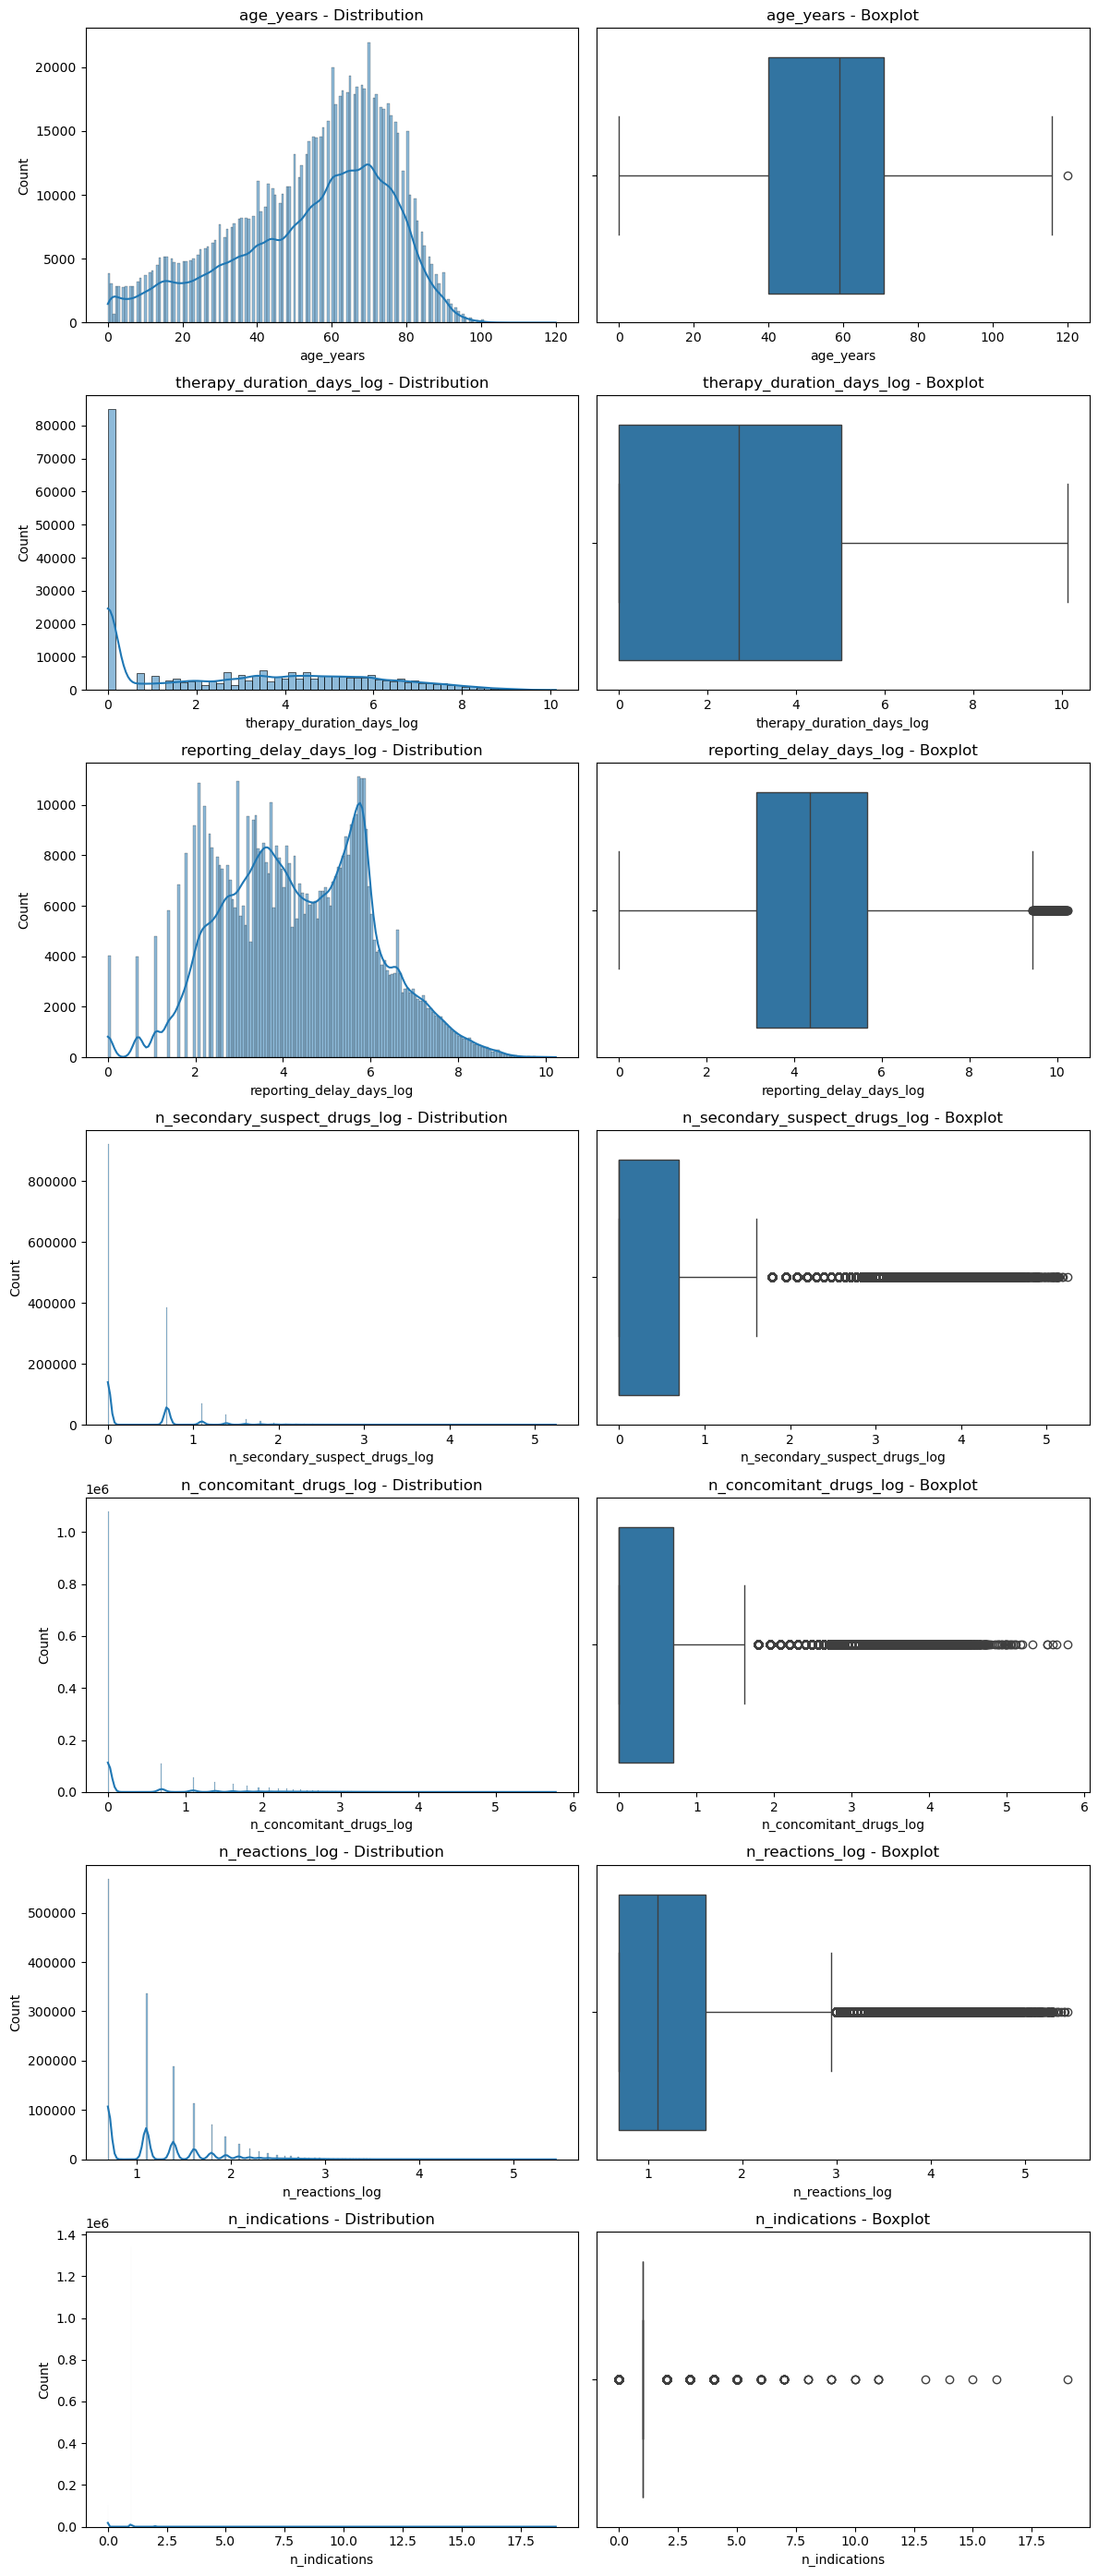

In [93]:
# STEP 9c: Visualize distributions (histogram + boxplot) for our key numeric features
# This helps us see the shape of the data and spot outliers visually

numeric_cols_to_plot = ['age_years', 'therapy_duration_days_log', 'reporting_delay_days_log', 
                          'n_secondary_suspect_drugs_log', 'n_concomitant_drugs_log', 
                          'n_reactions_log', 'n_indications']

fig, axes = plt.subplots(len(numeric_cols_to_plot), 2, figsize=(12, 4 * len(numeric_cols_to_plot)))

for i, col in enumerate(numeric_cols_to_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Distribution')
    
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

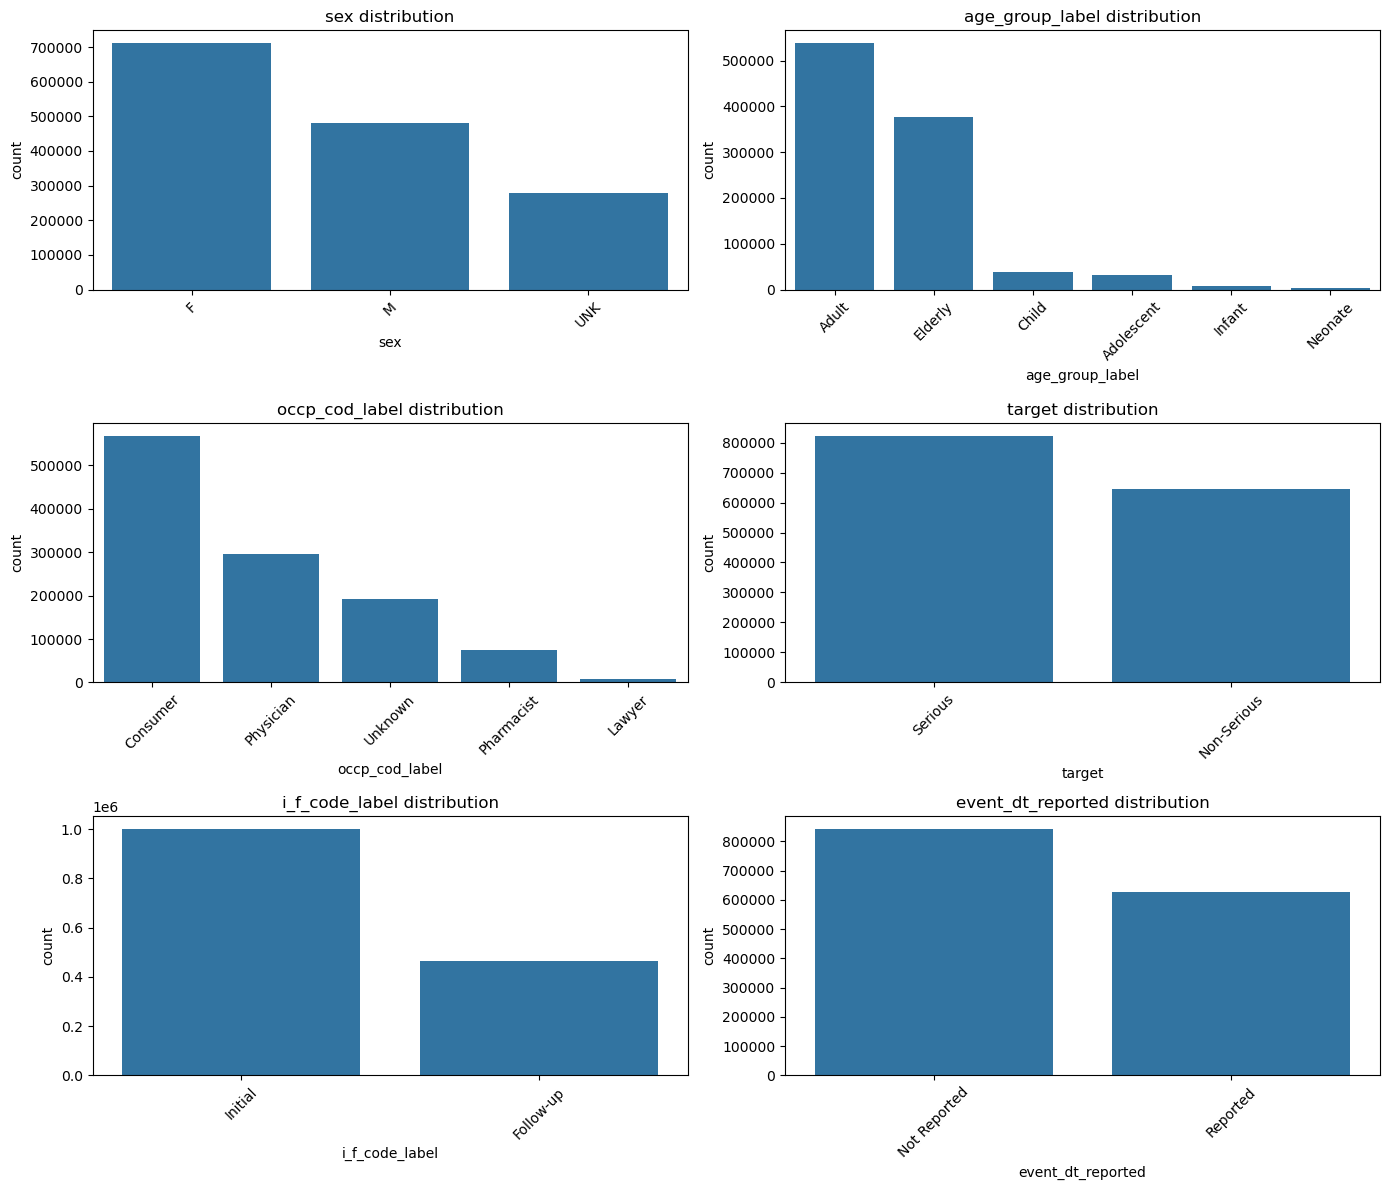

In [94]:
# STEP 9d: Visualize categorical variable distributions

age_group_labels = {
    'N': 'Neonate', 'I': 'Infant', 'C': 'Child',
    'T': 'Adolescent', 'A': 'Adult', 'E': 'Elderly'
}

occp_cod_labels = {
    'MD': 'Physician', 'PH': 'Pharmacist', 'OT': 'Other Health Professional',
    'LW': 'Lawyer', 'CN': 'Consumer', 'Unknown': 'Unknown'
}

i_f_code_labels = {
    'I': 'Initial', 'F': 'Follow-up'
}

# Create temporary display-friendly columns (we keep the original coded columns for modeling)
df['age_group_label'] = df['age_group'].map(age_group_labels)
df['occp_cod_label'] = df['occp_cod'].map(occp_cod_labels)
df['i_f_code_label'] = df['i_f_code'].map(i_f_code_labels)

categorical_cols_to_plot = ['sex', 'age_group_label', 'occp_cod_label', 'target', 'i_f_code_label', 'event_dt_reported']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'{col} distribution')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

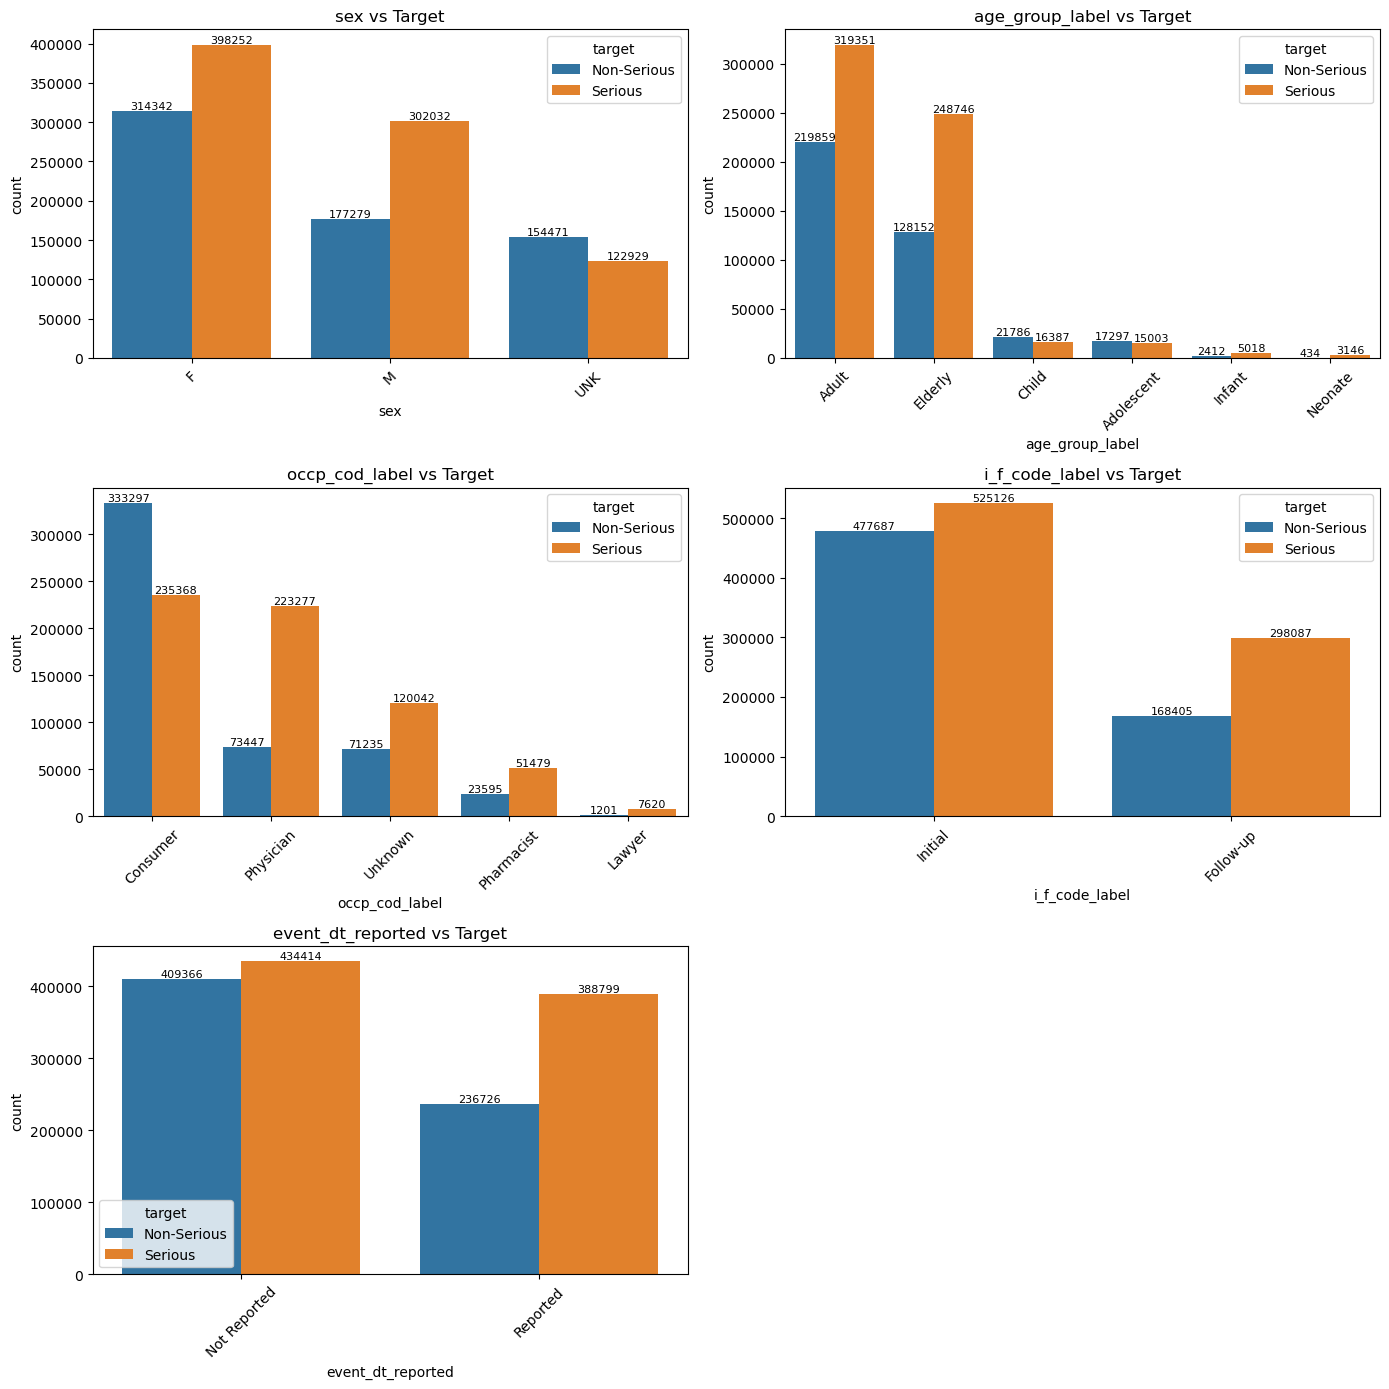

In [95]:
# STEP 9e: Visualize how key categorical variables relate to the target variable
# with count values labeled directly on top of each bar

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

cat_vs_target_cols = ['sex', 'age_group_label', 'occp_cod_label', 'i_f_code_label', 'event_dt_reported']

for i, col in enumerate(cat_vs_target_cols):
    ax = sns.countplot(data=df, x=col, hue='target', ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'{col} vs Target')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add count label on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
plt.show()

Numeric columns being plotted: ['age_years', 'therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'n_indications', 'event_year', 'event_month', 'therapy_duration_days_log', 'reporting_delay_days_log', 'n_secondary_suspect_drugs_log', 'n_concomitant_drugs_log', 'n_reactions_log']


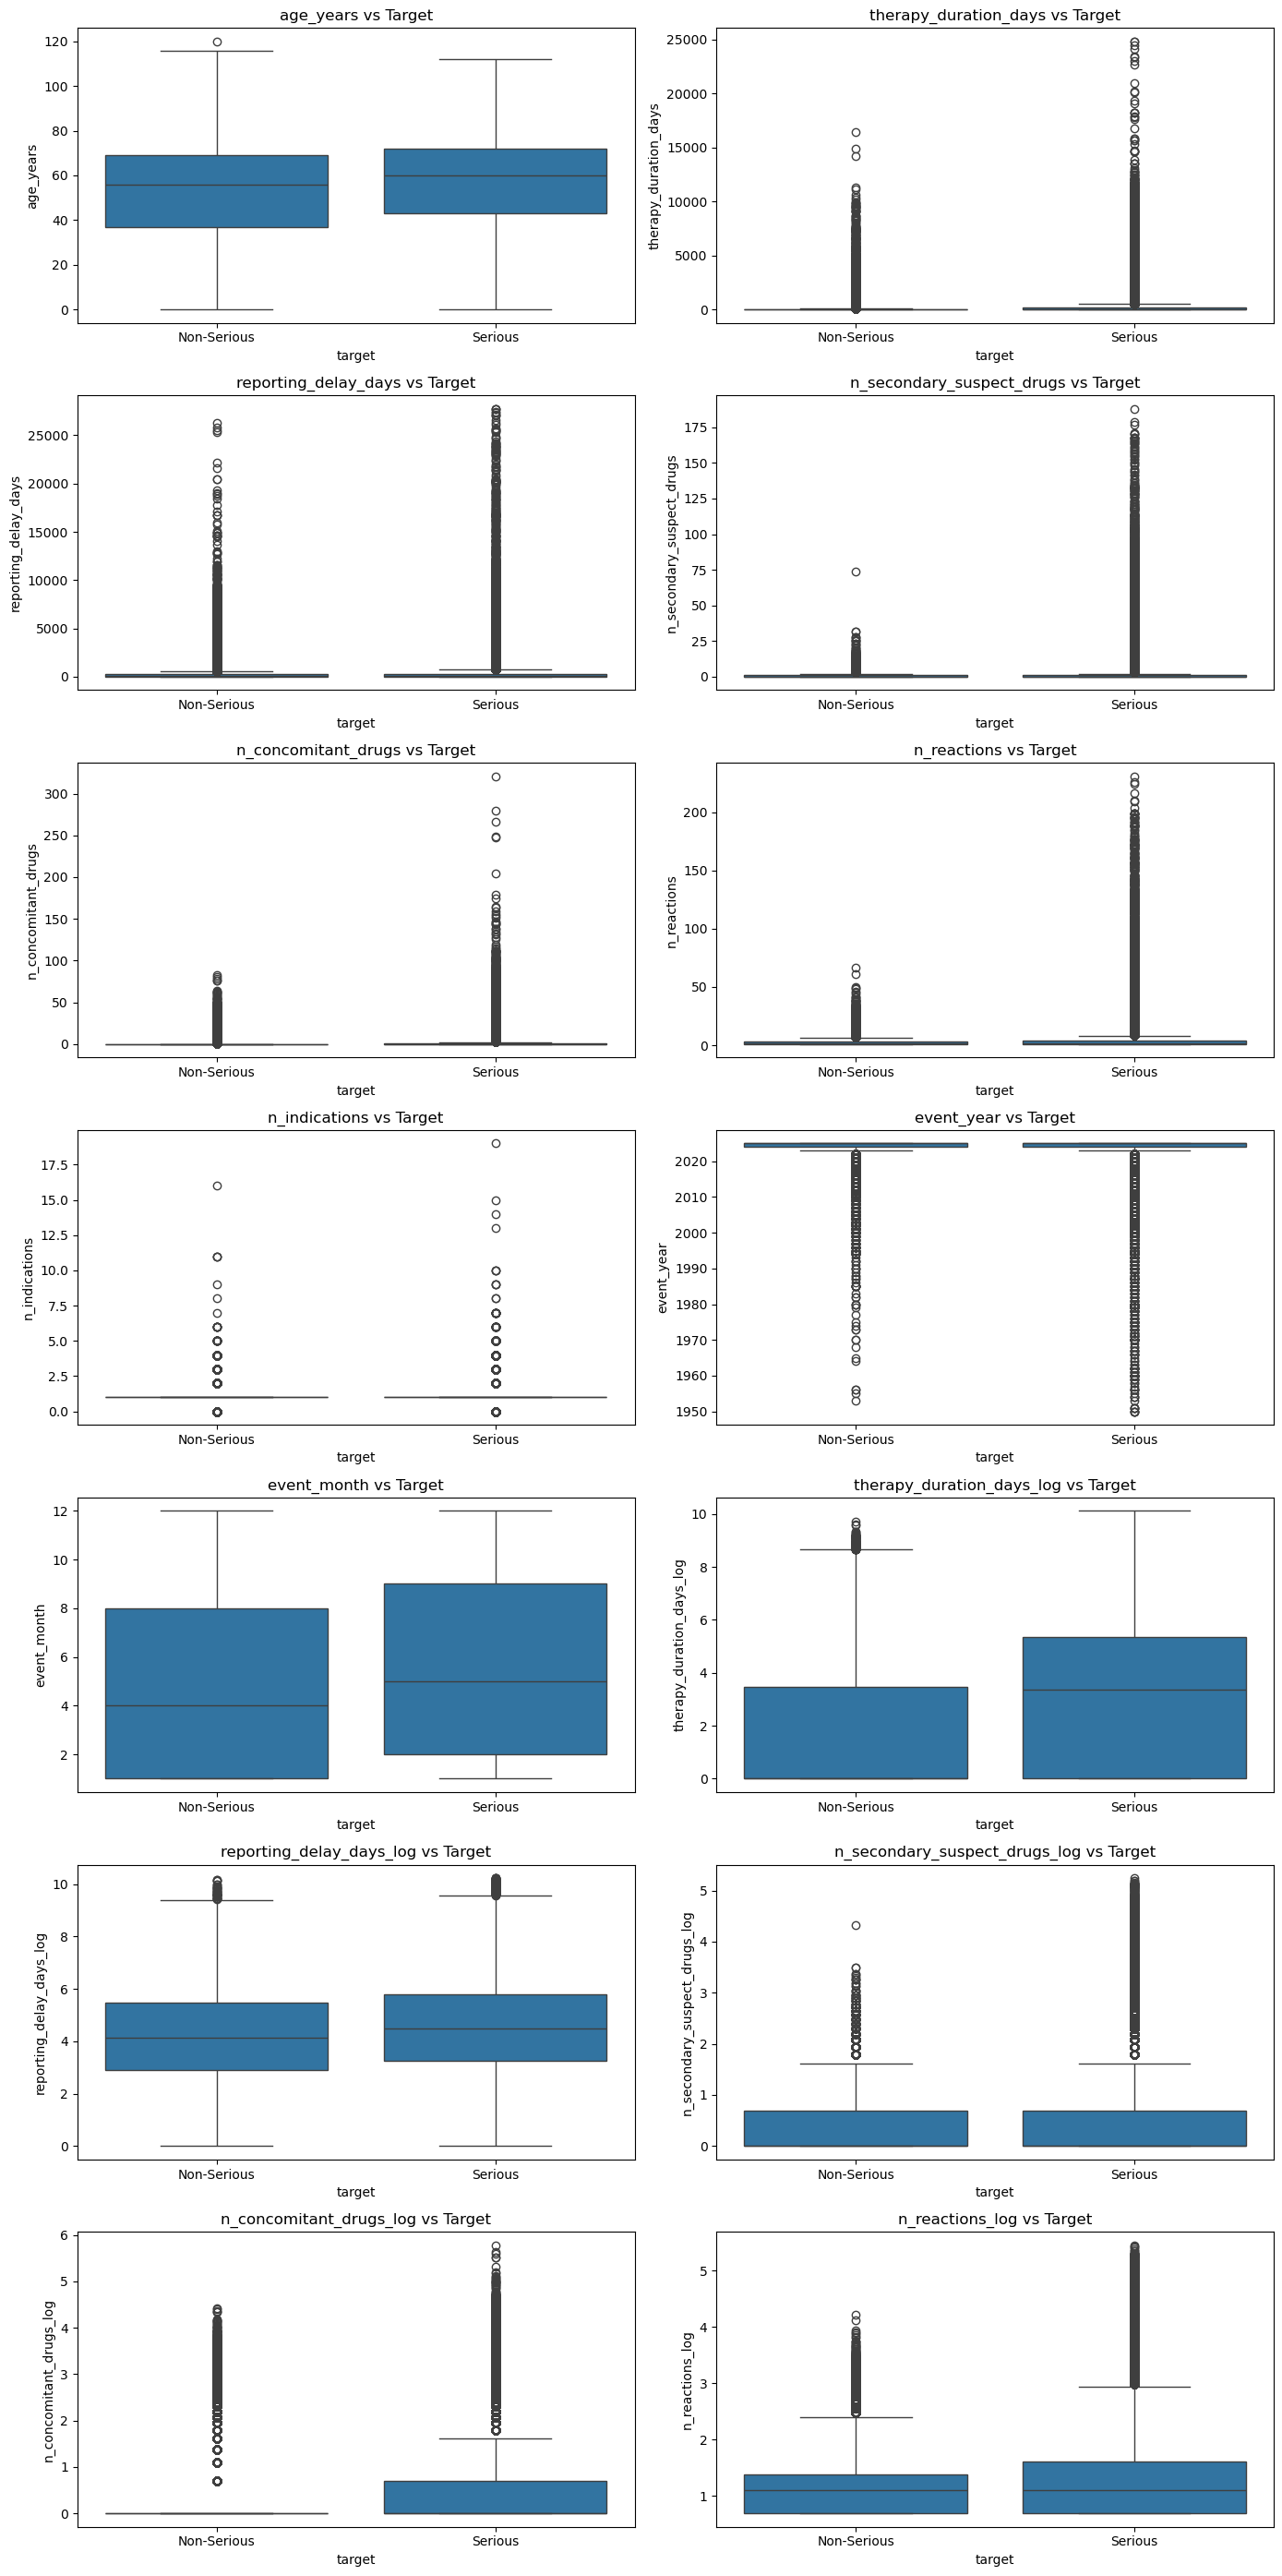

In [96]:
# STEP 9f: Visualize ALL numeric variables against the target variable

exclude_cols = ['primaryid', 'caseid', 'caseversion']
numeric_vs_target_cols = [col for col in df.select_dtypes(include=np.number).columns if col not in exclude_cols]

print("Numeric columns being plotted:", numeric_vs_target_cols)

n_cols = 2
n_rows = -(-len(numeric_vs_target_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_vs_target_cols):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Target')

for j in range(len(numeric_vs_target_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

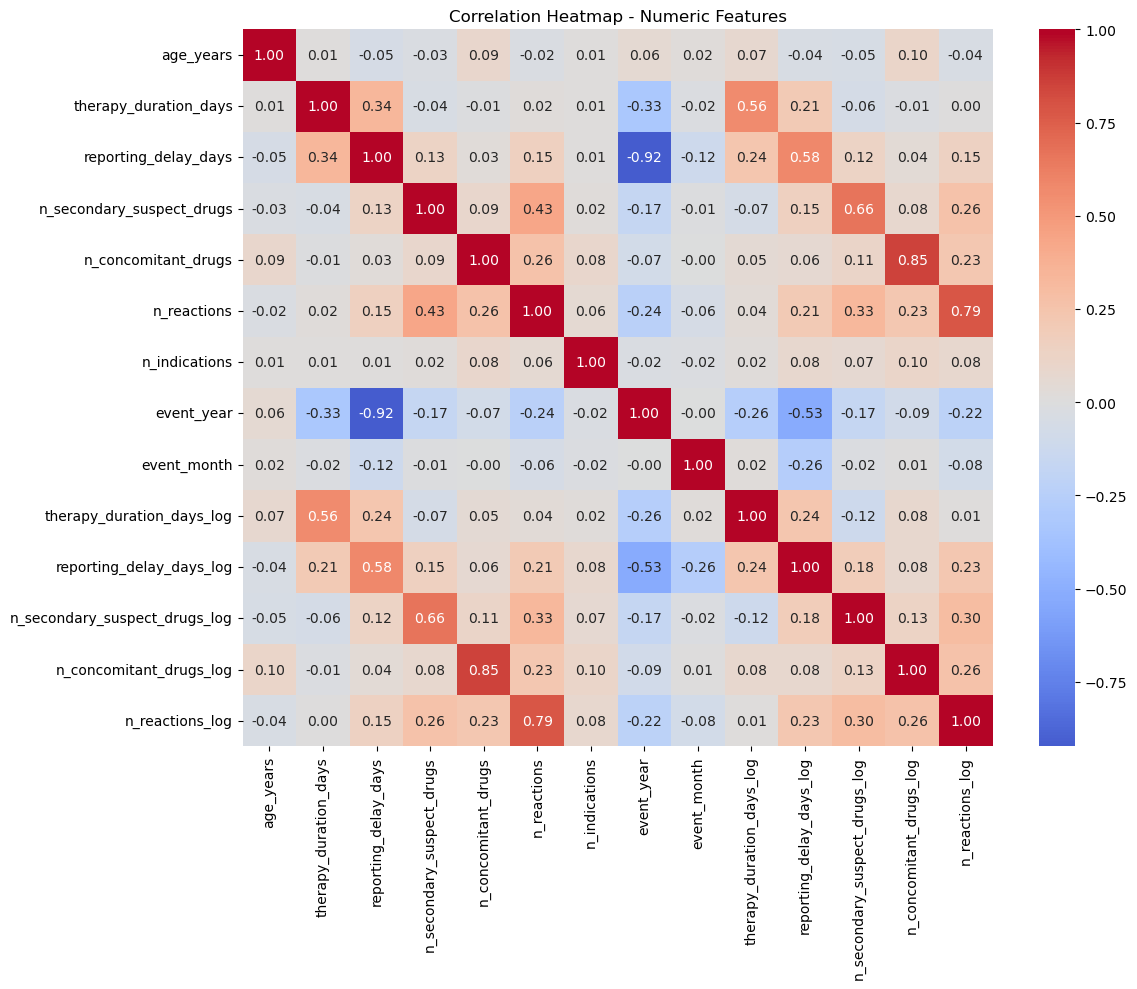

In [97]:
# STEP 9g: Correlation heatmap of numeric features (including a numeric version of target for reference)

df['target_numeric'] = df['target'].map({'Non-Serious': 0, 'Serious': 1})

numeric_for_corr = df.select_dtypes(include=np.number).drop(columns=['primaryid', 'caseid', 'caseversion'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

Target feature is mising in the heatmap.. investigationg that

In [98]:
print(df['target_numeric'].dtype)
print(df['target_numeric'].value_counts(dropna=False))

category
target_numeric
1    823213
0    646092
Name: count, dtype: int64


int64
Columns included in heatmap: ['age_years', 'therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'n_indications', 'event_year', 'event_month', 'therapy_duration_days_log', 'reporting_delay_days_log', 'n_secondary_suspect_drugs_log', 'n_concomitant_drugs_log', 'n_reactions_log', 'target_numeric']


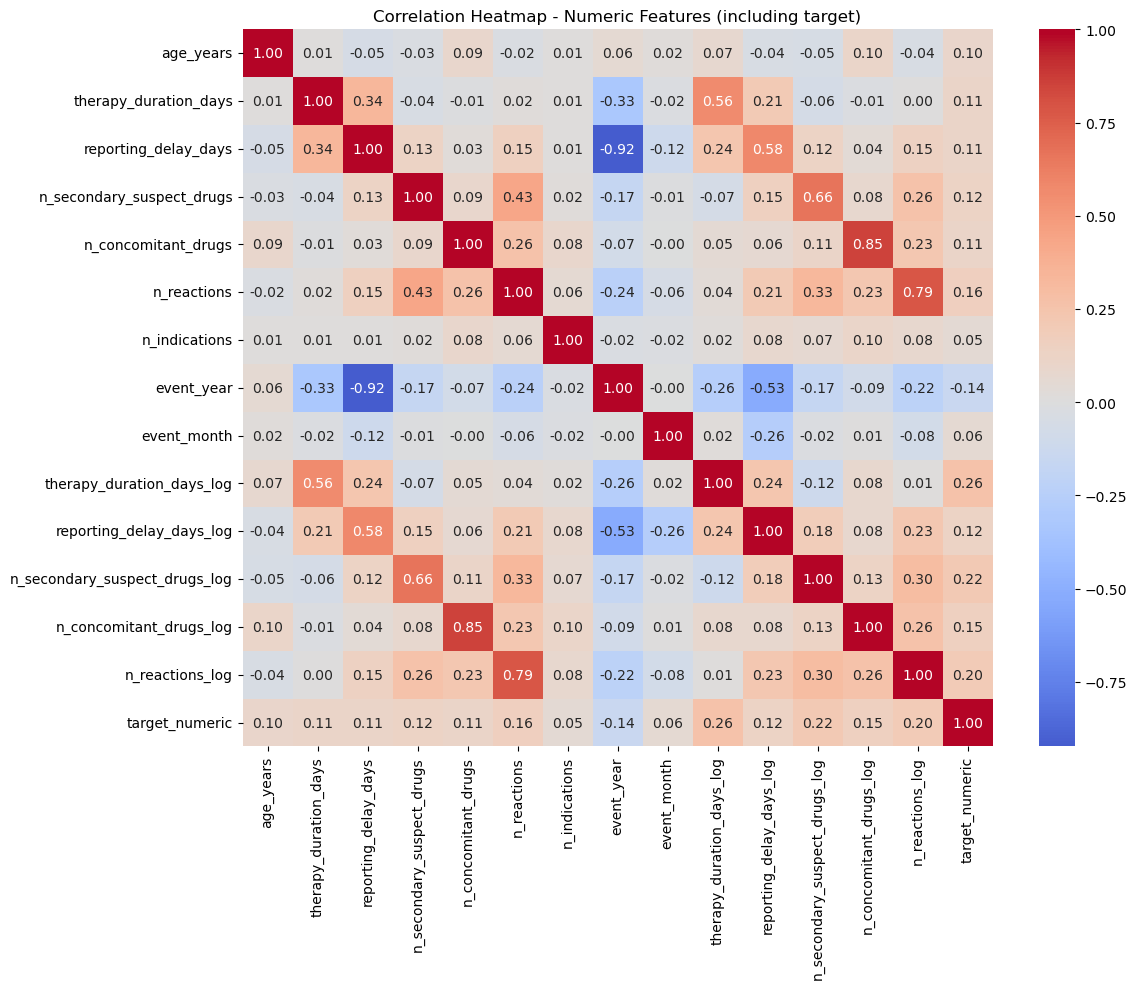

In [99]:
# FIX: Explicitly cast target_numeric to int, then redo the correlation heatmap

df['target_numeric'] = df['target_numeric'].astype(int)
print(df['target_numeric'].dtype)

numeric_for_corr = df.select_dtypes(include=np.number).drop(columns=['primaryid', 'caseid', 'caseversion'])
print("Columns included in heatmap:", numeric_for_corr.columns.tolist())

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features (including target)')
plt.tight_layout()
plt.show()

Step 10 — Feature Selection (Stage 1, before encoding)

In [100]:
# STEP 10a: Review all current columns before deciding what to drop

print(df.columns.tolist())
print("\nTotal columns:", df.shape[1])

['primaryid', 'caseid', 'caseversion', 'i_f_code', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'mfr_num', 'mfr_sndr', 'sex', 'e_sub', 'rept_dt', 'occp_cod', 'reporter_country', 'occr_country', 'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'outcomes', 'target', 'age_years', 'age_group', 'event_dt_reported', 'event_dt', 'therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'primary_suspect_drugs', 'secondary_suspect_drugs', 'concomitant_drugs', 'reactions', 'primary_suspect_indications', 'n_indications', 'event_year', 'event_month', 'therapy_duration_days_log', 'reporting_delay_days_log', 'n_secondary_suspect_drugs_log', 'n_concomitant_drugs_log', 'n_reactions_log', 'age_group_label', 'occp_cod_label', 'i_f_code_label', 'target_numeric']

Total columns: 46


In [101]:
# STEP 10b: Drop columns not needed for modeling (IDs, leakage, superseded raw dates/text, plot-only helpers, low-value admin fields)

columns_to_drop_stage1 = [
    # IDs
    'primaryid', 'caseid',
    # Leakage
    'outcomes',
    # Superseded raw dates (already extracted into engineered features)
    'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_dt', 'event_dt',
    'primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt',
    # Superseded raw text lists (already converted into counts)
    'secondary_suspect_drugs', 'concomitant_drugs', 'reactions', 'primary_suspect_indications',
    # Plot-only helper columns
    'age_group_label', 'occp_cod_label', 'i_f_code_label',
    # Administrative / low-value
    'mfr_sndr', 'caseversion'
]

df = df.drop(columns=columns_to_drop_stage1)

print("Shape after Stage 1 feature selection:", df.shape)
print(df.columns.tolist())

Shape after Stage 1 feature selection: (1469305, 27)
['i_f_code', 'rept_cod', 'mfr_num', 'sex', 'e_sub', 'occp_cod', 'reporter_country', 'occr_country', 'target', 'age_years', 'age_group', 'event_dt_reported', 'therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'primary_suspect_drugs', 'n_indications', 'event_year', 'event_month', 'therapy_duration_days_log', 'reporting_delay_days_log', 'n_secondary_suspect_drugs_log', 'n_concomitant_drugs_log', 'n_reactions_log', 'target_numeric']


Step 11 — Encoding

For the three high-cardinality columns (reporter_country, occr_country, primary_suspect_drugs), one-hot encoding all unique values would create thousands of different columns it will most likely to overfit. 
Hence we keep the top N most frequent categories (top 20) and bucket everything else into "Other" before one-hot encoding.

In [102]:
# STEP 11a: Check top value counts for high-cardinality columns before deciding on top-N cutoff

print("Top 20 reporter_country:\n", df['reporter_country'].value_counts().head(20))
print("\nTop 20 occr_country:\n", df['occr_country'].value_counts().head(20))
print("\nTop 20 primary_suspect_drugs:\n", df['primary_suspect_drugs'].value_counts().head(20))

Top 20 reporter_country:
 reporter_country
US    972239
EU     87852
CA     87205
GB     56947
JP     55074
CN     33964
FR     24739
AU     12675
DE     12550
BR     10197
IN      9390
IT      8735
ES      8279
CO      7619
KR      4869
TR      4216
ZA      3869
CH      3675
PL      3521
AR      3333
Name: count, dtype: int64

Top 20 occr_country:
 occr_country
US         899968
EU          86911
CA          85723
Unknown     78653
GB          56317
JP          55029
CN          34215
FR          24820
AU          12593
DE          12224
BR          10208
IN           9267
IT           8744
ES           8264
CO           7513
KR           4875
TR           4177
ZA           3856
CH           3672
PL           3507
Name: count, dtype: int64

Top 20 primary_suspect_drugs:
 primary_suspect_drugs
DUPIXENT         125676
ZEPBOUND          30097
MOUNJARO          27899
SKYRIZI           19952
VEDOLIZUMAB       15074
RINVOQ            15039
OZEMPIC           14766
REVLIMID          12334
ORG

In [103]:
# STEP 11a (continued): Check what % of data top-N categories cover, for each high-cardinality column

for col, n_options in [('reporter_country', [10, 20]), ('occr_country', [10, 20]), ('primary_suspect_drugs', [20, 50, 100])]:
    print(f"\n--- {col} ---")
    total = df[col].notna().sum()
    for n in n_options:
        top_n_count = df[col].value_counts().head(n).sum()
        print(f"Top {n} covers {top_n_count / total * 100:.1f}% of non-null values")


--- reporter_country ---
Top 10 covers 92.1% of non-null values
Top 20 covers 96.0% of non-null values

--- occr_country ---
Top 10 covers 91.6% of non-null values
Top 20 covers 96.0% of non-null values

--- primary_suspect_drugs ---
Top 20 covers 25.2% of non-null values
Top 50 covers 36.8% of non-null values
Top 100 covers 48.3% of non-null values


reporter_country and occr_country: Top 20 gives 96% coverage — a great cutoff, minimal information loss
primary_suspect_drugs: Even top 100 only covers 48.3% — the drug name distribution has a very long tail (6,721 unique drugs), so no small N will capture "most" of the data. This confirms primary_suspect_drugs is fundamentally different from the country columns.

Top 20-50 + "Other": captures only the most common drugs individually, but over half the data becomes a single generic "Other" bucket — loses a lot of specific drug signal
Top 100+: better coverage but still <50%, and now we're creating 100+ one-hot columns just for this one feature — heavy dimensionality for a "baseline" model

In [104]:
# STEP 11b: Bucket high-cardinality columns into top-N categories + "Other"

def bucket_top_n(series, n):
    top_categories = series.value_counts().head(n).index
    return series.apply(lambda x: x if x in top_categories else ('Other' if pd.notna(x) else x))

df['reporter_country_bucketed'] = bucket_top_n(df['reporter_country'], 20)
df['occr_country_bucketed'] = bucket_top_n(df['occr_country'], 20)
df['primary_suspect_drugs_bucketed'] = bucket_top_n(df['primary_suspect_drugs'], 50)

print("reporter_country_bucketed unique:", df['reporter_country_bucketed'].nunique())
print("occr_country_bucketed unique:", df['occr_country_bucketed'].nunique())
print("primary_suspect_drugs_bucketed unique:", df['primary_suspect_drugs_bucketed'].nunique())

reporter_country_bucketed unique: 21
occr_country_bucketed unique: 21
primary_suspect_drugs_bucketed unique: 51


In [105]:
# STEP 11c: Replace original high-cardinality columns with their bucketed versions

df = df.drop(columns=['reporter_country', 'occr_country', 'primary_suspect_drugs'])

print("Shape after replacing with bucketed columns:", df.shape)
print(df.columns.tolist())

Shape after replacing with bucketed columns: (1469305, 27)
['i_f_code', 'rept_cod', 'mfr_num', 'sex', 'e_sub', 'occp_cod', 'target', 'age_years', 'age_group', 'event_dt_reported', 'therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'n_indications', 'event_year', 'event_month', 'therapy_duration_days_log', 'reporting_delay_days_log', 'n_secondary_suspect_drugs_log', 'n_concomitant_drugs_log', 'n_reactions_log', 'target_numeric', 'reporter_country_bucketed', 'occr_country_bucketed', 'primary_suspect_drugs_bucketed']


In [106]:
# STEP 11d: Ordinal encode age_group since it has a natural order (Neonate < Infant < Child < Adolescent < Adult < Elderly)

age_order = ['N', 'I', 'C', 'T', 'A', 'E']
age_order_map = {cat: i for i, cat in enumerate(age_order)}

df['age_group_encoded'] = df['age_group'].map(age_order_map)

print(df[['age_group', 'age_group_encoded']].drop_duplicates().sort_values('age_group_encoded'))
print("\nMissing age_group_encoded:", df['age_group_encoded'].isna().sum())

    age_group age_group_encoded
5           A                 4
2           C                 2
1           E                 5
148         I                 1
977         N                 0
10          T                 3
0         NaN               NaN

Missing age_group_encoded: 471714


In [107]:
# STEP 11e: One-hot encode nominal (unordered) categorical columns

nominal_cols = ['i_f_code', 'rept_cod', 'sex', 'e_sub', 'occp_cod', 'event_dt_reported',
                'reporter_country_bucketed', 'occr_country_bucketed', 'primary_suspect_drugs_bucketed']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

print("Shape after one-hot encoding:", df_encoded.shape)
print(df_encoded.columns.tolist()[:30])  # show first 30 column names as a sanity check

Shape after one-hot encoding: (1469305, 132)
['mfr_num', 'target', 'age_years', 'age_group', 'therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions', 'n_indications', 'event_year', 'event_month', 'therapy_duration_days_log', 'reporting_delay_days_log', 'n_secondary_suspect_drugs_log', 'n_concomitant_drugs_log', 'n_reactions_log', 'target_numeric', 'age_group_encoded', 'i_f_code_F', 'i_f_code_I', 'rept_cod_30DAY', 'rept_cod_5DAY', 'rept_cod_DIR', 'rept_cod_EXP', 'rept_cod_PER', 'sex_F', 'sex_M', 'sex_UNK', 'e_sub_N']


In [108]:
# STEP 11f: Drop the now-redundant original categorical columns (age_group - replaced by age_group_encoded)
# Keep target and target_numeric for now, decide which to use at train-test-split time

df_encoded = df_encoded.drop(columns=['age_group'])

print("Final encoded shape:", df_encoded.shape)
print("\nMissing values check:\n", df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])

Final encoded shape: (1469305, 131)

Missing values check:
 mfr_num                        54368
age_years                     583663
therapy_duration_days        1237425
reporting_delay_days          843781
event_year                    843781
event_month                   843781
therapy_duration_days_log    1237425
reporting_delay_days_log      843781
age_group_encoded             471714
dtype: int64


This confirms our remaining missing values, all traceable to expected causes:
age_years / age_group_encoded: genuine missing age data
therapy_duration_days(_log): only cases with both PS therapy start & end dates recorded
reporting_delay_days(_log), event_year, event_month: only cases where event_dt was valid/recorded

Options for these missing numeric values:

Median imputation — simple, robust to outliers (given our skewed distributions)
Impute + add a "was_missing" flag column — preserves the missingness signal (e.g., "no age reported" might itself be informative) while still giving the model a usable number.

Given we've seen throughout this project that "missingness" itself often carries signal (e.g., event_dt_reported was itself useful) selecting option 2

In [109]:
df_encoded['age_group_encoded'] = df_encoded['age_group_encoded'].astype('float64')

In [110]:
# STEP 11g: For each remaining numeric column with missing values,
# create a flag column (1 = was missing, 0 = originally present) BEFORE imputing,
# then impute missing values with the median

cols_with_missing = ['age_years', 'age_group_encoded', 
                      'therapy_duration_days', 'therapy_duration_days_log',
                      'reporting_delay_days', 'reporting_delay_days_log',
                      'event_year', 'event_month']

for col in cols_with_missing:
    flag_col = col + '_was_missing'
    df_encoded[flag_col] = df_encoded[col].isna().astype(int)
    median_val = df_encoded[col].median()
    df_encoded[col] = df_encoded[col].fillna(median_val)

print("Missing values remaining:\n", df_encoded[cols_with_missing].isnull().sum())
print("\nSample of flag columns:\n", df_encoded[[c + '_was_missing' for c in cols_with_missing]].sum())

Missing values remaining:
 age_years                    0
age_group_encoded            0
therapy_duration_days        0
therapy_duration_days_log    0
reporting_delay_days         0
reporting_delay_days_log     0
event_year                   0
event_month                  0
dtype: int64

Sample of flag columns:
 age_years_was_missing                     583663
age_group_encoded_was_missing             471714
therapy_duration_days_was_missing        1237425
therapy_duration_days_log_was_missing    1237425
reporting_delay_days_was_missing          843781
reporting_delay_days_log_was_missing      843781
event_year_was_missing                    843781
event_month_was_missing                   843781
dtype: int64


In [111]:
# FIX: age_group_encoded inherited 'category' dtype from age_group via .map() - cast to float first

df_encoded['age_group_encoded'] = df_encoded['age_group_encoded'].astype(float)
print(df_encoded['age_group_encoded'].dtype)

# Now retry the imputation with flags
cols_with_missing = ['age_years', 'age_group_encoded', 
                      'therapy_duration_days', 'therapy_duration_days_log',
                      'reporting_delay_days', 'reporting_delay_days_log',
                      'event_year', 'event_month']

for col in cols_with_missing:
    flag_col = col + '_was_missing'
    df_encoded[flag_col] = df_encoded[col].isna().astype(int)
    median_val = df_encoded[col].median()
    df_encoded[col] = df_encoded[col].fillna(median_val)

print("\nMissing values remaining:\n", df_encoded[cols_with_missing].isnull().sum())
print("\nSample of flag columns:\n", df_encoded[[c + '_was_missing' for c in cols_with_missing]].sum())

float64

Missing values remaining:
 age_years                    0
age_group_encoded            0
therapy_duration_days        0
therapy_duration_days_log    0
reporting_delay_days         0
reporting_delay_days_log     0
event_year                   0
event_month                  0
dtype: int64

Sample of flag columns:
 age_years_was_missing                    0
age_group_encoded_was_missing            0
therapy_duration_days_was_missing        0
therapy_duration_days_log_was_missing    0
reporting_delay_days_was_missing         0
reporting_delay_days_log_was_missing     0
event_year_was_missing                   0
event_month_was_missing                  0
dtype: int64


In [112]:
# Investigate: age_years should have had ~583,653 missing values, but flag shows 0

print("Current age_years missing count:", df_encoded['age_years'].isna().sum())
print("age_years dtype:", df_encoded['age_years'].dtype)

# Check if age_years was already imputed/modified somewhere earlier in the notebook, before this cell ran
print("\nUnique value count in age_years:", df_encoded['age_years'].nunique())
print(df_encoded['age_years'].describe())

Current age_years missing count: 0
age_years dtype: float64

Unique value count in age_years: 499
count    1.469305e+06
mean     5.633467e+01
std      1.679658e+01
min      0.000000e+00
25%      5.400000e+01
50%      5.900000e+01
75%      6.300000e+01
max      1.200000e+02
Name: age_years, dtype: float64


In [113]:
# FIX: Rebuild age_years_was_missing correctly, using the original (still-intact) df, not the already-imputed df_encoded

df_encoded['age_years_was_missing'] = df['age_years'].isna().astype(int)

print("Corrected age_years_was_missing count:", df_encoded['age_years_was_missing'].sum())

Corrected age_years_was_missing count: 583663


In [114]:
# STEP 11h: Confirm no missing values remain anywhere in df_encoded

print("Total missing values remaining:", df_encoded.isnull().sum().sum())
print("\nShape:", df_encoded.shape)

Total missing values remaining: 54368

Shape: (1469305, 139)


In [115]:
print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])

mfr_num    54368
dtype: int64


In [116]:
df_encoded = df_encoded.drop(columns=['mfr_num'])
print("Missing values remaining:", df_encoded.isnull().sum().sum())
print("Shape:", df_encoded.shape)

Missing values remaining: 0
Shape: (1469305, 138)


Step 13 — Train-Test Split

In [117]:
# STEP 13a: Split into train/test sets (80/20, standard for our dataset size)
# We use target_numeric (0/1) since sklearn models expect numeric targets
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['target', 'target_numeric'])
y = df_encoded['target_numeric']

# ↓↓↓ INSERT HERE — after X is created, before train_test_split ↓↓↓
cols_to_drop = [
    'n_secondary_suspect_drugs',
    'n_reactions',
    'n_concomitant_drugs',
    'therapy_duration_days',
    'reporting_delay_days'
]
missing = [c for c in cols_to_drop if c not in X.columns]
if missing:
    print("Warning — these columns were not found and will be skipped:", missing)
cols_to_drop = [c for c in cols_to_drop if c in X.columns]
X = X.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
# ↑↑↑ END INSERT ↑↑↑

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

Dropped columns: ['n_secondary_suspect_drugs', 'n_reactions', 'n_concomitant_drugs', 'therapy_duration_days', 'reporting_delay_days']
X_train shape: (1175444, 131)
X_test shape: (293861, 131)
y_train distribution:
 target_numeric
1    0.560273
0    0.439727
Name: proportion, dtype: float64
y_test distribution:
 target_numeric
1    0.560275
0    0.439725
Name: proportion, dtype: float64


In [118]:
# Free up memory by deleting large intermediate dataframes we no longer need
# (everything has already been merged into df / df_encoded)

import gc

vars_to_delete = ['demo', 'drug', 'reac', 'outc', 'ther', 'indi', 'rpsr',
                   'ps_therapy', 'ps_therapy_agg', 'ps_indication', 'ps_indication_agg', 
                   'ps_indication_agg_fixed', 'ps_drug_seq', 'reac_agg', 'reac_agg_fixed',
                   'reac_dedup', 'outc_agg', 'rpsr_agg', 'drug_summary',
                   'primary_suspect', 'secondary_suspect', 'concomitant', 'interacting',
                   'primary_suspect_fixed', 'secondary_suspect_fixed', 'concomitant_fixed']

for var in vars_to_delete:
    if var in globals():
        del globals()[var]

gc.collect()

print("Cleanup done.")

Cleanup done.


In [119]:
# STEP 12a: Fit a baseline Random Forest on training data only, to assess feature importance
# This is NOT our final model - just a tool to guide feature selection

from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 20 most important features:")
print(importances.head(20))

Top 20 most important features:
rept_cod_PER                               0.314210
rept_cod_EXP                               0.306833
reporter_country_bucketed_US               0.094324
occr_country_bucketed_US                   0.059839
occp_cod_CN                                0.020020
primary_suspect_drugs_bucketed_DUPIXENT    0.019811
rept_cod_30DAY                             0.015145
n_secondary_suspect_drugs_log              0.012352
primary_suspect_drugs_bucketed_Other       0.010917
occr_country_bucketed_EU                   0.010328
reporter_country_bucketed_CA               0.009881
occr_country_bucketed_CA                   0.007999
n_reactions_log                            0.006911
sex_UNK                                    0.005557
reporter_country_bucketed_GB               0.005485
n_concomitant_drugs_log                    0.005383
reporter_country_bucketed_EU               0.005071
occr_country_bucketed_Unknown              0.005054
e_sub_Y                         

Summary of finding: rept_cod_EXP + rept_cod_PER together account for ~60% of the model's total decision power. 

As per the FDA data dictionary we saved earlier, rept_cod values mean: EXP = Expedited (15-Day) report PER = Periodic (Non-Expedited) report. Under FDA regulations, manufacturers are required to submit Expedited (15-day) reports specifically for serious, unexpected adverse events and Periodic reports are used for routine/non-serious submissions. This means rept_cod isn't really an independent predictive feature — it's essentially a regulatory classification that already encodes seriousness by definition, decided by humans/systems after they already determined the event was serious. Hence it was decided to drop the column.


In [120]:
# STEP 12b: Drop all rept_cod one-hot columns - this field is a regulatory classification
# that already encodes seriousness by definition (EXP = expedited/serious, PER = periodic/routine),
# so keeping it would let the model just learn an existing business rule instead of real patterns

rept_cod_cols = [col for col in df_encoded.columns if col.startswith('rept_cod_')]
print("Dropping columns:", rept_cod_cols)

df_encoded = df_encoded.drop(columns=rept_cod_cols)
X_train = X_train.drop(columns=rept_cod_cols)
X_test = X_test.drop(columns=rept_cod_cols)

print("\nNew df_encoded shape:", df_encoded.shape)
print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)

Dropping columns: ['rept_cod_30DAY', 'rept_cod_5DAY', 'rept_cod_DIR', 'rept_cod_EXP', 'rept_cod_PER']

New df_encoded shape: (1469305, 133)
New X_train shape: (1175444, 126)
New X_test shape: (293861, 126)


In [121]:
# STEP 12c: Re-check feature importance after removing rept_cod

X_train_sample = X_train.sample(n=200000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

rf_selector = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=1)
rf_selector.fit(X_train_sample, y_train_sample)

importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 20 most important features (without rept_cod):")
print(importances.head(20))

Top 20 most important features (without rept_cod):
reporter_country_bucketed_US               0.267606
occr_country_bucketed_US                   0.188091
primary_suspect_drugs_bucketed_DUPIXENT    0.061754
n_secondary_suspect_drugs_log              0.059205
primary_suspect_drugs_bucketed_Other       0.042544
reporter_country_bucketed_EU               0.028669
occp_cod_CN                                0.028610
reporter_country_bucketed_CA               0.025984
n_reactions_log                            0.024951
occp_cod_MD                                0.020275
occr_country_bucketed_EU                   0.018217
occr_country_bucketed_GB                   0.015406
occr_country_bucketed_CA                   0.013644
reporter_country_bucketed_JP               0.012262
n_concomitant_drugs_log                    0.012186
age_years                                  0.010728
age_years_was_missing                      0.010015
occr_country_bucketed_Other                0.009984
sex_UNK      

This is the same country-dominance pattern we found last time, now reappearing at the top once rept_cod was removed. reporter_country_bucketed_US (25.4%) + occr_country_bucketed_US (19.3%) together account for ~45% of the model's importance — very similar to what we saw before (52% for reporter_country_us alone last time).

This matches our earlier documented finding: this is a real, explainable "selection bias" in how cases enter the FAERS database, not a clinical signal — the US reports at a different rate/severity threshold than other countries, so "is this a US report" tells the model much more about reporting patterns than about the actual drug/patient risk.

Hence dropping reporter_country/occr_country entirely

In [122]:
# STEP 12d: Drop all reporter_country and occr_country one-hot columns
# These reflect reporting-pathway/selection bias (e.g., US reporting patterns), not genuine clinical risk signal

country_cols = [col for col in df_encoded.columns if col.startswith('reporter_country_bucketed_') or col.startswith('occr_country_bucketed_')]
print("Dropping columns:", country_cols)

df_encoded = df_encoded.drop(columns=country_cols)
X_train = X_train.drop(columns=country_cols)
X_test = X_test.drop(columns=country_cols)

print("\nNew df_encoded shape:", df_encoded.shape)
print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)

Dropping columns: ['reporter_country_bucketed_AR', 'reporter_country_bucketed_AU', 'reporter_country_bucketed_BR', 'reporter_country_bucketed_CA', 'reporter_country_bucketed_CH', 'reporter_country_bucketed_CN', 'reporter_country_bucketed_CO', 'reporter_country_bucketed_DE', 'reporter_country_bucketed_ES', 'reporter_country_bucketed_EU', 'reporter_country_bucketed_FR', 'reporter_country_bucketed_GB', 'reporter_country_bucketed_IN', 'reporter_country_bucketed_IT', 'reporter_country_bucketed_JP', 'reporter_country_bucketed_KR', 'reporter_country_bucketed_Other', 'reporter_country_bucketed_PL', 'reporter_country_bucketed_TR', 'reporter_country_bucketed_US', 'reporter_country_bucketed_ZA', 'occr_country_bucketed_AU', 'occr_country_bucketed_BR', 'occr_country_bucketed_CA', 'occr_country_bucketed_CH', 'occr_country_bucketed_CN', 'occr_country_bucketed_CO', 'occr_country_bucketed_DE', 'occr_country_bucketed_ES', 'occr_country_bucketed_EU', 'occr_country_bucketed_FR', 'occr_country_bucketed_GB'

In [123]:
# STEP 12e: Re-check feature importance now that reporting-pathway artifacts (rept_cod, countries) are removed

X_train_sample = X_train.sample(n=200000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

rf_selector = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=1)
rf_selector.fit(X_train_sample, y_train_sample)

importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 20 most important features (clinical/case features only):")
print(importances.head(20))

Top 20 most important features (clinical/case features only):
primary_suspect_drugs_bucketed_DUPIXENT         0.183392
n_secondary_suspect_drugs_log                   0.143464
occp_cod_CN                                     0.111553
primary_suspect_drugs_bucketed_Other            0.086712
n_reactions_log                                 0.060152
occp_cod_MD                                     0.057597
age_years_was_missing                           0.039272
n_concomitant_drugs_log                         0.036618
primary_suspect_drugs_bucketed_ZEPBOUND         0.032086
sex_UNK                                         0.023850
reporting_delay_days_log                        0.019649
event_year                                      0.018352
age_years                                       0.016170
age_group_encoded                               0.013976
event_dt_reported_Reported                      0.013936
occp_cod_HP                                     0.012698
primary_suspect_drugs_buck

primary_suspect_drugs_bucketed_DUPIXENT (15.5%) — dominant, but this makes sense: Dupixent is by far the single most common PS drug in our data (125,676 cases, ~8.5% of all cases) and is used for specific chronic conditions (asthma, eczema, etc.) that may have a distinct Serious/Non-Serious reporting pattern. Not an artifact — a genuine drug-specific signal, worth keeping. 
occp_cod_CN (Consumer, 12.9%) —from our EDA Consumer-reported cases skew heavily non-Serious (41% Serious) vs Physician-reported (75% Serious). This is a real, explainable pattern (who reports, and how). 
(n_secondary_suspect_drugs, n_reactions, n_concomitant_drugs) — genuinely clinical signals, exactly what we'd hope to see driving predictions Therapy duration, reporting delay, age-related features — all appear with reasonable, non-dominant weights


Step 14 — Train Baseline Model

In [124]:
# STEP 14a: Train a baseline Random Forest model on the full training set (final feature set, artifacts removed)

from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=1)
rf_baseline.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


In [125]:
# STEP 15: Evaluate baseline model performance on the held-out test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_pred = rf_baseline.predict(X_test)
y_proba = rf_baseline.predict_proba(X_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:  0.7826795661894569
Precision: 0.7898621169676087
Recall:    0.8339984086781703
F1 Score:  0.8113304538444721
ROC-AUC:   0.8638171807173634

Confusion Matrix:
[[ 92687  36531]
 [ 27331 137312]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74    129218
           1       0.79      0.83      0.81    164643

    accuracy                           0.78    293861
   macro avg       0.78      0.78      0.78    293861
weighted avg       0.78      0.78      0.78    293861



Having removed both artifacts (rept_cod AND countries) from the start, we're getting 78.5% accuracy and 0.867 ROC-AUC — actually better than last time's "artifact-removed" comparison (72.5%/0.81), on genuinely clinical/case features (drug identity, drug/reaction counts, therapy duration, reporting delay, demographics).
The confusion matrix also looks reasonably balanced (no extreme bias toward one class):


Step 16 — Cross-Validation

In [126]:
# STEP 16: Cross-validate to confirm our test performance is stable, not a lucky split
# Using fewer estimators and 3 folds (instead of 5) to keep runtime manageable given dataset size

from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=1)

cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=3, scoring='accuracy')

print("CV Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

CV Accuracy scores: [0.78245345 0.78182816 0.78037793]
Mean CV Accuracy: 0.7815531823079213
Std CV Accuracy: 0.0008693500158759471


We're using Random Forest, which builds decision trees based on splitting thresholds (e.g., "is age > 45?") — it doesn't care about the magnitude of values, only their relative order. So scaling age_years (0-120) alongside n_reactions (1-231) wouldn't change how the model splits at all. No action needed — but worth noting in your report: if we later try Logistic Regression, KNN, or SVM as a comparison model, we'd need to add a StandardScaler step at that point.

Handling Imbalanced Data (Step 13 in our workflow doc)
Per our own checklist: SMOTE/class-weighting is recommended when the split is severe — e.g., 95:5 or 98:2. Our target split is 56% Serious / 44% Non-Serious — this is a mild, close-to-balanced split, not the kind of severe imbalance that technique is meant to fix. Applying SMOTE here would be unnecessary (and could even introduce synthetic-data artifacts for no real benefit). No action needed.

Step 17 — Hyperparameter Tuning

In [127]:
# STEP 17: Hyperparameter tuning using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomForestClassifier(random_state=42, n_jobs=1)

random_search = RandomizedSearchCV(
    rf_search, param_distributions=param_dist,
    n_iter=8, cv=3, scoring='roc_auc', random_state=42, verbose=2
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

best_rf = random_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.6min
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.5min
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.8min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.9min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.8min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.8min
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=150; total time= 2.7min
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=150; total time= 2.8min
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=150; total time= 2.7min
[CV] END max_depth=15, min_samp

Step 18 — Train Best Model

In [128]:
# STEP 18: Train the final model using the best hyperparameters found

best_rf = random_search.best_estimator_

# Evaluate on test set
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print("=== Tuned Model Performance (Test Set) ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:   ", recall_score(y_test, y_pred_best))
print("F1 Score: ", f1_score(y_test, y_pred_best))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

=== Tuned Model Performance (Test Set) ===
Accuracy:  0.7924801181510986
Precision: 0.8093120960570995
Recall:    0.8236851855226156
F1 Score:  0.8164353872550495
ROC-AUC:   0.8745469477972939

Confusion Matrix:
[[ 97265  31953]
 [ 29029 135614]]


In [129]:
# STEP 19: Full classification report for the tuned model

print("=== Final Classification Report (Tuned Random Forest) ===")
print(classification_report(y_test, y_pred_best))

=== Final Classification Report (Tuned Random Forest) ===
              precision    recall  f1-score   support

           0       0.77      0.75      0.76    129218
           1       0.81      0.82      0.82    164643

    accuracy                           0.79    293861
   macro avg       0.79      0.79      0.79    293861
weighted avg       0.79      0.79      0.79    293861



In [130]:
# STEP 21: Feature importance from the final tuned Random Forest

tuned_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 20 most important features (tuned model):")
print(tuned_importances.head(20))

Top 20 most important features (tuned model):
primary_suspect_drugs_bucketed_DUPIXENT       0.149661
occp_cod_CN                                   0.093566
n_secondary_suspect_drugs_log                 0.093560
n_reactions_log                               0.067537
primary_suspect_drugs_bucketed_Other          0.064180
occp_cod_MD                                   0.047366
n_concomitant_drugs_log                       0.039641
reporting_delay_days_log                      0.034163
age_years                                     0.033974
age_years_was_missing                         0.032768
primary_suspect_drugs_bucketed_ZEPBOUND       0.024342
sex_UNK                                       0.020772
age_group_encoded                             0.019467
event_year                                    0.016002
occp_cod_HP                                   0.015787
primary_suspect_drugs_bucketed_SKYRIZI        0.014734
event_month                                   0.012640
primary_suspect_dru

In [131]:
# Prepare scaled data for Logistic Regression (drop event_year due to near-perfect correlation with reporting_delay_days)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train_lr = X_train.drop(columns=['event_year'])
X_test_lr = X_test.drop(columns=['event_year'])

scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_lr_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_lr_scaled)
y_proba_lr = log_reg.predict_proba(X_test_lr_scaled)[:, 1]

print("=== Logistic Regression Performance (Test Set) ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:   ", recall_score(y_test, y_pred_lr))
print("F1 Score: ", f1_score(y_test, y_pred_lr))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression Performance (Test Set) ===
Accuracy:  0.7582326337962506
Precision: 0.7678224989555732
Recall:    0.8148964729748608
F1 Score:  0.7906594377983381
ROC-AUC:   0.8397206607950644


Random Forest (tuned) is our final model — better performance, and per our earlier feature_importances_ analysis, still reasonably interpretable (even if not as directly as logistic regression's coefficients).

That said, Logistic Regression's coefficients could still be useful as a supplementary interpretability check — let's peek at its coef_ briefly for anyone reading the report who wants a simple "direction of effect" view, then move to saving the model.

after later comparing against XGBoost and LightGBM (see below) and validating on genuinely out-of-time 2026 data, XGBoost — further refined in the final section below by removing reporting_delay_days_log — became the true final, deployed model. This Random Forest section is kept as the first modeling pass, not the final answer.

In [132]:
# Quick look at Logistic Regression coefficients for interpretability context (which direction each feature pushes toward Serious)

lr_coefs = pd.Series(log_reg.coef_[0], index=X_train_lr.columns).sort_values(ascending=False)

print("Top 10 features pushing toward SERIOUS:")
print(lr_coefs.head(10))

print("\nTop 10 features pushing toward NON-SERIOUS:")
print(lr_coefs.tail(10))

Top 10 features pushing toward SERIOUS:
primary_suspect_drugs_bucketed_VEDOLIZUMAB      0.376878
primary_suspect_drugs_bucketed_DAPAGLIFLOZIN    0.373207
occp_cod_MD                                     0.348368
n_reactions_log                                 0.342511
n_secondary_suspect_drugs_log                   0.327825
primary_suspect_drugs_bucketed_Other            0.284834
primary_suspect_drugs_bucketed_SKYRIZI          0.254643
primary_suspect_drugs_bucketed_RINVOQ           0.221897
primary_suspect_drugs_bucketed_INFLIXIMAB       0.208335
primary_suspect_drugs_bucketed_RITUXIMAB        0.189857
dtype: float64

Top 10 features pushing toward NON-SERIOUS:
primary_suspect_drugs_bucketed_ORGOVYX             -0.100614
primary_suspect_drugs_bucketed_NEMLUVIO            -0.114559
sex_UNK                                            -0.115930
primary_suspect_drugs_bucketed_LANTUS SOLOSTAR     -0.132266
primary_suspect_drugs_bucketed_ALBUTEROL SULFATE   -0.179222
primary_suspect_drugs_buc

In [133]:
# STEP 22: Save the final model for future use/deployment

import joblib

joblib.dump(best_rf, 'faers_serious_event_rf_model.pkl')
print("Model saved as faers_serious_event_rf_model.pkl")

Model saved as faers_serious_event_rf_model.pkl


In [134]:

best_rf = random_search.best_estimator_
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

In [136]:
# Check the structure of the 2026 data folder before writing load code

import os

base_path_2026 = r"D:\Imarticus\Capstone project- 1\FAERS_ASCII\ASCII"

for root, dirs, files in os.walk(base_path_2026):
    print("Folder:", root)
    for f in files:
        print("   -", f)

Folder: D:\Imarticus\Capstone project- 1\FAERS_ASCII\ASCII
   - ASC_NTS.pdf
   - DEMO26Q1.pdf
   - DEMO26Q1.txt
   - DRUG26Q1.pdf
   - DRUG26Q1.txt
   - faers_2026Q1_ml_ready.csv
   - faers_2026Q1_ml_ready_v2.csv
   - INDI26Q1.pdf
   - INDI26Q1.txt
   - OUTC26Q1.pdf
   - OUTC26Q1.txt
   - REAC26Q1.pdf
   - REAC26Q1.txt
   - RPSR26Q1.pdf
   - RPSR26Q1.txt
   - THER26Q1.pdf
   - THER26Q1.txt
   - Thumbs.db


In [138]:
# Load all 7 FAERS tables for 2026 Q1 (single quarter, flat folder structure)

base_path_2026 = r"D:\Imarticus\Capstone project- 1\FAERS_ASCII\ASCII"

demo_2026 = pd.read_csv(base_path_2026 + r"\DEMO26Q1.txt", delimiter='$', low_memory=False)
drug_2026 = pd.read_csv(base_path_2026 + r"\DRUG26Q1.txt", delimiter='$', low_memory=False)
reac_2026 = pd.read_csv(base_path_2026 + r"\REAC26Q1.txt", delimiter='$', low_memory=False)
outc_2026 = pd.read_csv(base_path_2026 + r"\OUTC26Q1.txt", delimiter='$', low_memory=False)
ther_2026 = pd.read_csv(base_path_2026 + r"\THER26Q1.txt", delimiter='$', low_memory=False)
indi_2026 = pd.read_csv(base_path_2026 + r"\INDI26Q1.txt", delimiter='$', low_memory=False)
rpsr_2026 = pd.read_csv(base_path_2026 + r"\RPSR26Q1.txt", delimiter='$', low_memory=False)

print("DEMO:", demo_2026.shape)
print("DRUG:", drug_2026.shape)
print("REAC:", reac_2026.shape)
print("OUTC:", outc_2026.shape)
print("THER:", ther_2026.shape)
print("INDI:", indi_2026.shape)
print("RPSR:", rpsr_2026.shape)

DEMO: (397224, 25)
DRUG: (1703210, 20)
REAC: (1330675, 4)
OUTC: (291580, 3)
THER: (404946, 7)
INDI: (1139940, 4)
RPSR: (11426, 3)


In [139]:
# Keep only the latest version of each case in 2026 DEMO

demo_2026 = demo_2026.sort_values('caseversion', ascending=False)
demo_2026 = demo_2026.drop_duplicates(subset='caseid', keep='first')

print("DEMO 2026 shape after keeping latest version per case:", demo_2026.shape)
print("Unique caseids:", demo_2026['caseid'].nunique())

DEMO 2026 shape after keeping latest version per case: (397224, 25)
Unique caseids: 397224


In [140]:
# Filter DRUG, REAC, OUTC, THER, INDI, RPSR to only primaryids present in deduplicated demo_2026

valid_primaryids_2026 = demo_2026['primaryid']

drug_2026 = drug_2026[drug_2026['primaryid'].isin(valid_primaryids_2026)]
reac_2026 = reac_2026[reac_2026['primaryid'].isin(valid_primaryids_2026)]
outc_2026 = outc_2026[outc_2026['primaryid'].isin(valid_primaryids_2026)]
ther_2026 = ther_2026[ther_2026['primaryid'].isin(valid_primaryids_2026)]
indi_2026 = indi_2026[indi_2026['primaryid'].isin(valid_primaryids_2026)]
rpsr_2026 = rpsr_2026[rpsr_2026['primaryid'].isin(valid_primaryids_2026)]

print("DRUG:", drug_2026.shape)
print("REAC:", reac_2026.shape)
print("OUTC:", outc_2026.shape)
print("THER:", ther_2026.shape)
print("INDI:", indi_2026.shape)
print("RPSR:", rpsr_2026.shape)

DRUG: (1703210, 20)
REAC: (1330675, 4)
OUTC: (291580, 3)
THER: (404946, 7)
INDI: (1139940, 4)
RPSR: (11426, 3)


In [141]:
# Remove exact duplicate drug rows (same fix as we applied to 2025 data)

print("DRUG shape before removing exact duplicates:", drug_2026.shape)
drug_2026 = drug_2026.drop_duplicates(subset=['primaryid', 'drug_seq', 'role_cod', 'drugname'], keep='first')
print("DRUG shape after removing exact duplicates:", drug_2026.shape)

DRUG shape before removing exact duplicates: (1703210, 20)
DRUG shape after removing exact duplicates: (1501182, 20)


In [142]:
# Check how many drug rows have missing drugname

print("Missing drugname count:", drug_2026['drugname'].isna().sum())
print(drug_2026[drug_2026['drugname'].isna()][['primaryid', 'drug_seq', 'role_cod']].head(10))

Missing drugname count: 6
         primaryid  drug_seq role_cod
1692147  265582401         2        C
1692148  265582401         3        C
1692149  265582401         4        C
1701610  265663731         2        C
1701611  265663731         3        C
1701612  265663731         4        C


In [143]:
# Fill missing drugname with 'Unknown' (only 6 rows, all concomitant - won't affect PS drugs)

drug_2026['drugname'] = drug_2026['drugname'].fillna('Unknown')

def aggregate_drug_role_distinct_2026(role_code, column_name):
    subset = drug_2026[drug_2026['role_cod'] == role_code]
    subset = subset.drop_duplicates(subset=['primaryid', 'drugname'])
    grouped = subset.groupby('primaryid')['drugname'].apply(lambda x: '; '.join(x)).reset_index()
    grouped.columns = ['primaryid', column_name]
    return grouped

primary_suspect_2026 = aggregate_drug_role_distinct_2026('PS', 'primary_suspect_drugs')
secondary_suspect_2026 = aggregate_drug_role_distinct_2026('SS', 'secondary_suspect_drugs')
concomitant_2026 = aggregate_drug_role_distinct_2026('C', 'concomitant_drugs')

print("Primary suspect:", primary_suspect_2026.shape)
print("Secondary suspect:", secondary_suspect_2026.shape)
print("Concomitant:", concomitant_2026.shape)

Primary suspect: (397209, 2)
Secondary suspect: (117624, 2)
Concomitant: (105391, 2)


In [144]:
# Merge the 3 drug-role tables into one summary

drug_summary_2026 = primary_suspect_2026.merge(secondary_suspect_2026, on='primaryid', how='outer')
drug_summary_2026 = drug_summary_2026.merge(concomitant_2026, on='primaryid', how='outer')

print("Drug summary shape:", drug_summary_2026.shape)

# Get PS drug_seq, then join THER on primaryid + drug_seq
ps_drug_seq_2026 = drug_2026[drug_2026['role_cod'] == 'PS'][['primaryid', 'drug_seq']]

ps_therapy_2026 = ps_drug_seq_2026.merge(
    ther_2026, left_on=['primaryid', 'drug_seq'],
    right_on=['primaryid', 'dsg_drug_seq'], how='left'
)

ps_therapy_agg_2026 = ps_therapy_2026.groupby('primaryid').agg(
    primary_suspect_therapy_start_dt=('start_dt', 'min'),
    primary_suspect_therapy_end_dt=('end_dt', 'max')
).reset_index()

drug_summary_2026 = drug_summary_2026.merge(ps_therapy_agg_2026, on='primaryid', how='left')

print("Drug summary shape after adding therapy dates:", drug_summary_2026.shape)

Drug summary shape: (397209, 4)
Drug summary shape after adding therapy dates: (397209, 6)


In [145]:
# Aggregate REAC, OUTC, RPSR (distinct values, same as 2025 fix), and PS indications

reac_dedup_2026 = reac_2026.drop_duplicates(subset=['primaryid', 'pt'])
reac_agg_2026 = reac_dedup_2026.groupby('primaryid')['pt'].apply(lambda x: '; '.join(x)).reset_index()
reac_agg_2026.columns = ['primaryid', 'reactions']

outc_agg_2026 = outc_2026.groupby('primaryid')['outc_cod'].apply(lambda x: '; '.join(x)).reset_index()
outc_agg_2026.columns = ['primaryid', 'outcomes']

rpsr_agg_2026 = rpsr_2026.groupby('primaryid')['rpsr_cod'].apply(lambda x: '; '.join(x)).reset_index()
rpsr_agg_2026.columns = ['primaryid', 'report_sources']

# PS indications (distinct)
ps_indication_2026 = ps_drug_seq_2026.merge(
    indi_2026, left_on=['primaryid', 'drug_seq'],
    right_on=['primaryid', 'indi_drug_seq'], how='left'
)
ps_indication_dedup_2026 = ps_indication_2026.drop_duplicates(subset=['primaryid', 'indi_pt'])
ps_indication_agg_2026 = ps_indication_dedup_2026.groupby('primaryid')['indi_pt'].apply(
    lambda x: '; '.join(x.dropna())
).reset_index()
ps_indication_agg_2026.columns = ['primaryid', 'primary_suspect_indications']
ps_indication_agg_2026['primary_suspect_indications'] = ps_indication_agg_2026['primary_suspect_indications'].replace('', np.nan)

print("REAC agg:", reac_agg_2026.shape)
print("OUTC agg:", outc_agg_2026.shape)
print("RPSR agg:", rpsr_agg_2026.shape)
print("PS indications agg:", ps_indication_agg_2026.shape)

REAC agg: (397224, 2)
OUTC agg: (218055, 2)
RPSR agg: (11314, 2)
PS indications agg: (397209, 2)


In [146]:
# Merge everything into one final 2026 dataset

df_2026 = demo_2026.merge(drug_summary_2026, on='primaryid', how='left')
df_2026 = df_2026.merge(reac_agg_2026, on='primaryid', how='left')
df_2026 = df_2026.merge(outc_agg_2026, on='primaryid', how='left')
df_2026 = df_2026.merge(rpsr_agg_2026, on='primaryid', how='left')
df_2026 = df_2026.merge(ps_indication_agg_2026, on='primaryid', how='left')

print("Final merged 2026 dataset shape:", df_2026.shape)

Final merged 2026 dataset shape: (397224, 34)


In [147]:
# Create target for 2026 - we need this to EVALUATE our model's predictions against actual outcomes
# (in real deployment we wouldn't have this, but since we're testing/validating, we use it as ground truth)

df_2026['target'] = df_2026['outcomes'].apply(lambda x: 'Non-Serious' if pd.isna(x) else 'Serious')
df_2026['target_numeric'] = df_2026['target'].map({'Non-Serious': 0, 'Serious': 1}).astype(int)

print(df_2026['target'].value_counts())
print(df_2026['target'].value_counts(normalize=True) * 100)

target
Serious        218055
Non-Serious    179169
Name: count, dtype: int64
target
Serious        54.894719
Non-Serious    45.105281
Name: proportion, dtype: float64


In [148]:
# Apply the same age unification logic as 2025

def convert_age_to_years_v2(row):
    if pd.isna(row['age']):
        return np.nan
    age = row['age']
    unit = row['age_cod']
    if unit == 'DEC':
        return age if age > 12 else age * 10
    elif unit == 'YR':
        return age
    elif unit == 'MON':
        return age / 12
    elif unit == 'WK':
        return age / 52
    elif unit == 'DY':
        return age / 365
    elif unit == 'HR':
        return age / (365 * 24)
    else:
        return np.nan

df_2026['age_years'] = df_2026.apply(convert_age_to_years_v2, axis=1)
df_2026.loc[df_2026['age_years'] > 120, 'age_years'] = np.nan

def derive_age_group(years):
    if pd.isna(years):
        return np.nan
    elif years < (28/365):
        return 'N'
    elif years < 2:
        return 'I'
    elif years < 12:
        return 'C'
    elif years < 18:
        return 'T'
    elif years < 65:
        return 'A'
    else:
        return 'E'

df_2026['age_group_derived'] = df_2026['age_years'].apply(derive_age_group)
df_2026['age_group'] = df_2026['age_grp'].combine_first(df_2026['age_group_derived'])

print("age_years missing:", df_2026['age_years'].isna().sum())
print("age_group missing:", df_2026['age_group'].isna().sum())

age_years missing: 151610
age_group missing: 118022


In [149]:
# Convert full-date columns properly (avoiding the object-dtype bug from before by NOT assigning NaT into float columns yet)

full_date_cols_2026 = ['event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_dt']

for col in full_date_cols_2026:
    df_2026[col] = pd.to_datetime(df_2026[col].astype('Int64').astype(str).replace('<NA>', np.nan),
                                     format='%Y%m%d', errors='coerce')

print(df_2026[full_date_cols_2026].dtypes)
print(df_2026[full_date_cols_2026].isna().sum())

event_dt       datetime64[ns]
mfr_dt         datetime64[ns]
init_fda_dt    datetime64[ns]
fda_dt         datetime64[ns]
rept_dt        datetime64[ns]
dtype: object
event_dt       229259
mfr_dt              0
init_fda_dt         0
fda_dt              0
rept_dt             0
dtype: int64


In [150]:
# Parse therapy start/end dates using the same vectorized partial-date function from before

def parse_partial_date_vectorized(series):
    s = series.dropna().astype('int64').astype(str)
    lengths = s.str.len()
    padded = s.copy()
    padded[lengths == 4] = s[lengths == 4] + '0101'
    padded[lengths == 6] = s[lengths == 6] + '01'
    parsed = pd.to_datetime(padded, format='%Y%m%d', errors='coerce')
    return parsed.reindex(series.index)

df_2026['primary_suspect_therapy_start_dt'] = parse_partial_date_vectorized(df_2026['primary_suspect_therapy_start_dt'])
df_2026['primary_suspect_therapy_end_dt'] = parse_partial_date_vectorized(df_2026['primary_suspect_therapy_end_dt'])

print(df_2026[['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']].dtypes)

primary_suspect_therapy_start_dt    datetime64[ns]
primary_suspect_therapy_end_dt      datetime64[ns]
dtype: object


In [159]:
# Apply the same date validation fixes we used on 2025 data:
# 1. event_dt after init_fda_dt -> impossible, null it
# 2. therapy end before start -> impossible, null both
# 3. implausible date ranges (before 1950 or in the future) -> null

# Fix 1: event_dt after init_fda_dt (changed from fda_dt, to match the 2025 fix)
invalid_event_fda_2026 = df_2026['event_dt'] > df_2026['init_fda_dt']
print("event_dt after init_fda_dt (nulled):", invalid_event_fda_2026.sum())
df_2026.loc[invalid_event_fda_2026, 'event_dt'] = pd.NaT

# Fix 2: therapy end before start
invalid_therapy_order_2026 = df_2026['primary_suspect_therapy_end_dt'] < df_2026['primary_suspect_therapy_start_dt']
print("Therapy end before start (nulled):", invalid_therapy_order_2026.sum())
df_2026.loc[invalid_therapy_order_2026, ['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt']] = pd.NaT

# Fix 3: implausible event_dt range
invalid_event_range_2026 = (df_2026['event_dt'] < '1950-01-01') | (df_2026['event_dt'] > pd.Timestamp.now())
print("Implausible event_dt (nulled):", invalid_event_range_2026.sum())
df_2026.loc[invalid_event_range_2026, 'event_dt'] = pd.NaT

# Fix 4: implausible mfr_dt (future)
invalid_mfr_2026 = df_2026['mfr_dt'] > pd.Timestamp.now()
print("Implausible mfr_dt (nulled):", invalid_mfr_2026.sum())
df_2026.loc[invalid_mfr_2026, 'mfr_dt'] = pd.NaT

# Create event_dt_reported flag AFTER all corrections
df_2026['event_dt_reported'] = df_2026['event_dt'].apply(lambda x: 'Not Reported' if pd.isna(x) else 'Reported')
print("\nevent_dt_reported distribution:\n", df_2026['event_dt_reported'].value_counts())

event_dt after init_fda_dt (nulled): 3241
Therapy end before start (nulled): 0
Implausible event_dt (nulled): 0
Implausible mfr_dt (nulled): 0

event_dt_reported distribution:
 event_dt_reported
Not Reported    232511
Reported        164713
Name: count, dtype: int64


In [160]:
# Create the same engineered features as 2025: durations, counts

df_2026['therapy_duration_days'] = (df_2026['primary_suspect_therapy_end_dt'] - df_2026['primary_suspect_therapy_start_dt']).dt.days
df_2026['reporting_delay_days'] = (df_2026['init_fda_dt'] - df_2026['event_dt']).dt.days

# Null out negative/impossible values before log-transforming (same as 2025 pipeline)
df_2026.loc[df_2026['therapy_duration_days'] < 0, ['primary_suspect_therapy_start_dt', 'primary_suspect_therapy_end_dt', 'therapy_duration_days']] = np.nan
df_2026.loc[df_2026['reporting_delay_days'] < 0, 'reporting_delay_days'] = np.nan

def count_items(text):
    if pd.isna(text):
        return 0
    return len(text.split('; '))

df_2026['n_secondary_suspect_drugs'] = df_2026['secondary_suspect_drugs'].apply(count_items)
df_2026['n_concomitant_drugs'] = df_2026['concomitant_drugs'].apply(count_items)
df_2026['n_reactions'] = df_2026['reactions'].apply(count_items)
df_2026['n_indications'] = df_2026['primary_suspect_indications'].apply(count_items)

df_2026['event_year'] = df_2026['event_dt'].dt.year
df_2026['event_month'] = df_2026['event_dt'].dt.month

# Log transforms
for col in ['therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 'n_concomitant_drugs', 'n_reactions']:
    df_2026[col + '_log'] = np.log1p(df_2026[col])

print(df_2026[['therapy_duration_days', 'reporting_delay_days', 'n_secondary_suspect_drugs', 
               'n_concomitant_drugs', 'n_reactions', 'n_indications', 'event_year', 'event_month']].describe())

       therapy_duration_days  reporting_delay_days  n_secondary_suspect_drugs  \
count           59307.000000         164713.000000              397224.000000   
mean              278.741447            323.478013                   0.724579   
std               872.387092            845.204173                   3.738965   
min                 0.000000              0.000000                   0.000000   
25%                 0.000000             23.000000                   0.000000   
50%                18.000000             73.000000                   0.000000   
75%               154.000000            324.000000                   1.000000   
max             27394.000000          27844.000000                 198.000000   

       n_concomitant_drugs    n_reactions  n_indications     event_year  \
count        397224.000000  397224.000000  397224.000000  164713.000000   
mean              1.529223       3.301472       0.976031    2024.448841   
std               4.298239       5.275922    

In [161]:
# Apply the same categorical fills as 2025

df_2026['sex'] = df_2026['sex'].fillna('UNK')
df_2026['occp_cod'] = df_2026['occp_cod'].fillna('Unknown')
df_2026['occr_country'] = df_2026['occr_country'].fillna('Unknown')
df_2026['reporter_country'] = df_2026['reporter_country'].fillna('Unknown')

print(df_2026['sex'].value_counts())
print(df_2026['occp_cod'].value_counts())

sex
F      198072
M      123719
UNK     75433
Name: count, dtype: int64
occp_cod
Unknown    139395
CN         104588
MD          76890
HP          53090
PH          19522
LW           3739
Name: count, dtype: int64


In [162]:
# IMPORTANT: We must use the EXACT same "top" categories learned from training data,
# not recompute new top categories from 2026 data - otherwise the model would see
# different columns than it was trained on

# Recall our training bucket function - we need the same top-50 drug list used in training
# Since we no longer have 'primary_suspect_drugs_bucketed' mapping saved separately, 
# let's extract the exact category list our trained model's columns expect

trained_drug_categories = [col.replace('primary_suspect_drugs_bucketed_', '') 
                            for col in X_train.columns if col.startswith('primary_suspect_drugs_bucketed_')]

print("Number of drug categories model expects:", len(trained_drug_categories))
print(trained_drug_categories)

Number of drug categories model expects: 51
['ACETAMINOPHEN', 'ADALIMUMAB', 'ALBUTEROL SULFATE', 'BENLYSTA', 'BIMZELX', 'CABOMETYX', 'CARBOPLATIN', 'CIMZIA', 'CORTICOTROPIN', 'COSENTYX', 'DAPAGLIFLOZIN', 'DUPIXENT', 'ELIGARD', 'ELIQUIS', 'GENOTROPIN', 'HUMAN IMMUNOGLOBULIN G', 'HUMIRA', 'IBRANCE', 'INFLIXIMAB', 'JAKAFI', 'KEYTRUDA', 'LANTUS SOLOSTAR', 'LENALIDOMIDE', 'METHOTREXATE', 'MOUNJARO', 'MYCOPHENOLATE MOFETIL', 'NEMLUVIO', 'NUCALA', 'NUPLAZID', 'OCREVUS', 'ORENCIA', 'ORGOVYX', 'OZEMPIC', 'Other', 'POMALYST', 'PREDNISONE', 'REPATHA', 'REVLIMID', 'RINVOQ', 'RITUXIMAB', 'SKYRIZI', 'SPRAVATO', 'TACROLIMUS', 'TREMFYA', 'TYLENOL', 'TYMLOS', 'VEDOLIZUMAB', 'WEGOVY', 'XELJANZ XR', 'XOLAIR', 'ZEPBOUND']


In [163]:
# Bucket 2026 drug names using the EXACT same categories the model was trained on

trained_drug_set = set(trained_drug_categories) - {'Other'}  # exclude 'Other' itself from the lookup set

df_2026['primary_suspect_drugs_bucketed'] = df_2026['primary_suspect_drugs'].apply(
    lambda x: x if x in trained_drug_set else ('Other' if pd.notna(x) else x)
)

print(df_2026['primary_suspect_drugs_bucketed'].value_counts().head(10))
print("\nMissing:", df_2026['primary_suspect_drugs_bucketed'].isna().sum())

primary_suspect_drugs_bucketed
Other           251615
DUPIXENT         32365
TYMLOS           15162
ZEPBOUND         12177
MOUNJARO          6285
SKYRIZI           5519
RINVOQ            4226
VEDOLIZUMAB       3958
CABOMETYX         3461
LENALIDOMIDE      3272
Name: count, dtype: int64

Missing: 15


In [164]:
# Ordinal encode age_group (same mapping as training)

age_order_map = {'N': 0, 'I': 1, 'C': 2, 'T': 3, 'A': 4, 'E': 5}
df_2026['age_group_encoded'] = df_2026['age_group'].map(age_order_map).astype(float)

print(df_2026['age_group_encoded'].value_counts(dropna=False))

age_group_encoded
4.0    149491
NaN    118022
5.0    109293
2.0      9126
3.0      8501
1.0      1927
0.0       864
Name: count, dtype: int64


In [165]:
# One-hot encode the same nominal columns as training

nominal_cols_2026 = ['i_f_code', 'sex', 'e_sub', 'occp_cod', 'event_dt_reported', 'primary_suspect_drugs_bucketed']

df_2026_encoded = pd.get_dummies(df_2026, columns=nominal_cols_2026, drop_first=False)

print("Shape after one-hot encoding:", df_2026_encoded.shape)

Shape after one-hot encoding: (397224, 115)


In [170]:
cols_with_missing_2026 = ['age_years', 'age_group_encoded', 
                           'therapy_duration_days_log',
                           'reporting_delay_days_log',
                           'event_year', 'event_month']

for col in cols_with_missing_2026:
    flag_col = col + '_was_missing'
    df_2026_encoded[flag_col] = df_2026_encoded[col].isna().astype(int)
    # Use the median from the ORIGINAL TRAINING data (X_train), not from 2026
    train_median = X_train[col].median()
    df_2026_encoded[col] = df_2026_encoded[col].fillna(train_median)

print("Missing values remaining:\n", df_2026_encoded[cols_with_missing_2026].isnull().sum())

Missing values remaining:
 age_years                    0
age_group_encoded            0
therapy_duration_days_log    0
reporting_delay_days_log     0
event_year                   0
event_month                  0
dtype: int64


In [171]:
# Align df_2026_encoded columns to exactly match X_train
# - Any column in X_train but missing in 2026 (e.g., a rare category that didn't appear this quarter) -> fill with 0
# - Any column in 2026 but not in X_train (shouldn't happen given our bucketing, but check) -> will be dropped

X_2026 = df_2026_encoded.reindex(columns=X_train.columns, fill_value=0)

print("X_2026 shape:", X_2026.shape)
print("X_train shape:", X_train.shape)
print("\nColumns match exactly:", list(X_2026.columns) == list(X_train.columns))

y_2026 = df_2026_encoded['target_numeric'] if 'target_numeric' in df_2026_encoded.columns else df_2026['target_numeric']
print("y_2026 shape:", y_2026.shape)

X_2026 shape: (397224, 84)
X_train shape: (1175444, 84)

Columns match exactly: True
y_2026 shape: (397224,)


In [172]:
# STEP: Evaluate our trained model (best_rf) on 2026 Q1 data - genuinely unseen, future data
# This is a stronger validation than our original test set, since it's not just a random split of the same period

y_pred_2026 = best_rf.predict(X_2026)
y_proba_2026 = best_rf.predict_proba(X_2026)[:, 1]

print("=== Model Performance on 2026 Q1 (Unseen Future Data) ===")
print("Accuracy: ", accuracy_score(y_2026, y_pred_2026))
print("Precision:", precision_score(y_2026, y_pred_2026))
print("Recall:   ", recall_score(y_2026, y_pred_2026))
print("F1 Score: ", f1_score(y_2026, y_pred_2026))
print("ROC-AUC:  ", roc_auc_score(y_2026, y_proba_2026))

print("\nConfusion Matrix:")
print(confusion_matrix(y_2026, y_pred_2026))

=== Model Performance on 2026 Q1 (Unseen Future Data) ===
Accuracy:  0.749310212877369
Precision: 0.7159879385844974
Recall:    0.9005480268739539
F1 Score:  0.797732359978713
ROC-AUC:   0.8498872109215848

Confusion Matrix:
[[101275  77894]
 [ 21686 196369]]


Trying other models as well in 2025 dataset

In [173]:
# Check if xgboost is available; if not, this will tell us to install it
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")

XGBoost version: 3.3.0


In [174]:
# STEP: Train a baseline XGBoost model on the same training data, for comparison against Random Forest

import xgboost as xgb

xgb_baseline = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, random_state=42, 
    use_label_encoder=False, eval_metric='logloss', n_jobs=1
)
xgb_baseline.fit(X_train, y_train)

print("XGBoost baseline model trained.")

XGBoost baseline model trained.


In [175]:
# Evaluate XGBoost baseline performance on the test set

y_pred_xgb = xgb_baseline.predict(X_test)
y_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

print("=== XGBoost Baseline Performance (Test Set) ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:   ", recall_score(y_test, y_pred_xgb))
print("F1 Score: ", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost Baseline Performance (Test Set) ===
Accuracy:  0.790349859287214
Precision: 0.8042342102932057
Recall:    0.8271532953116744
F1 Score:  0.8155327596428508
ROC-AUC:   0.8747599943431656

Confusion Matrix:
[[ 96068  33150]
 [ 28458 136185]]


In [185]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=1)
random_search_xgb = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist_xgb,
    n_iter=8, cv=3, scoring='roc_auc', random_state=42, verbose=2
)
random_search_xgb.fit(X_train, y_train)

print("Best parameters:", random_search_xgb.best_params_)
print("Best CV ROC-AUC:", random_search_xgb.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=1.0; total time=  38.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=1.0; total time= 2.0min
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=1.0; total time= 2.2min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time= 3.3min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time= 3.2min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time= 3.3min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time= 3.0min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time= 2.9min
[CV] END colsam

In [186]:
# Evaluate tuned XGBoost on test set

best_xgb = random_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\n=== Tuned XGBoost Performance (Test Set) ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall:   ", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score: ", f1_score(y_test, y_pred_xgb_tuned))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_xgb_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))


=== Tuned XGBoost Performance (Test Set) ===
Accuracy:  0.7901763078462266
Precision: 0.8028371130140209
Recall:    0.8291151157352575
F1 Score:  0.8157645476955255
ROC-AUC:   0.8743796905752346

Confusion Matrix:
[[ 95694  33524]
 [ 28135 136508]]


In [187]:
y_pred_xgb_2026 = best_xgb.predict(X_2026)
y_proba_xgb_2026 = best_xgb.predict_proba(X_2026)[:, 1]
print("Accuracy:", accuracy_score(y_2026, y_pred_xgb_2026))
print("ROC-AUC:", roc_auc_score(y_2026, y_proba_xgb_2026))

Accuracy: 0.7685487281735243
ROC-AUC: 0.8646051507181474


In [188]:
try:                                # trying Light boost
    import lightgbm as lgb
    print("LightGBM version:", lgb.__version__)
except ImportError:
    print("LightGBM not installed. Run: pip install lightgbm")

LightGBM version: 4.7.0


In [189]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [190]:
import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


In [191]:
# Train a baseline LightGBM model on the same training data, for comparison against our other models

lgb_baseline = lgb.LGBMClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=1, verbose=-1)
lgb_baseline.fit(X_train, y_train)

print("LightGBM baseline model trained.")

LightGBM baseline model trained.


In [192]:
y_pred_lgb = lgb_baseline.predict(X_test)
y_proba_lgb = lgb_baseline.predict_proba(X_test)[:, 1]

print("=== LightGBM Baseline Performance (Test Set) ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:   ", recall_score(y_test, y_pred_lgb))
print("F1 Score: ", f1_score(y_test, y_pred_lgb))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_lgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))

=== LightGBM Baseline Performance (Test Set) ===
Accuracy:  0.7763466400781321
Precision: 0.7890436896608148
Recall:    0.820065232047521
F1 Score:  0.8042554332125126
ROC-AUC:   0.8602841875471091

Confusion Matrix:
[[ 93120  36098]
 [ 29625 135018]]


In [193]:
# Hyperparameter tuning for LightGBM

# Hyperparameter tuning for LightGBM using RandomizedSearchCV

param_dist_lgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 70],
    'subsample': [0.8, 1.0]
}

lgb_search = lgb.LGBMClassifier(random_state=42, n_jobs=1, verbose=-1)

random_search_lgb = RandomizedSearchCV(
    lgb_search, param_distributions=param_dist_lgb,
    n_iter=4, cv=2, scoring='roc_auc', random_state=42, verbose=2
)

random_search_lgb.fit(X_train, y_train)

print("Best parameters:", random_search_lgb.best_params_)
print("Best CV ROC-AUC:", random_search_lgb.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END learning_rate=0.2, max_depth=8, n_estimators=200, num_leaves=50, subsample=0.8; total time= 1.3min
[CV] END learning_rate=0.2, max_depth=8, n_estimators=200, num_leaves=50, subsample=0.8; total time=  31.7s
[CV] END learning_rate=0.2, max_depth=4, n_estimators=100, num_leaves=31, subsample=1.0; total time=  11.1s
[CV] END learning_rate=0.2, max_depth=4, n_estimators=100, num_leaves=31, subsample=1.0; total time=  10.7s
[CV] END learning_rate=0.2, max_depth=6, n_estimators=100, num_leaves=70, subsample=1.0; total time=  16.5s
[CV] END learning_rate=0.2, max_depth=6, n_estimators=100, num_leaves=70, subsample=1.0; total time=  19.5s
[CV] END learning_rate=0.1, max_depth=4, n_estimators=100, num_leaves=31, subsample=1.0; total time=  11.2s
[CV] END learning_rate=0.1, max_depth=4, n_estimators=100, num_leaves=31, subsample=1.0; total time=  11.3s
Best parameters: {'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 200, 'm

In [194]:
best_lgb = random_search_lgb.best_estimator_

y_pred_lgb_tuned = best_lgb.predict(X_test)
y_proba_lgb_tuned = best_lgb.predict_proba(X_test)[:, 1]

print("=== Tuned LightGBM Performance (Test Set) ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_lgb_tuned))
print("Precision:", precision_score(y_test, y_pred_lgb_tuned))
print("Recall:   ", recall_score(y_test, y_pred_lgb_tuned))
print("F1 Score: ", f1_score(y_test, y_pred_lgb_tuned))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_lgb_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb_tuned))

=== Tuned LightGBM Performance (Test Set) ===
Accuracy:  0.7945933621678276
Precision: 0.8119525678456899
Recall:    0.8242864865193176
F1 Score:  0.8180730408364403
ROC-AUC:   0.879655405474042

Confusion Matrix:
[[ 97787  31431]
 [ 28930 135713]]


In [195]:
from sklearn.model_selection import cross_val_score

cv_scores_lgb = cross_val_score(best_lgb, X_train, y_train, cv=3, scoring='accuracy')

print("CV Accuracy scores:", cv_scores_lgb)
print("Mean CV Accuracy:", cv_scores_lgb.mean())
print("Std CV Accuracy:", cv_scores_lgb.std())

CV Accuracy scores: [0.79560252 0.79424473 0.7949231 ]
Mean CV Accuracy: 0.79492345020235
Std CV Accuracy: 0.0005543129079857885


In [4]:
# Evaluate tuned LightGBM on 2026 Q1 (unseen future data)

y_pred_lgb_2026 = best_lgb.predict(X_2026)
y_proba_lgb_2026 = best_lgb.predict_proba(X_2026)[:, 1]

print("=== Tuned LightGBM Performance on 2026 Q1 ===")
print("Accuracy: ", accuracy_score(y_2026, y_pred_lgb_2026))
print("Precision:", precision_score(y_2026, y_pred_lgb_2026))
print("Recall:   ", recall_score(y_2026, y_pred_lgb_2026))
print("F1 Score: ", f1_score(y_2026, y_pred_lgb_2026))
print("ROC-AUC:  ", roc_auc_score(y_2026, y_proba_lgb_2026))

print("\nConfusion Matrix:")
print(confusion_matrix(y_2026, y_pred_lgb_2026))

=== Tuned LightGBM Performance on 2026 Q1 ===
Accuracy:  0.760152961553179
Precision: 0.7273606008532828
Recall:    0.9006856068423105
F1 Score:  0.8047968430822565
ROC-AUC:   0.8628772769751824

Confusion Matrix:
[[105552  73617]
 [ 21656 196399]]


In [197]:
# Feature importance for the final selected model (LightGBM, tuned)

lgb_importances = pd.Series(best_lgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 20 most important features (LightGBM, tuned):")
print(lgb_importances.head(20))

Top 20 most important features (LightGBM, tuned):
reporting_delay_days_log          1174
n_reactions_log                    957
age_years                          858
n_concomitant_drugs_log            667
n_secondary_suspect_drugs_log      501
event_month                        432
i_f_code_F                         423
occp_cod_CN                        393
age_years_was_missing              323
sex_UNK                            303
n_indications                      257
event_year                         244
e_sub_N                            225
event_dt_reported_Not Reported     223
occp_cod_HP                        204
occp_cod_Unknown                   201
occp_cod_MD                        179
age_group_encoded                  148
sex_F                              140
occp_cod_PH                        135
dtype: int32


In [203]:
import joblib

# Final models
joblib.dump(best_lgb, 'best_lgb_model_FINAL.pkl')       # your final selected model
joblib.dump(best_xgb, 'best_xgb_tuned_model.pkl')       # tuned XGBoost (for reference/comparison)
joblib.dump(xgb_baseline, 'xgb_baseline_model.pkl')     # retrained baseline XGBoost
joblib.dump(best_rf, 'best_rf_model.pkl')               # tuned Random Forest

# Data splits (in case not already saved from yesterday)
joblib.dump(X_train, 'X_train.pkl')
joblib.dump(X_test, 'X_test.pkl')
joblib.dump(y_train, 'y_train.pkl')
joblib.dump(y_test, 'y_test.pkl')
joblib.dump(X_2026, 'X_2026.pkl')
joblib.dump(y_2026, 'y_2026.pkl')
joblib.dump(df_encoded, 'df_encoded.pkl')

print("Everything saved successfully — models, data splits, and final dataset.")

Everything saved successfully — models, data splits, and final dataset.


In [7]:
import shap
import pandas as pd

X_sample = X_test.sample(n=2000, random_state=42)  # small — keeps XGBoost/LightGBM fast

def get_mean_shap(model, X_sample):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample, check_additivity=False)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    return pd.Series(shap_values.mean(axis=0), index=X_sample.columns)

pd.set_option('display.max_rows', None)

# --- XGBoost (real SHAP direction) ---
xgb_shap = get_mean_shap(best_xgb, X_sample)
print("=== XGBoost: Top 15 toward SERIOUS ===")
print(xgb_shap.sort_values(ascending=False).head(15))
print("\n=== XGBoost: Top 15 toward NON-SERIOUS ===")
print(xgb_shap.sort_values(ascending=True).head(15))

# --- LightGBM (real SHAP direction) ---
lgb_shap = get_mean_shap(best_lgb, X_sample)
print("\n=== LightGBM: Top 15 toward SERIOUS ===")
print(lgb_shap.sort_values(ascending=False).head(15))
print("\n=== LightGBM: Top 15 toward NON-SERIOUS ===")
print(lgb_shap.sort_values(ascending=True).head(15))

# --- Random Forest: importance (magnitude) + LR coefficient (direction proxy) ---
rf_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns, name='importance')
rf_direction = lr_coefs.reindex(rf_importance.index)
rf_table = pd.DataFrame({'importance': rf_importance, 'LR_direction': rf_direction}).dropna()
rf_table = rf_table.sort_values('importance', ascending=False)
print("\n=== Random Forest: Top 15 by importance, with LR-coefficient direction ===")
print(rf_table.head(15))

=== XGBoost: Top 15 toward SERIOUS ===
n_reactions_log                                 0.047385
n_secondary_suspect_drugs_log                   0.045242
occp_cod_CN                                     0.021352
age_years_was_missing                           0.020535
primary_suspect_drugs_bucketed_CARBOPLATIN      0.014278
occp_cod_MD                                     0.013437
reporting_delay_days_log                        0.009954
n_concomitant_drugs_log                         0.009524
primary_suspect_drugs_bucketed_ACETAMINOPHEN    0.008871
i_f_code_F                                      0.008796
occp_cod_Unknown                                0.008511
primary_suspect_drugs_bucketed_VEDOLIZUMAB      0.007477
event_year                                      0.006826
primary_suspect_drugs_bucketed_SKYRIZI          0.006224
primary_suspect_drugs_bucketed_Other            0.005895
dtype: float32

=== XGBoost: Top 15 toward NON-SERIOUS ===
primary_suspect_drugs_bucketed_DUPIXENT        

C:\Users\Dell\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [2]:
import joblib

best_xgb = joblib.load('best_xgb_tuned_model.pkl')
X_train = joblib.load('X_train.pkl')
X_test = joblib.load('X_test.pkl')
y_train = joblib.load('y_train.pkl')
y_test = joblib.load('y_test.pkl')

print("Reloaded best_xgb and X_train successfully.")
print("X_train shape:", X_train.shape)

Reloaded best_xgb and X_train successfully.
X_train shape: (1175444, 84)


In [3]:
import joblib

feature_columns = list(X_train.columns)
drug_categories = [c.replace('primary_suspect_drugs_bucketed_', '')
                    for c in feature_columns if c.startswith('primary_suspect_drugs_bucketed_')]
occp_categories = [c.replace('occp_cod_', '')
                    for c in feature_columns if c.startswith('occp_cod_')]
sex_categories = [c.replace('sex_', '')
                   for c in feature_columns if c.startswith('sex_')]
medians = X_train.median().to_dict()

bundle = {'feature_columns': feature_columns, 'drug_categories': drug_categories,
          'occp_categories': occp_categories, 'sex_categories': sex_categories, 'medians': medians}

joblib.dump(bundle, 'deployment_bundle.pkl')
joblib.dump(best_xgb, 'best_xgb_tuned_model.pkl')
print("Saved deployment_bundle.pkl and best_xgb_tuned_model.pkl")

Saved deployment_bundle.pkl and best_xgb_tuned_model.pkl


In [4]:
import os
print(os.getcwd())

C:\Users\Dell


In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_proba = best_xgb.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.4, 0.5]:
    y_pred_at_threshold = (y_proba >= threshold).astype(int)
    print(f"=== Threshold = {threshold} ===")
    print("Precision:", precision_score(y_test, y_pred_at_threshold))
    print("Recall:   ", recall_score(y_test, y_pred_at_threshold))
    print("F1 Score: ", f1_score(y_test, y_pred_at_threshold))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_at_threshold))
    print()

=== Threshold = 0.3 ===
Precision: 0.7035973820807944
Recall:    0.9467878986655976
F1 Score:  0.8072751189172254
Confusion Matrix:
[[ 63550  65668]
 [  8761 155882]]

=== Threshold = 0.4 ===
Precision: 0.7558815985225465
Recall:    0.8949302430106352
F1 Score:  0.8195498549668635
Confusion Matrix:
[[ 81632  47586]
 [ 17299 147344]]

=== Threshold = 0.5 ===
Precision: 0.8028371130140209
Recall:    0.8291151157352575
F1 Score:  0.8157645476955255
Confusion Matrix:
[[ 95694  33524]
 [ 28135 136508]]



## Step 23 — Final Deployment Model: Removing reporting_delay_days

reporting_delay_days measures the time between when the adverse event occurred and when FDA received the report. By regulation (21 CFR 314.80), serious+unexpected cases must reach FDA within 15 days, while non-serious cases follow a slower periodic reporting cycle — meaning this delay is partly a consequence of a seriousness decision that has already been made, not an independent predictor of it.

This matters for deployment specifically: the intended real-world use of this model is to help someone assess a new patient report's likely seriousness during triage, before it has been submitted to FDA — at that moment, "how long until this reaches FDA" isn't yet knowable, since that submission hasn't happened. Keeping this feature would make the deployed tool depend on information that doesn't exist yet at the point it's meant to be used.

We retrain the final model without reporting_delay_days_log, accepting a small performance cost (~1 point of accuracy on 2026 out-of-time data) in exchange for a model that's genuinely usable at the moment of triage.

In [7]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib

X_2026 = joblib.load('X_2026.pkl')
y_2026 = joblib.load('y_2026.pkl')

drop_cols = [c for c in ['reporting_delay_days_log', 'reporting_delay_days_log_was_missing'] if c in X_train.columns]
X_train_no_delay = X_train.drop(columns=drop_cols)
X_test_no_delay = X_test.drop(columns=drop_cols)
X_2026_no_delay = X_2026.drop(columns=drop_cols)

params = best_xgb.get_params()
xgb_no_delay = xgb.XGBClassifier(**params)
xgb_no_delay.fit(X_train_no_delay, y_train)

y_pred_test = xgb_no_delay.predict(X_test_no_delay)
y_proba_test = xgb_no_delay.predict_proba(X_test_no_delay)[:, 1]
print("=== XGBoost WITHOUT reporting_delay_days (Test Set) ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_test))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_test))

y_pred_2026 = xgb_no_delay.predict(X_2026_no_delay)
y_proba_2026 = xgb_no_delay.predict_proba(X_2026_no_delay)[:, 1]
print("\n=== XGBoost WITHOUT reporting_delay_days (2026 Q1) ===")
print("Accuracy: ", accuracy_score(y_2026, y_pred_2026))
print("ROC-AUC:  ", roc_auc_score(y_2026, y_proba_2026))

=== XGBoost WITHOUT reporting_delay_days (Test Set) ===
Accuracy:  0.7877057520392294
ROC-AUC:   0.8722461127075591

=== XGBoost WITHOUT reporting_delay_days (2026 Q1) ===
Accuracy:  0.7568852838700582
ROC-AUC:   0.8596152230653797


In [8]:
import joblib

joblib.dump(xgb_no_delay, 'best_xgb_final_deployment_model.pkl')
joblib.dump(X_train_no_delay, 'X_train_final.pkl')
joblib.dump(X_test_no_delay, 'X_test_final.pkl')

print("Saved final deployment model and feature sets (reporting_delay_days removed).")

Saved final deployment model and feature sets (reporting_delay_days removed).


In [9]:
feature_columns = list(X_train_no_delay.columns)
drug_categories = [c.replace('primary_suspect_drugs_bucketed_', '')
                    for c in feature_columns if c.startswith('primary_suspect_drugs_bucketed_')]
occp_categories = [c.replace('occp_cod_', '')
                    for c in feature_columns if c.startswith('occp_cod_')]
sex_categories = [c.replace('sex_', '')
                   for c in feature_columns if c.startswith('sex_')]
medians = X_train_no_delay.median().to_dict()

bundle = {'feature_columns': feature_columns, 'drug_categories': drug_categories,
          'occp_categories': occp_categories, 'sex_categories': sex_categories, 'medians': medians}

joblib.dump(bundle, 'deployment_bundle.pkl')
joblib.dump(xgb_no_delay, 'best_xgb_tuned_model.pkl')
print("Saved deployment_bundle.pkl and best_xgb_tuned_model.pkl (final, without reporting_delay_days)")

Saved deployment_bundle.pkl and best_xgb_tuned_model.pkl (final, without reporting_delay_days)
